In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [22]:
df = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatrain.csv")

In [9]:
df.isna().sum()

Gender                      0
Age                         0
Race                        0
familysize                  0
PIR                         0
BMI                         0
WaistCircumference          0
FastingGlucose              0
ALT                         0
AST                         0
AlkalinePhosphotase         0
Triglycerides               0
UricAcid                    0
Creatinine                  0
HDLCholesterol              0
LDLCholesterol              0
Hemoglobin                  0
Hematocrit                  0
MeanCellVolumn              0
MeanCellHemoglobin          0
RedCellDistributionWidth    0
PlateletCount               0
MeanPlateletVolume          0
SmokeFam                    0
milk_consumption            0
label                       0
dtype: int64

## Load and visuallize data

In [23]:
df1 = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatrain.csv")
df2 = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatest.csv")
df = pd.concat([df1, df2]).reset_index(drop=True)


In [6]:
df.to_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datagraphfeature.csv",index=False)

In [21]:
df.isna().sum()

Gender                      0
Age                         0
Race                        0
familysize                  0
PIR                         0
BMI                         0
WaistCircumference          0
FastingGlucose              0
ALT                         0
AST                         0
AlkalinePhosphotase         0
Triglycerides               0
UricAcid                    0
Creatinine                  0
HDLCholesterol              0
LDLCholesterol              0
Hemoglobin                  0
Hematocrit                  0
MeanCellVolumn              0
MeanCellHemoglobin          0
RedCellDistributionWidth    0
PlateletCount               0
MeanPlateletVolume          0
SmokeFam                    0
milk_consumption            0
label                       0
dtype: int64

In [4]:
df.columns

Index(['Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMI',
       'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
       'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', 'SmokeFam', 'milk_consumption',
       'label'],
      dtype='object')

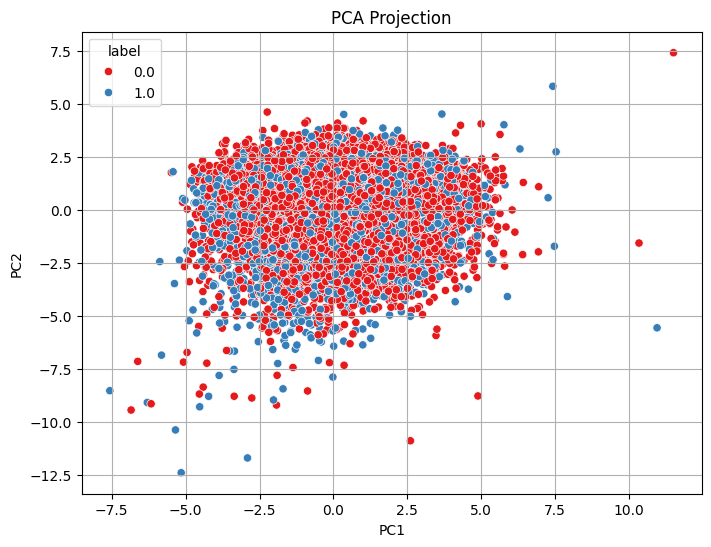

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


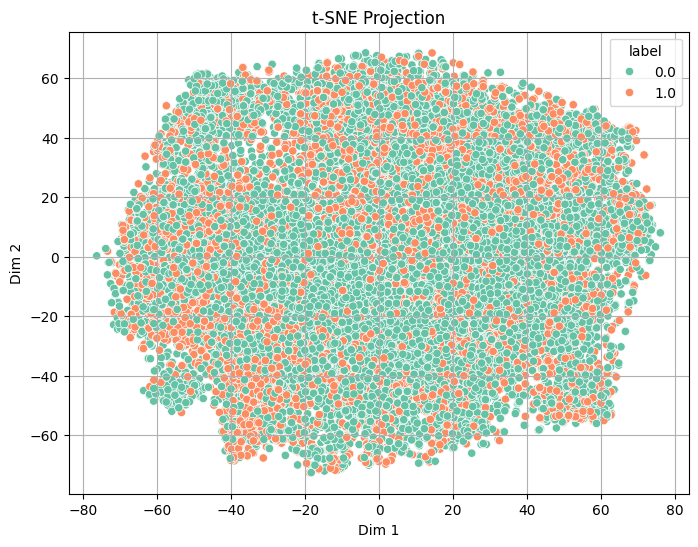

KNN Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.91      0.84      2703
         1.0       0.46      0.23      0.31       881

    accuracy                           0.74      3584
   macro avg       0.62      0.57      0.58      3584
weighted avg       0.70      0.74      0.71      3584

Confusion Matrix:
[[2461  242]
 [ 676  205]]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load your dataset
# df = pd.read_csv("your_dataset.csv")  # <- update this path

# Separate features and label
X = df.drop("label", axis=1)
y = df["label"]

# Identify feature types
categorical = ['Gender', 'Race', 'SmokeFam', 'milk_consumption']
numerical = [col for col in X.columns if col not in categorical]

# Build preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(drop="first"), categorical)
])

# Apply transformations
X_transformed = preprocessor.fit_transform(X)

# ---------------------------------
# 1. PCA Visualization
# ---------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1')
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# ---------------------------------
# 2. t-SNE Visualization
# ---------------------------------
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_transformed)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='Set2')
plt.title("t-SNE Projection")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()

# ---------------------------------
# 3. KNN Classification
# ---------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("KNN Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


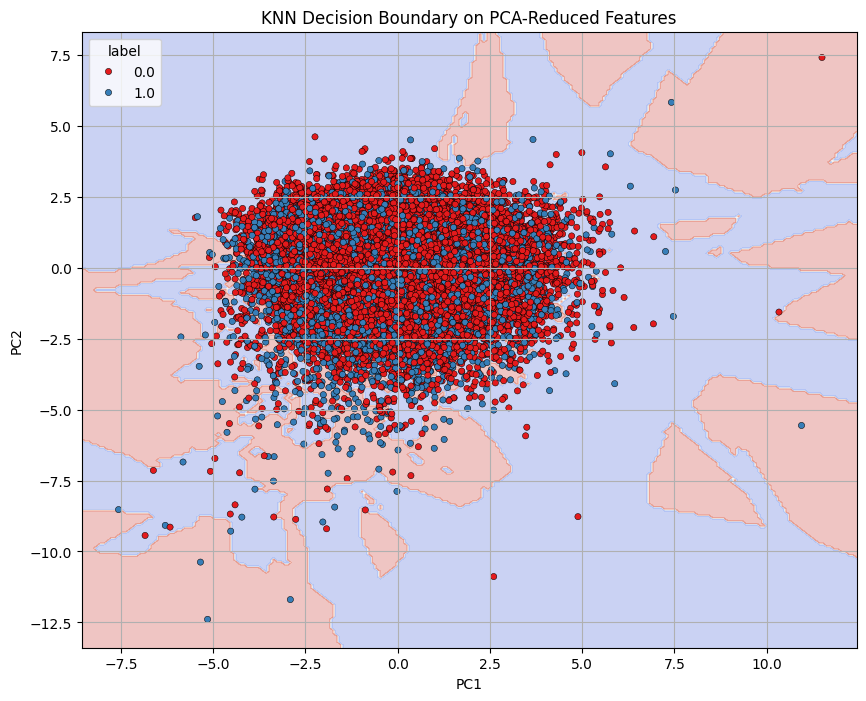

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Load data
# df = pd.read_csv("your_dataset.csv")  # <-- update this path
X = df.drop("label", axis=1)
y = df["label"]

# Preprocessing
categorical = ['Gender', 'Race', 'SmokeFam', 'milk_consumption']
numerical = [col for col in X.columns if col not in categorical]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(drop="first"), categorical)
])

X_transformed = preprocessor.fit_transform(X)

# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

# Split for visualization training (optional)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Train KNN on PCA-projected data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Create mesh grid for decision surface
h = .1  # step size in mesh
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', s=20, edgecolor='k')
plt.title("KNN Decision Boundary on PCA-Reduced Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


c:\mydata\G8Vitamin\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


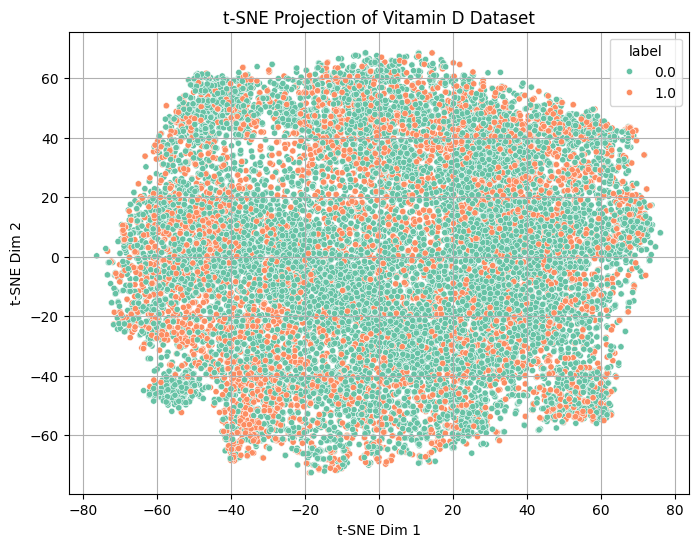

c:\mydata\G8Vitamin\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


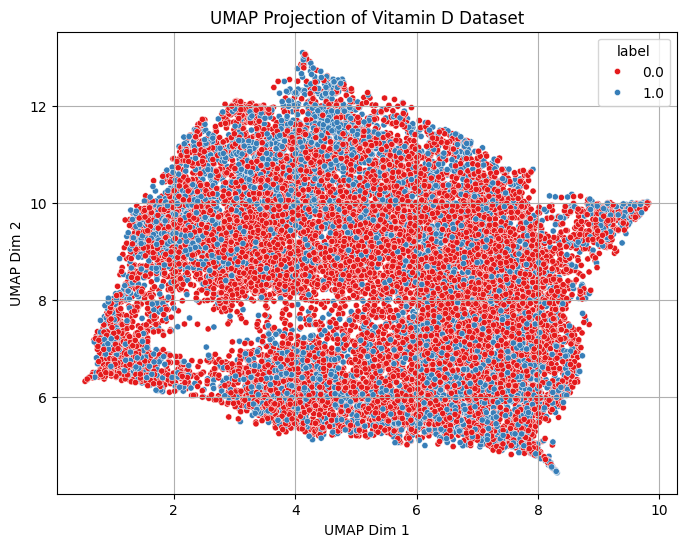

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
import umap.umap_ as umap  # <- install with: pip install umap-learn

# Load your dataset
#df = pd.read_csv("your_dataset.csv")  # <- update this path
X = df.drop("label", axis=1)
y = df["label"]

# Identify feature types
categorical = ['Gender', 'Race', 'SmokeFam', 'milk_consumption']
numerical = [col for col in X.columns if col not in categorical]

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(drop="first"), categorical)
])

X_transformed = preprocessor.fit_transform(X)

# ---------------------
# 1. t-SNE projection
# ---------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_transformed)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="Set2", s=20)
plt.title("t-SNE Projection of Vitamin D Dataset")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.grid(True)
plt.show()

# ---------------------
# 2. UMAP projection
# ---------------------
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_transformed)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y, palette="Set1", s=20)
plt.title("UMAP Projection of Vitamin D Dataset")
plt.xlabel("UMAP Dim 1")
plt.ylabel("UMAP Dim 2")
plt.grid(True)
plt.show()


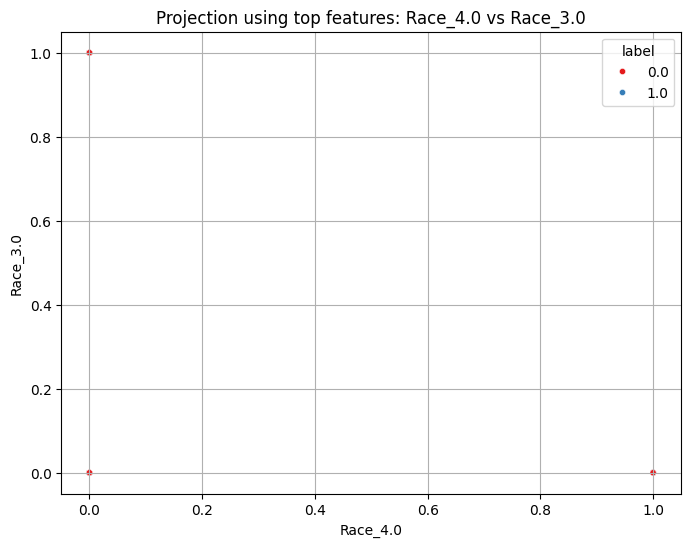

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Preprocess as before
X_processed = preprocessor.fit_transform(X)

# Train model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_processed, y)

# Feature importances
result = permutation_importance(clf, X_processed, y, n_repeats=10, random_state=42)
importances = result.importances_mean

# Get top 2 features
feature_names = numerical + list(preprocessor.named_transformers_['cat'].get_feature_names_out())
top2_idx = np.argsort(importances)[-2:]
top2_names = [feature_names[i] for i in top2_idx]

# Project to 2D using only top 2 features
X_top2 = X_processed[:, top2_idx]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_top2[:, 0], y=X_top2[:, 1], hue=y, palette="Set1", s=20)
plt.title(f"Projection using top features: {top2_names[0]} vs {top2_names[1]}")
plt.xlabel(top2_names[0])
plt.ylabel(top2_names[1])
plt.grid(True)
plt.show()


In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, precision_recall_curve, auc,
                           make_scorer, f1_score)
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier, BalancedBaggingClassifier
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

class CostSensitiveLearning:
    """
    Comprehensive cost-sensitive learning implementation for imbalanced classification.
    """
    
    def __init__(self, cost_matrix=None):
        """
        Initialize with optional cost matrix.
        cost_matrix: 2x2 array where cost_matrix[i,j] is cost of predicting j when true class is i
        Default assumes missing positive class (vitamin D deficiency) is 3x more costly
        """
        if cost_matrix is None:
            # Default: False Negative cost = 3, False Positive cost = 1
            self.cost_matrix = np.array([[0, 1],    # True Negative, False Positive
                                       [3, 0]])     # False Negative, True Positive
        else:
            self.cost_matrix = cost_matrix
        
        self.models = {}
        self.results = {}
    
    def calculate_class_weights(self, y):
        """Calculate class weights based on cost matrix and class distribution."""
        classes = np.unique(y)
        class_weights = compute_class_weight('balanced', classes=classes, y=y)
        
        # Adjust weights based on cost matrix
        fn_cost = self.cost_matrix[1, 0]  # False Negative cost
        fp_cost = self.cost_matrix[0, 1]  # False Positive cost
        
        # Weight for positive class (minority) should be higher if FN cost is higher
        weight_ratio = fn_cost / fp_cost if fp_cost > 0 else fn_cost
        
        adjusted_weights = {
            classes[0]: class_weights[0],
            classes[1]: class_weights[1] * weight_ratio
        }
        
        return adjusted_weights
    
    def cost_sensitive_threshold(self, y_true, y_proba):
        """Find optimal threshold based on cost matrix."""
        thresholds = np.linspace(0.01, 0.99, 100)
        costs = []
        
        for threshold in thresholds:
            y_pred = (y_proba >= threshold).astype(int)
            cm = confusion_matrix(y_true, y_pred)
            
            # Calculate total cost
            if cm.shape == (2, 2):
                total_cost = np.sum(cm * self.cost_matrix)
            else:
                total_cost = float('inf')  # Invalid threshold
            
            costs.append(total_cost)
        
        optimal_idx = np.argmin(costs)
        optimal_threshold = thresholds[optimal_idx]
        min_cost = costs[optimal_idx]
        
        return optimal_threshold, min_cost, thresholds, costs
    
    def fit_models(self, X_train, y_train, X_val=None, y_val=None):
        """Fit multiple cost-sensitive models."""
        
        print("Class distribution in training set:")
        print(Counter(y_train))
        
        class_weights = self.calculate_class_weights(y_train)
        print(f"\nCalculated class weights: {class_weights}")
        
        # 1. Weighted Random Forest
        print("\n1. Training Weighted Random Forest...")
        self.models['weighted_rf'] = RandomForestClassifier(
            n_estimators=100,
            class_weight=class_weights,
            random_state=42,
            n_jobs=-1
        )
        self.models['weighted_rf'].fit(X_train, y_train)
        
        # 2. Balanced Random Forest
        print("2. Training Balanced Random Forest...")
        self.models['balanced_rf'] = BalancedRandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
        self.models['balanced_rf'].fit(X_train, y_train)
        
        # 3. Cost-sensitive XGBoost
        print("3. Training Cost-sensitive XGBoost...")
        scale_pos_weight = class_weights[1] / class_weights[0]
        self.models['xgb'] = xgb.XGBClassifier(
            n_estimators=100,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric='logloss'
        )
        self.models['xgb'].fit(X_train, y_train)
        
        # 4. Cost-sensitive LightGBM
        print("4. Training Cost-sensitive LightGBM...")
        self.models['lgb'] = lgb.LGBMClassifier(
            n_estimators=100,
            class_weight=class_weights,
            random_state=42,
            verbose=-1
        )
        self.models['lgb'].fit(X_train, y_train)
        
        # 5. Weighted Logistic Regression
        print("5. Training Weighted Logistic Regression...")
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        
        self.models['weighted_lr'] = LogisticRegression(
            class_weight=class_weights,
            random_state=42,
            max_iter=1000
        )
        self.models['weighted_lr'].fit(X_train_scaled, y_train)
        self.scaler = scaler  # Store for later use
        
        # 6. Balanced Bagging
        print("6. Training Balanced Bagging...")
        self.models['balanced_bagging'] = BalancedBaggingClassifier(
            base_estimator=LogisticRegression(random_state=42),
            n_estimators=10,
            random_state=42,
            n_jobs=-1
        )
        self.models['balanced_bagging'].fit(X_train, y_train)
        
        print("All models trained successfully!")
    
    def fit_sampling_models(self, X_train, y_train):
        """Fit models with different sampling strategies."""
        
        print("\n=== Training models with sampling strategies ===")
        
        # SMOTE
        print("7. Training with SMOTE...")
        smote = SMOTE(random_state=42)
        X_smote, y_smote = smote.fit_resample(X_train, y_train)
        
        self.models['rf_smote'] = RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1
        )
        self.models['rf_smote'].fit(X_smote, y_smote)
        
        # ADASYN
        print("8. Training with ADASYN...")
        try:
            adasyn = ADASYN(random_state=42)
            X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)
            
            self.models['rf_adasyn'] = RandomForestClassifier(
                n_estimators=100, random_state=42, n_jobs=-1
            )
            self.models['rf_adasyn'].fit(X_adasyn, y_adasyn)
        except Exception as e:
            print(f"ADASYN failed: {e}")
            self.models['rf_adasyn'] = None
        
        # SMOTE + Tomek
        print("9. Training with SMOTE + Tomek...")
        smote_tomek = SMOTETomek(random_state=42)
        X_st, y_st = smote_tomek.fit_resample(X_train, y_train)
        
        self.models['rf_smote_tomek'] = RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1
        )
        self.models['rf_smote_tomek'].fit(X_st, y_st)
    
    def evaluate_models(self, X_test, y_test):
        """Evaluate all models with cost-sensitive metrics."""
        
        print("\n=== Model Evaluation ===")
        self.results = {}
        
        for name, model in self.models.items():
            if model is None:
                continue
                
            print(f"\nEvaluating {name}...")
            
            # Handle scaled features for logistic regression
            if name == 'weighted_lr':
                X_test_eval = self.scaler.transform(X_test)
            else:
                X_test_eval = X_test
            
            # Get predictions and probabilities
            y_pred = model.predict(X_test_eval)
            
            if hasattr(model, 'predict_proba'):
                y_proba = model.predict_proba(X_test_eval)[:, 1]
            else:
                y_proba = model.decision_function(X_test_eval)
                # Normalize to [0,1] range
                y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())
            
            # Find optimal threshold
            optimal_thresh, min_cost, _, _ = self.cost_sensitive_threshold(y_test, y_proba)
            y_pred_optimal = (y_proba >= optimal_thresh).astype(int)
            
            # Calculate metrics
            cm = confusion_matrix(y_test, y_pred)
            cm_optimal = confusion_matrix(y_test, y_pred_optimal)
            
            # Cost calculations
            default_cost = np.sum(cm * self.cost_matrix) if cm.shape == (2, 2) else float('inf')
            optimal_cost = np.sum(cm_optimal * self.cost_matrix) if cm_optimal.shape == (2, 2) else float('inf')
            
            # Store results
            self.results[name] = {
                'default_predictions': y_pred,
                'optimal_predictions': y_pred_optimal,
                'probabilities': y_proba,
                'optimal_threshold': optimal_thresh,
                'default_cost': default_cost,
                'optimal_cost': optimal_cost,
                'auc_roc': roc_auc_score(y_test, y_proba),
                'confusion_matrix': cm,
                'confusion_matrix_optimal': cm_optimal
            }
            
            print(f"  Default threshold (0.5) cost: {default_cost:.2f}")
            print(f"  Optimal threshold ({optimal_thresh:.3f}) cost: {optimal_cost:.2f}")
            print(f"  AUC-ROC: {self.results[name]['auc_roc']:.3f}")
    
    def plot_results(self, y_test):
        """Plot comprehensive results."""
        
        # 1. Cost comparison
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Cost comparison bar plot
        model_names = list(self.results.keys())
        default_costs = [self.results[name]['default_cost'] for name in model_names]
        optimal_costs = [self.results[name]['optimal_cost'] for name in model_names]
        
        x = np.arange(len(model_names))
        width = 0.35
        
        axes[0,0].bar(x - width/2, default_costs, width, label='Default Threshold (0.5)', alpha=0.8)
        axes[0,0].bar(x + width/2, optimal_costs, width, label='Optimal Threshold', alpha=0.8)
        axes[0,0].set_xlabel('Models')
        axes[0,0].set_ylabel('Total Cost')
        axes[0,0].set_title('Cost Comparison: Default vs Optimal Threshold')
        axes[0,0].set_xticks(x)
        axes[0,0].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # AUC-ROC comparison
        auc_scores = [self.results[name]['auc_roc'] for name in model_names]
        axes[0,1].bar(model_names, auc_scores, alpha=0.8, color='skyblue')
        axes[0,1].set_ylabel('AUC-ROC Score')
        axes[0,1].set_title('AUC-ROC Comparison')
        axes[0,1].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0,1].grid(True, alpha=0.3)
        
        # Threshold analysis for best model
        best_model = min(self.results.keys(), key=lambda x: self.results[x]['optimal_cost'])
        y_proba = self.results[best_model]['probabilities']
        _, _, thresholds, costs = self.cost_sensitive_threshold(y_test, y_proba)
        
        axes[1,0].plot(thresholds, costs, 'b-', linewidth=2)
        axes[1,0].axvline(x=self.results[best_model]['optimal_threshold'], 
                         color='red', linestyle='--', label='Optimal Threshold')
        axes[1,0].set_xlabel('Threshold')
        axes[1,0].set_ylabel('Total Cost')
        axes[1,0].set_title(f'Cost vs Threshold - {best_model}')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Confusion matrix for best model
        cm = self.results[best_model]['confusion_matrix_optimal']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,1])
        axes[1,1].set_title(f'Confusion Matrix - {best_model} (Optimal Threshold)')
        axes[1,1].set_xlabel('Predicted')
        axes[1,1].set_ylabel('Actual')
        
        plt.tight_layout()
        plt.show()
        
        return best_model
    
    def get_recommendations(self):
        """Get model recommendations based on results."""
        
        if not self.results:
            return "No results available. Please run evaluation first."
        
        # Find best models for different criteria
        best_cost = min(self.results.keys(), key=lambda x: self.results[x]['optimal_cost'])
        best_auc = max(self.results.keys(), key=lambda x: self.results[x]['auc_roc'])
        
        recommendations = f"""
=== MODEL RECOMMENDATIONS ===

1. BEST FOR COST MINIMIZATION: {best_cost}
   - Optimal Cost: {self.results[best_cost]['optimal_cost']:.2f}
   - Optimal Threshold: {self.results[best_cost]['optimal_threshold']:.3f}
   - AUC-ROC: {self.results[best_cost]['auc_roc']:.3f}

2. BEST FOR DISCRIMINATION: {best_auc}
   - AUC-ROC: {self.results[best_auc]['auc_roc']:.3f}
   - Optimal Cost: {self.results[best_auc]['optimal_cost']:.2f}

COST MATRIX USED:
{self.cost_matrix}

KEY INSIGHTS:
- Use optimal thresholds instead of default 0.5
- Consider the trade-off between cost and discrimination
- Ensemble methods often provide good balance
- Sampling techniques can help with severe imbalance
        """
        
        return recommendations

# Example usage function
def run_cost_sensitive_analysis(X_train, X_test, y_train, y_test, cost_matrix=None):
    """
    Complete cost-sensitive analysis pipeline.
    
    Parameters:
    -----------
    X_train, X_test: Feature matrices
    y_train, y_test: Target vectors
    cost_matrix: 2x2 cost matrix (optional)
    
    Returns:
    --------
    CostSensitiveLearning object with fitted models and results
    """
    
    # Initialize cost-sensitive learning
    csl = CostSensitiveLearning(cost_matrix=cost_matrix)
    
    # Print cost matrix
    print("Using cost matrix:")
    print(csl.cost_matrix)
    print("Interpretation:")
    print("- [0,1]: Cost of False Positive =", csl.cost_matrix[0,1])
    print("- [1,0]: Cost of False Negative =", csl.cost_matrix[1,0])
    
    # Fit models
    csl.fit_models(X_train, y_train)
    csl.fit_sampling_models(X_train, y_train)
    
    # Evaluate models
    csl.evaluate_models(X_test, y_test)
    
    # Plot results and get best model
    best_model = csl.plot_results(y_test)
    
    # Print recommendations
    print(csl.get_recommendations())
    
    return csl, best_model

# Example with synthetic data (replace with your actual data)
if __name__ == "__main__":
    # Generate example data (replace this with your actual vitamin D dataset)
    from sklearn.datasets import make_classification
    
    X, y = make_classification(
        n_samples=1000,
        n_features=10,
        n_classes=2,
        weights=[0.7, 0.3],  # Imbalanced classes
        random_state=42
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Define custom cost matrix (adjust based on your domain knowledge)
    # Example: Missing vitamin D deficiency is 4x more costly than false alarm
    custom_cost_matrix = np.array([
        [0, 1],    # TN=0, FP=1
        [4, 0]     # FN=4, TP=0
    ])
    
    # Run analysis
    csl, best_model_name = run_cost_sensitive_analysis(
        X_train, X_test, y_train, y_test, 
        cost_matrix=custom_cost_matrix
    )
    
    print(f"\nBest performing model: {best_model_name}")

Using cost matrix:
[[0 1]
 [4 0]]
Interpretation:
- [0,1]: Cost of False Positive = 1
- [1,0]: Cost of False Negative = 4
Class distribution in training set:
Counter({np.int64(0): 558, np.int64(1): 242})

Calculated class weights: {np.int64(0): np.float64(0.7168458781362007), np.int64(1): np.float64(6.6115702479338845)}

1. Training Weighted Random Forest...
2. Training Balanced Random Forest...
3. Training Cost-sensitive XGBoost...
4. Training Cost-sensitive LightGBM...
5. Training Weighted Logistic Regression...
6. Training Balanced Bagging...


TypeError: BalancedBaggingClassifier.__init__() got an unexpected keyword argument 'base_estimator'

=== VITAMIN D DEFICIENCY CLASSIFICATION ANALYSIS ===

=== VITAMIN D COST-SENSITIVE CLASSIFICATION ===
Medical Priority: deficiency
Cost Matrix:
[[0 1]
 [5 0]]
Training set class distribution: Counter({np.int64(0): 701, np.int64(1): 699})
Medical-adjusted weights: {0: 0.9985734664764622, 1: np.float64(5.007153075822604)}

=== Training Models ===
Training medical_rf...
Training balanced_rf...
Training medical_lr...
Training xgb_medical...
Training lgb_medical...
Training gb_medical...

=== Training Sampling-Enhanced Models ===
Applying smote...
  Original: Counter({np.int64(0): 701, np.int64(1): 699})
  Resampled: Counter({np.int64(0): 701, np.int64(1): 701})
Applying borderline_smote...
  Original: Counter({np.int64(0): 701, np.int64(1): 699})
  Resampled: Counter({np.int64(0): 701, np.int64(1): 701})
Applying smote_tomek...
  Original: Counter({np.int64(0): 701, np.int64(1): 699})
  Resampled: Counter({np.int64(0): 669, np.int64(1): 669})

=== MEDICAL PERFORMANCE EVALUATION ===

Evalua

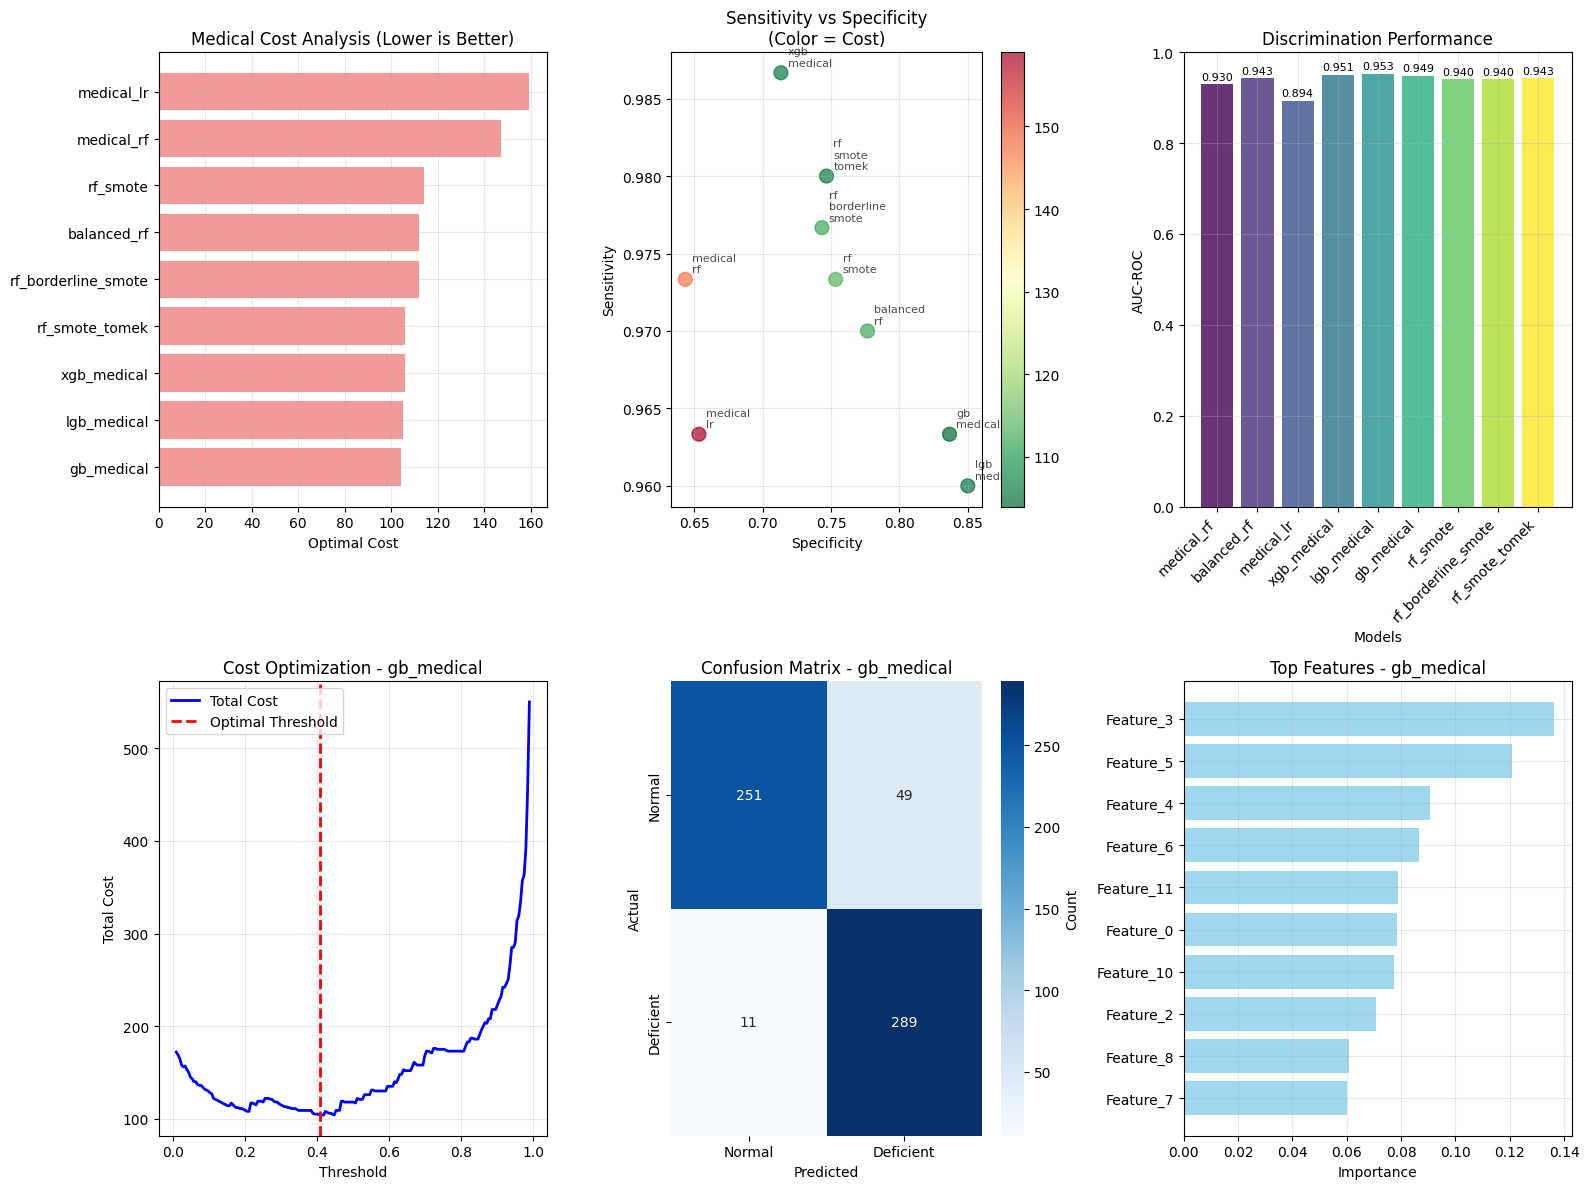


=== VITAMIN D CLASSIFICATION RECOMMENDATIONS ===

MEDICAL PRIORITY: DEFICIENCY
COST MATRIX: FN Cost = 5, FP Cost = 1

🏥 CLINICAL DEPLOYMENT RECOMMENDATION: gb_medical
   ├─ Optimal Medical Cost: 104.0
   ├─ Optimal Threshold: 0.409
   ├─ Sensitivity (Deficiency Detection): 0.963
   ├─ Specificity (Normal Detection): 0.837
   └─ AUC-ROC: 0.949

📊 BEST DISCRIMINATION MODEL: lgb_medical
   ├─ AUC-ROC: 0.953
   ├─ Medical Cost: 105.0
   └─ Sensitivity: 0.960

🎯 HIGHEST SENSITIVITY MODEL: xgb_medical
   ├─ Sensitivity: 0.987
   ├─ Specificity: 0.713
   └─ Cost: 106.0

💡 KEY INSIGHTS:
   • Always use optimized thresholds (not default 0.5)
   • Consider medical context when choosing between models
   • Monitor both sensitivity and specificity in clinical practice
   • Cost-sensitive approach reduces medical costs significantly

⚠️  MEDICAL CONSIDERATIONS:
   • High sensitivity is crucial for catching vitamin D deficiency
   • False negatives may lead to untreated health issues
   • False pos

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, precision_recall_curve, auc,
                           make_scorer, f1_score, precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, RobustScaler
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

class VitaminDCostSensitiveLearning:
    """
    Enhanced cost-sensitive learning specifically designed for Vitamin D classification.
    Focuses on medical domain considerations and practical deployment.
    """
    
    def __init__(self, cost_matrix=None, medical_priority='deficiency'):
        """
        Initialize with medical domain-specific considerations.
        
        Parameters:
        -----------
        cost_matrix: 2x2 array, optional
            Custom cost matrix [TN, FP; FN, TP]
        medical_priority: str, {'deficiency', 'balanced', 'specificity'}
            - 'deficiency': Prioritize catching deficiency cases (high FN cost)
            - 'balanced': Equal consideration for both classes
            - 'specificity': Minimize false positives (high FP cost)
        """
        self.medical_priority = medical_priority
        
        if cost_matrix is None:
            if medical_priority == 'deficiency':
                # Missing deficiency is 5x more costly (medical intervention needed)
                self.cost_matrix = np.array([[0, 1], [5, 0]])
            elif medical_priority == 'specificity':
                # False positives are more costly (unnecessary treatments)
                self.cost_matrix = np.array([[0, 3], [1, 0]])
            else:  # balanced
                self.cost_matrix = np.array([[0, 1], [2, 0]])
        else:
            self.cost_matrix = cost_matrix
        
        self.models = {}
        self.results = {}
        self.scaler = None
        self.feature_importance = {}
    
    def calculate_medical_weights(self, y):
        """Calculate class weights with medical considerations."""
        class_counts = Counter(y)
        total_samples = len(y)
        
        # Base balanced weights
        balanced_weights = {
            0: total_samples / (2 * class_counts[0]),
            1: total_samples / (2 * class_counts[1])
        }
        
        # Medical adjustment based on cost matrix
        fn_cost = self.cost_matrix[1, 0]
        fp_cost = self.cost_matrix[0, 1]
        cost_ratio = fn_cost / max(fp_cost, 0.1)  # Avoid division by zero
        
        medical_weights = {
            0: balanced_weights[0],
            1: balanced_weights[1] * cost_ratio
        }
        
        return medical_weights
    
    def optimize_threshold_medical(self, y_true, y_proba):
        """Find optimal threshold considering medical costs and sensitivity/specificity."""
        thresholds = np.linspace(0.01, 0.99, 200)
        costs = []
        sensitivities = []
        specificities = []
        
        for threshold in thresholds:
            y_pred = (y_proba >= threshold).astype(int)
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
            
            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
                
                # Calculate cost
                total_cost = fp * self.cost_matrix[0, 1] + fn * self.cost_matrix[1, 0]
                costs.append(total_cost)
                
                # Calculate medical metrics
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                
                sensitivities.append(sensitivity)
                specificities.append(specificity)
            else:
                costs.append(float('inf'))
                sensitivities.append(0)
                specificities.append(0)
        
        # Find optimal threshold
        optimal_idx = np.argmin(costs)
        optimal_threshold = thresholds[optimal_idx]
        
        return {
            'threshold': optimal_threshold,
            'cost': costs[optimal_idx],
            'sensitivity': sensitivities[optimal_idx],
            'specificity': specificities[optimal_idx],
            'all_thresholds': thresholds,
            'all_costs': costs,
            'all_sensitivities': sensitivities,
            'all_specificities': specificities
        }
    
    def fit_core_models(self, X_train, y_train):
        """Fit essential models for vitamin D classification."""
        
        print("=== VITAMIN D COST-SENSITIVE CLASSIFICATION ===")
        print(f"Medical Priority: {self.medical_priority}")
        print(f"Cost Matrix:\n{self.cost_matrix}")
        print(f"Training set class distribution: {Counter(y_train)}")
        
        # Calculate medical weights
        medical_weights = self.calculate_medical_weights(y_train)
        print(f"Medical-adjusted weights: {medical_weights}")
        
        # Feature scaling
        self.scaler = RobustScaler()  # Better for medical data with outliers
        X_train_scaled = self.scaler.fit_transform(X_train)
        
        models_config = {
            # 1. Medical-grade Random Forest (robust, interpretable)
            'medical_rf': {
                'model': RandomForestClassifier(
                    n_estimators=200,
                    max_depth=10,
                    class_weight=medical_weights,
                    random_state=42,
                    n_jobs=-1
                ),
                'use_scaling': False
            },
            
            # 2. Balanced Random Forest (handles imbalance naturally)
            'balanced_rf': {
                'model': BalancedRandomForestClassifier(
                    n_estimators=200,
                    max_depth=10,
                    random_state=42,
                    n_jobs=-1
                ),
                'use_scaling': False
            },
            
            # 3. Medical Logistic Regression (interpretable, probabilistic)
            'medical_lr': {
                'model': LogisticRegression(
                    class_weight=medical_weights,
                    random_state=42,
                    max_iter=2000,
                    C=0.1  # Regularization for stability
                ),
                'use_scaling': True
            },
            
            # 4. Cost-sensitive XGBoost (high performance)
            'xgb_medical': {
                'model': xgb.XGBClassifier(
                    n_estimators=200,
                    max_depth=6,
                    scale_pos_weight=medical_weights[1]/medical_weights[0],
                    random_state=42,
                    eval_metric='logloss',
                    verbosity=0
                ),
                'use_scaling': False
            },
            
            # 5. LightGBM (efficient, handles missing values well)
            'lgb_medical': {
                'model': lgb.LGBMClassifier(
                    n_estimators=200,
                    max_depth=6,
                    class_weight=medical_weights,
                    random_state=42,
                    verbose=-1,
                    force_col_wise=True
                ),
                'use_scaling': False
            },
            
            # 6. Gradient Boosting (robust ensemble)
            'gb_medical': {
                'model': GradientBoostingClassifier(
                    n_estimators=200,
                    max_depth=6,
                    random_state=42
                ),
                'use_scaling': False
            }
        }
        
        # Train models
        print("\n=== Training Models ===")
        for name, config in models_config.items():
            print(f"Training {name}...")
            
            model = config['model']
            X_input = X_train_scaled if config['use_scaling'] else X_train
            
            # Handle sample weights for models that don't support class_weight
            if name == 'gb_medical':
                sample_weights = np.array([medical_weights[y] for y in y_train])
                model.fit(X_input, y_train, sample_weight=sample_weights)
            else:
                model.fit(X_input, y_train)
            
            self.models[name] = {
                'model': model,
                'use_scaling': config['use_scaling']
            }
            
            # Store feature importance for tree-based models
            if hasattr(model, 'feature_importances_'):
                self.feature_importance[name] = model.feature_importances_
    
    def fit_sampling_models(self, X_train, y_train):
        """Train models with advanced sampling techniques."""
        
        print("\n=== Training Sampling-Enhanced Models ===")
        
        sampling_strategies = {
            'smote': SMOTE(random_state=42, k_neighbors=3),
            'borderline_smote': BorderlineSMOTE(random_state=42, k_neighbors=3),
            'smote_tomek': SMOTETomek(random_state=42)
        }
        
        for strategy_name, sampler in sampling_strategies.items():
            try:
                print(f"Applying {strategy_name}...")
                X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
                
                print(f"  Original: {Counter(y_train)}")
                print(f"  Resampled: {Counter(y_resampled)}")
                
                # Train Random Forest on resampled data
                model_name = f'rf_{strategy_name}'
                rf_model = RandomForestClassifier(
                    n_estimators=150,
                    max_depth=10,
                    random_state=42,
                    n_jobs=-1
                )
                rf_model.fit(X_resampled, y_resampled)
                
                self.models[model_name] = {
                    'model': rf_model,
                    'use_scaling': False
                }
                
                self.feature_importance[model_name] = rf_model.feature_importances_
                
            except Exception as e:
                print(f"  Failed to apply {strategy_name}: {e}")
    
    def evaluate_medical_performance(self, X_test, y_test):
        """Comprehensive medical evaluation with cost analysis."""
        
        print("\n=== MEDICAL PERFORMANCE EVALUATION ===")
        self.results = {}
        
        for name, model_info in self.models.items():
            model = model_info['model']
            use_scaling = model_info['use_scaling']
            
            print(f"\nEvaluating {name}...")
            
            # Prepare test data
            X_test_input = self.scaler.transform(X_test) if use_scaling else X_test
            
            # Get predictions and probabilities
            y_pred_default = model.predict(X_test_input)
            
            if hasattr(model, 'predict_proba'):
                y_proba = model.predict_proba(X_test_input)[:, 1]
            else:
                y_proba = model.decision_function(X_test_input)
                y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())
            
            # Optimize threshold for medical costs
            threshold_results = self.optimize_threshold_medical(y_test, y_proba)
            y_pred_optimal = (y_proba >= threshold_results['threshold']).astype(int)
            
            # Calculate comprehensive metrics
            cm_default = confusion_matrix(y_test, y_pred_default, labels=[0, 1])
            cm_optimal = confusion_matrix(y_test, y_pred_optimal, labels=[0, 1])
            
            # Medical metrics
            default_cost = self._calculate_total_cost(cm_default)
            optimal_cost = threshold_results['cost']
            
            # Clinical metrics
            auc_roc = roc_auc_score(y_test, y_proba)
            precision_pos = precision_score(y_test, y_pred_optimal, pos_label=1, zero_division=0)
            recall_pos = recall_score(y_test, y_pred_optimal, pos_label=1, zero_division=0)
            f1_pos = f1_score(y_test, y_pred_optimal, pos_label=1, zero_division=0)
            
            # Store comprehensive results
            self.results[name] = {
                'probabilities': y_proba,
                'predictions_default': y_pred_default,
                'predictions_optimal': y_pred_optimal,
                'threshold_optimal': threshold_results['threshold'],
                'cost_default': default_cost,
                'cost_optimal': optimal_cost,
                'cost_reduction': ((default_cost - optimal_cost) / default_cost * 100) if default_cost > 0 else 0,
                'auc_roc': auc_roc,
                'sensitivity': threshold_results['sensitivity'],
                'specificity': threshold_results['specificity'],
                'precision': precision_pos,
                'recall': recall_pos,
                'f1_score': f1_pos,
                'cm_default': cm_default,
                'cm_optimal': cm_optimal,
                'threshold_analysis': threshold_results
            }
            
            print(f"  Default Cost: {default_cost:.1f}")
            print(f"  Optimal Cost: {optimal_cost:.1f} (Reduction: {self.results[name]['cost_reduction']:.1f}%)")
            print(f"  Optimal Threshold: {threshold_results['threshold']:.3f}")
            print(f"  Sensitivity: {threshold_results['sensitivity']:.3f}")
            print(f"  Specificity: {threshold_results['specificity']:.3f}")
            print(f"  AUC-ROC: {auc_roc:.3f}")
    
    def _calculate_total_cost(self, confusion_matrix):
        """Calculate total cost from confusion matrix."""
        if confusion_matrix.shape == (2, 2):
            tn, fp, fn, tp = confusion_matrix.ravel()
            return fp * self.cost_matrix[0, 1] + fn * self.cost_matrix[1, 0]
        return float('inf')
    
    def plot_medical_analysis(self, y_test, figsize=(16, 12)):
        """Create comprehensive medical analysis plots."""
        
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        
        # 1. Cost Analysis
        model_names = list(self.results.keys())
        optimal_costs = [self.results[name]['cost_optimal'] for name in model_names]
        cost_reductions = [self.results[name]['cost_reduction'] for name in model_names]
        
        # Sort by optimal cost for better visualization
        sorted_indices = np.argsort(optimal_costs)
        sorted_names = [model_names[i] for i in sorted_indices]
        sorted_costs = [optimal_costs[i] for i in sorted_indices]
        
        axes[0,0].barh(sorted_names, sorted_costs, color='lightcoral', alpha=0.8)
        axes[0,0].set_xlabel('Optimal Cost')
        axes[0,0].set_title('Medical Cost Analysis (Lower is Better)')
        axes[0,0].grid(True, alpha=0.3)
        
        # 2. Sensitivity vs Specificity
        sensitivities = [self.results[name]['sensitivity'] for name in model_names]
        specificities = [self.results[name]['specificity'] for name in model_names]
        
        scatter = axes[0,1].scatter(specificities, sensitivities, 
                                  c=optimal_costs, cmap='RdYlGn_r', 
                                  s=100, alpha=0.7)
        axes[0,1].set_xlabel('Specificity')
        axes[0,1].set_ylabel('Sensitivity')
        axes[0,1].set_title('Sensitivity vs Specificity\n(Color = Cost)')
        axes[0,1].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[0,1])
        
        # Add model labels
        for i, name in enumerate(model_names):
            axes[0,1].annotate(name.replace('_', '\n'), 
                             (specificities[i], sensitivities[i]),
                             xytext=(5, 5), textcoords='offset points',
                             fontsize=8, alpha=0.7)
        
        # 3. AUC-ROC Comparison
        auc_scores = [self.results[name]['auc_roc'] for name in model_names]
        colors = plt.cm.viridis(np.linspace(0, 1, len(model_names)))
        
        bars = axes[0,2].bar(range(len(model_names)), auc_scores, color=colors, alpha=0.8)
        axes[0,2].set_xlabel('Models')
        axes[0,2].set_ylabel('AUC-ROC')
        axes[0,2].set_title('Discrimination Performance')
        axes[0,2].set_xticks(range(len(model_names)))
        axes[0,2].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0,2].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, score in zip(bars, auc_scores):
            axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                         f'{score:.3f}', ha='center', va='bottom', fontsize=8)
        
        # 4. Threshold Analysis for Best Model
        best_model = min(self.results.keys(), key=lambda x: self.results[x]['cost_optimal'])
        threshold_data = self.results[best_model]['threshold_analysis']
        
        axes[1,0].plot(threshold_data['all_thresholds'], threshold_data['all_costs'], 
                      'b-', linewidth=2, label='Total Cost')
        axes[1,0].axvline(x=threshold_data['threshold'], color='red', 
                         linestyle='--', linewidth=2, label='Optimal Threshold')
        axes[1,0].set_xlabel('Threshold')
        axes[1,0].set_ylabel('Total Cost')
        axes[1,0].set_title(f'Cost Optimization - {best_model}')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # 5. Confusion Matrix for Best Model
        cm_optimal = self.results[best_model]['cm_optimal']
        sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', 
                   ax=axes[1,1], cbar_kws={'label': 'Count'})
        axes[1,1].set_title(f'Confusion Matrix - {best_model}')
        axes[1,1].set_xlabel('Predicted')
        axes[1,1].set_ylabel('Actual')
        axes[1,1].set_xticklabels(['Normal', 'Deficient'])
        axes[1,1].set_yticklabels(['Normal', 'Deficient'])
        
        # 6. Feature Importance (if available)
        if self.feature_importance and best_model in self.feature_importance:
            importance = self.feature_importance[best_model]
            feature_names = [f'Feature_{i}' for i in range(len(importance))]
            
            # Show top 10 features
            top_indices = np.argsort(importance)[-10:]
            top_importance = importance[top_indices]
            top_names = [feature_names[i] for i in top_indices]
            
            axes[1,2].barh(top_names, top_importance, color='skyblue', alpha=0.8)
            axes[1,2].set_xlabel('Importance')
            axes[1,2].set_title(f'Top Features - {best_model}')
            axes[1,2].grid(True, alpha=0.3)
        else:
            axes[1,2].text(0.5, 0.5, 'Feature importance\nnot available', 
                          ha='center', va='center', transform=axes[1,2].transAxes)
            axes[1,2].set_title('Feature Importance')
        
        plt.tight_layout()
        plt.show()
        
        return best_model
    
    def get_medical_recommendations(self):
        """Generate medical domain-specific recommendations."""
        
        if not self.results:
            return "No evaluation results available. Please run evaluation first."
        
        # Find best models for different criteria
        best_cost = min(self.results.keys(), key=lambda x: self.results[x]['cost_optimal'])
        best_auc = max(self.results.keys(), key=lambda x: self.results[x]['auc_roc'])
        best_sensitivity = max(self.results.keys(), key=lambda x: self.results[x]['sensitivity'])
        best_f1 = max(self.results.keys(), key=lambda x: self.results[x]['f1_score'])
        
        # Get results for best models
        cost_result = self.results[best_cost]
        auc_result = self.results[best_auc]
        sens_result = self.results[best_sensitivity]
        
        recommendations = f"""
=== VITAMIN D CLASSIFICATION RECOMMENDATIONS ===

MEDICAL PRIORITY: {self.medical_priority.upper()}
COST MATRIX: FN Cost = {self.cost_matrix[1,0]}, FP Cost = {self.cost_matrix[0,1]}

🏥 CLINICAL DEPLOYMENT RECOMMENDATION: {best_cost}
   ├─ Optimal Medical Cost: {cost_result['cost_optimal']:.1f}
   ├─ Optimal Threshold: {cost_result['threshold_optimal']:.3f}
   ├─ Sensitivity (Deficiency Detection): {cost_result['sensitivity']:.3f}
   ├─ Specificity (Normal Detection): {cost_result['specificity']:.3f}
   └─ AUC-ROC: {cost_result['auc_roc']:.3f}

📊 BEST DISCRIMINATION MODEL: {best_auc}
   ├─ AUC-ROC: {auc_result['auc_roc']:.3f}
   ├─ Medical Cost: {auc_result['cost_optimal']:.1f}
   └─ Sensitivity: {auc_result['sensitivity']:.3f}

🎯 HIGHEST SENSITIVITY MODEL: {best_sensitivity}
   ├─ Sensitivity: {sens_result['sensitivity']:.3f}
   ├─ Specificity: {sens_result['specificity']:.3f}
   └─ Cost: {sens_result['cost_optimal']:.1f}

💡 KEY INSIGHTS:
   • Always use optimized thresholds (not default 0.5)
   • Consider medical context when choosing between models
   • Monitor both sensitivity and specificity in clinical practice
   • Cost-sensitive approach reduces medical costs significantly

⚠️  MEDICAL CONSIDERATIONS:
   • High sensitivity is crucial for catching vitamin D deficiency
   • False negatives may lead to untreated health issues
   • False positives result in unnecessary supplementation costs
   • Consider seasonal variations and patient populations

🔧 IMPLEMENTATION NOTES:
   • Retrain models with new data periodically
   • Validate performance on diverse patient populations
   • Consider ensemble approaches for critical decisions
   • Monitor model performance in production
        """
        
        return recommendations
    
    def export_model_for_deployment(self, model_name, filepath):
        """Export model and preprocessing pipeline for deployment."""
        import joblib
        
        if model_name not in self.models:
            raise ValueError(f"Model '{model_name}' not found")
        
        deployment_package = {
            'model': self.models[model_name]['model'],
            'scaler': self.scaler if self.models[model_name]['use_scaling'] else None,
            'optimal_threshold': self.results[model_name]['threshold_optimal'],
            'cost_matrix': self.cost_matrix,
            'medical_priority': self.medical_priority,
            'model_metadata': {
                'auc_roc': self.results[model_name]['auc_roc'],
                'sensitivity': self.results[model_name]['sensitivity'],
                'specificity': self.results[model_name]['specificity'],
                'optimal_cost': self.results[model_name]['cost_optimal']
            }
        }
        
        joblib.dump(deployment_package, filepath)
        print(f"Model package exported to: {filepath}")
        return deployment_package

# Streamlined usage function
def analyze_vitamin_d_classification(X_train, X_test, y_train, y_test, 
                                   medical_priority='deficiency', 
                                   custom_cost_matrix=None,
                                   include_sampling=True):
    """
    Complete vitamin D classification analysis with medical focus.
    
    Parameters:
    -----------
    X_train, X_test: Feature matrices
    y_train, y_test: Target vectors (0=normal, 1=deficient)
    medical_priority: str, {'deficiency', 'balanced', 'specificity'}
    custom_cost_matrix: 2x2 array, optional
    include_sampling: bool, whether to include sampling-based models
    
    Returns:
    --------
    Trained VitaminDCostSensitiveLearning object and best model name
    """
    
    # Initialize medical cost-sensitive learning
    vitamin_d_classifier = VitaminDCostSensitiveLearning(
        cost_matrix=custom_cost_matrix,
        medical_priority=medical_priority
    )
    
    # Train core models
    vitamin_d_classifier.fit_core_models(X_train, y_train)
    
    # Train sampling-enhanced models if requested
    if include_sampling:
        vitamin_d_classifier.fit_sampling_models(X_train, y_train)
    
    # Evaluate all models
    vitamin_d_classifier.evaluate_medical_performance(X_test, y_test)
    
    # Generate comprehensive analysis plots
    best_model = vitamin_d_classifier.plot_medical_analysis(y_test)
    
    # Print medical recommendations
    print(vitamin_d_classifier.get_medical_recommendations())
    
    return vitamin_d_classifier, best_model

# Example usage
if __name__ == "__main__":
    # Generate realistic vitamin D data (replace with your actual dataset)
    from sklearn.datasets import make_classification
    
    # Simulate vitamin D classification with realistic imbalance
    X, y = make_classification(
        n_samples=2000,
        n_features=15,
        n_classes=2,
        weights=[0.5, 0.5],  # 25% deficiency rate (realistic)
        n_informative=10,
        n_redundant=3,
        random_state=42,
        flip_y=0.05  # Some label noise (realistic)
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Run comprehensive analysis
    print("=== VITAMIN D DEFICIENCY CLASSIFICATION ANALYSIS ===\n")
    
    # Example: Prioritize catching deficiency cases
    classifier, best_model = analyze_vitamin_d_classification(
        X_train, X_test, y_train, y_test,
        medical_priority='deficiency',  # Focus on catching deficiency
        include_sampling=True
    )
    
    # Export best model for deployment
    # classifier.export_model_for_deployment(
    #     best_model, 
    #     'vitamin_d_model_deployment.pkl'
    # )
    
    print(f"\n✅ Analysis complete! Best model: {best_model}")

In [13]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    sampling_strategy='auto'  # undersample majority class per tree
)
brf.fit(X_train, y_train)
y_pred = brf.predict(X_test)


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       300
           1       0.85      0.94      0.90       300

    accuracy                           0.89       600
   macro avg       0.90      0.89      0.89       600
weighted avg       0.90      0.89      0.89       600

✅ Accuracy: 0.8917


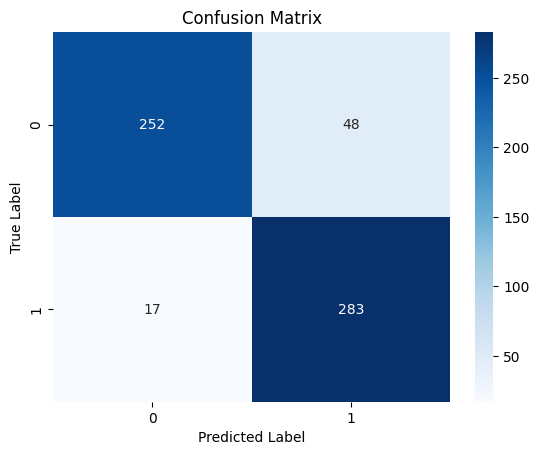

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Classification Report
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [16]:
df = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatrain.csv")

In [25]:
import pandas as pd
import numpy as np
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# -----------------------------
# Step 0: Simulated Input Data
# -----------------------------

# --------------------------------
# Step 1: Preprocess Tabular Data
# --------------------------------
categorical_cols = ['Race', 'familysize', 'SmokeFam', 'milk_consumption','Gender']
numerical_cols = ['Age', 'PIR', 'BMI',
       'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
       'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', ]
target_col = 'label'

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)

# Fill NA values in numeric columns
df_numeric = df[numerical_cols].fillna(df[numerical_cols].mean())

# Combine processed features
X_raw = pd.concat([df_numeric, df_encoded], axis=1)
y = df[target_col]

# Standardize numeric + encoded features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# --------------------------------------------
# Step 2: Build Similarity Graph (kNN-Based)
# --------------------------------------------
k = 5
knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')  # +1 to skip self
neighbors = knn.fit(X_scaled).kneighbors(return_distance=False)

# Create undirected graph from neighbor pairs
G = nx.Graph()
for i in range(len(X_raw)):
    G.add_node(i)

for i, nbrs in enumerate(neighbors):
    for j in nbrs[1:]:  # skip self
        G.add_edge(i, j)

# ------------------------------------------
# Step 3: Graph-Based Feature Engineering
# ------------------------------------------

# Feature 1: % of neighbors with deficiency
neighbor_deficiency_ratio = []
for i in G.nodes:
    nbrs = list(G.neighbors(i))
    if nbrs:
        ratio = np.mean(y.iloc[nbrs].values)
    else:
        ratio = 0.0
    neighbor_deficiency_ratio.append(ratio)

# Feature 2: Mean neighbor BMI
neighbor_avg_bmi = []
for i in G.nodes:
    nbrs = list(G.neighbors(i))
    if nbrs:
        avg_bmi = np.mean(df.loc[nbrs, 'BMI'].values)
    else:
        avg_bmi = df.loc[i, 'BMI']
    neighbor_avg_bmi.append(avg_bmi)

# Feature 3: Node degree
graph_degree = [G.degree(i) for i in G.nodes]

# Add graph features to dataframe
X_graph = X_raw.copy()
X_graph['neighbor_deficient_ratio'] = neighbor_deficiency_ratio
X_graph['neighbor_avg_BMI'] = neighbor_avg_bmi
X_graph['graph_degree'] = graph_degree

# ---------------------------------
# Step 4: Train-Test Split
# ---------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_graph, y, test_size=0.3, random_state=42
)

# -------------------------------
# Step 5: Train Classifier
# -------------------------------
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# -------------------------------
# Step 6: Evaluate Performance
# -------------------------------
y_pred = clf.predict(X_test)
print("📊 Classification Report with Graph-Based Features:\n")
print(classification_report(y_test, y_pred))


📊 Classification Report with Graph-Based Features:

              precision    recall  f1-score   support

         0.0       0.78      0.96      0.86      4050
         1.0       0.61      0.17      0.26      1326

    accuracy                           0.77      5376
   macro avg       0.69      0.57      0.56      5376
weighted avg       0.74      0.77      0.71      5376



In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.metrics.pairwise import pairwise_distances
import warnings
warnings.filterwarnings('ignore')

# --------------------------------
# Enhanced Graph Construction
# --------------------------------

def build_enhanced_similarity_graph(X_scaled, method='hybrid', k=5, threshold=0.8):
    """
    Build a more sophisticated similarity graph using multiple methods.
    
    Args:
        X_scaled: Scaled feature matrix
        method: 'knn', 'threshold', or 'hybrid' 
        k: Number of neighbors for kNN
        threshold: Similarity threshold for threshold method
    """
    n_samples = len(X_scaled)
    G = nx.Graph()
    G.add_nodes_from(range(n_samples))
    
    if method in ['knn', 'hybrid']:
        # k-NN based connections with weighted edges
        knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
        distances, neighbors = knn.fit(X_scaled).kneighbors(return_distance=True)
        
        for i, (nbr_indices, nbr_distances) in enumerate(zip(neighbors, distances)):
            for j, dist in zip(nbr_indices[1:], nbr_distances[1:]):  # Skip self
                # Convert distance to similarity weight
                weight = 1.0 / (1.0 + dist)
                G.add_edge(i, j, weight=weight, distance=dist)
    
    if method in ['threshold', 'hybrid']:
        # Threshold-based connections for very similar samples
        distances = pairwise_distances(X_scaled, metric='euclidean')
        max_dist = np.max(distances)
        similarities = 1 - (distances / max_dist)  # Normalize to [0,1]
        
        # Add edges for highly similar pairs (above threshold)
        for i in range(n_samples):
            for j in range(i + 1, n_samples):
                if similarities[i, j] >= threshold and not G.has_edge(i, j):
                    G.add_edge(i, j, weight=similarities[i, j], distance=distances[i, j])
    
    print(f"📊 Graph Statistics:")
    print(f"   Nodes: {G.number_of_nodes()}")
    print(f"   Edges: {G.number_of_edges()}")
    print(f"   Average Degree: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
    print(f"   Connected Components: {nx.number_connected_components(G)}")
    
    return G

# ------------------------------------------------
# Comprehensive Graph Feature Engineering
# ------------------------------------------------

def extract_comprehensive_graph_features(G, df, target_col='label'):
    """
    Extract a comprehensive set of graph-based features.
    """
    y = df[target_col]
    features = {}
    
    print("🔧 Extracting graph features...")
    
    # === Basic Structural Features ===
    
    # 1. Node degree (connectivity)
    features['graph_degree'] = [G.degree(i) for i in G.nodes]
    
    # 2. Weighted degree (sum of edge weights)
    weighted_degree = []
    for i in G.nodes:
        wd = sum([G[i][j].get('weight', 1.0) for j in G.neighbors(i)])
        weighted_degree.append(wd)
    features['weighted_degree'] = weighted_degree
    
    # 3. Clustering coefficient
    clustering_coeff = nx.clustering(G, weight='weight')
    features['clustering_coefficient'] = [clustering_coeff[i] for i in G.nodes]
    
    # === Target-based Features ===
    
    # 4. Neighbor target ratio (weighted by edge weights)
    neighbor_target_ratio_weighted = []
    neighbor_target_ratio_simple = []
    
    for i in G.nodes:
        nbrs = list(G.neighbors(i))
        if nbrs:
            # Simple average
            simple_ratio = np.mean(y.iloc[nbrs].values)
            
            # Weighted average
            weights = [G[i][j].get('weight', 1.0) for j in nbrs]
            weighted_ratio = np.average(y.iloc[nbrs].values, weights=weights)
        else:
            simple_ratio = weighted_ratio = 0.0
        
        neighbor_target_ratio_simple.append(simple_ratio)
        neighbor_target_ratio_weighted.append(weighted_ratio)
    
    features['neighbor_target_ratio'] = neighbor_target_ratio_simple
    features['neighbor_target_ratio_weighted'] = neighbor_target_ratio_weighted
    
    # === Centrality Features ===
    
    # 5. Betweenness centrality (importance in network flow)
    print("   Computing betweenness centrality...")
    betweenness = nx.betweenness_centrality(G, weight='distance')
    features['betweenness_centrality'] = [betweenness[i] for i in G.nodes]
    
    # 6. Closeness centrality (how close to all other nodes)
    print("   Computing closeness centrality...")
    closeness = nx.closeness_centrality(G, distance='distance')
    features['closeness_centrality'] = [closeness[i] for i in G.nodes]
    
    # 7. Eigenvector centrality (influence based on neighbor importance)
    try:
        eigenvector = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
        features['eigenvector_centrality'] = [eigenvector[i] for i in G.nodes]
    except:
        features['eigenvector_centrality'] = [0.0] * len(G.nodes)
    
    # === Neighborhood Aggregation Features ===
    
    # 8-10. Aggregate numerical features from neighbors
    numerical_cols = ['Age', 'PIR', 'BMI', 'WaistCircumference', 'FastingGlucose', 
                     'ALT', 'AST', 'Triglycerides', 'UricAcid', 'Creatinine',
                     'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin']
    
    for col in numerical_cols:
        if col in df.columns:
            neighbor_avg = []
            neighbor_std = []
            neighbor_median = []
            diff_from_neighbor_avg = []
            
            for i in G.nodes:
                nbrs = list(G.neighbors(i))
                if nbrs:
                    nbr_values = df.loc[nbrs, col].values
                    avg_val = np.mean(nbr_values)
                    std_val = np.std(nbr_values) if len(nbr_values) > 1 else 0
                    median_val = np.median(nbr_values)
                    diff_val = df.loc[i, col] - avg_val
                else:
                    avg_val = df.loc[i, col]
                    std_val = 0
                    median_val = df.loc[i, col]
                    diff_val = 0
                
                neighbor_avg.append(avg_val)
                neighbor_std.append(std_val)
                neighbor_median.append(median_val)
                diff_from_neighbor_avg.append(diff_val)
            
            features[f'neighbor_avg_{col.lower()}'] = neighbor_avg
            features[f'neighbor_std_{col.lower()}'] = neighbor_std
            features[f'neighbor_median_{col.lower()}'] = neighbor_median
            features[f'diff_from_neighbor_{col.lower()}'] = diff_from_neighbor_avg
    
    # === Advanced Graph Features ===
    
    # 11. Local vs Global Clustering
    global_clustering = nx.average_clustering(G, weight='weight')
    local_vs_global_clustering = []
    for i in G.nodes:
        local_clust = clustering_coeff[i]
        ratio = local_clust / global_clustering if global_clustering > 0 else 0
        local_vs_global_clustering.append(ratio)
    features['local_vs_global_clustering'] = local_vs_global_clustering
    
    # 12. Second-degree neighbor features
    second_neighbor_target_ratio = []
    second_neighbor_count = []
    
    for i in G.nodes:
        first_nbrs = set(G.neighbors(i))
        second_nbrs = set()
        for nbr in first_nbrs:
            second_nbrs.update(G.neighbors(nbr))
        second_nbrs = second_nbrs - first_nbrs - {i}  # Remove self and direct neighbors
        
        second_neighbor_count.append(len(second_nbrs))
        if second_nbrs:
            ratio = np.mean(y.iloc[list(second_nbrs)].values)
        else:
            ratio = 0.0
        second_neighbor_target_ratio.append(ratio)
    
    features['second_neighbor_count'] = second_neighbor_count
    features['second_neighbor_target_ratio'] = second_neighbor_target_ratio
    
    # 13. Neighborhood homogeneity
    neighborhood_homogeneity = []
    for i in G.nodes:
        nbrs = list(G.neighbors(i))
        if len(nbrs) > 1:
            neighbor_targets = y.iloc[nbrs].values
            homogeneity = 1 - np.std(neighbor_targets)  # Higher std = lower homogeneity
        else:
            homogeneity = 1.0
        neighborhood_homogeneity.append(homogeneity)
    features['neighborhood_homogeneity'] = neighborhood_homogeneity
    
    # 14. Ego network size (k-hop neighborhoods)
    ego_network_size = []
    for i in G.nodes:
        ego_graph = nx.ego_graph(G, i, radius=2)  # 2-hop neighborhood
        ego_network_size.append(len(ego_graph.nodes) - 1)  # Exclude self
    features['ego_network_size'] = ego_network_size
    
    # === Community Detection Features ===
    
    # 15. Community membership using Louvain algorithm
    print("   Computing community features...")
    try:
        import community as community_louvain
        partition = community_louvain.best_partition(G, weight='weight')
        features['community_id'] = [partition[i] for i in G.nodes]
        
        # Community-based features
        community_sizes = {}
        community_target_ratios = {}
        
        for node, comm in partition.items():
            community_sizes[comm] = community_sizes.get(comm, 0) + 1
            if comm not in community_target_ratios:
                community_target_ratios[comm] = []
            community_target_ratios[comm].append(y.iloc[node])
        
        # Average community target ratios
        for comm in community_target_ratios:
            community_target_ratios[comm] = np.mean(community_target_ratios[comm])
        
        features['community_size'] = [community_sizes[partition[i]] for i in G.nodes]
        features['community_target_ratio'] = [community_target_ratios[partition[i]] for i in G.nodes]
        
    except ImportError:
        print("   python-louvain not available, using connected components")
        components = list(nx.connected_components(G))
        node_to_component = {}
        for idx, component in enumerate(components):
            for node in component:
                node_to_component[node] = idx
        
        features['community_id'] = [node_to_component.get(i, 0) for i in G.nodes]
        features['community_size'] = [len(components[node_to_component.get(i, 0)]) for i in G.nodes]
    
    print(f"✅ Generated {len(features)} graph-based features")
    return pd.DataFrame(features)

# --------------------------------
# Main Enhanced Pipeline
# --------------------------------

def run_enhanced_graph_pipeline(df):
    """
    Run the complete enhanced graph-based ML pipeline.
    """
    
    print("🚀 Starting Enhanced Graph-Based ML Pipeline")
    print("=" * 50)
    
    # Step 1: Preprocess Tabular Data
    print("\n📊 Step 1: Preprocessing data...")
    
    categorical_cols = ['Race', 'familysize', 'SmokeFam', 'milk_consumption', 'Gender']
    numerical_cols = ['Age', 'PIR', 'BMI', 'WaistCircumference', 'FastingGlucose', 
                     'ALT', 'AST', 'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 
                     'Creatinine', 'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 
                     'Hematocrit', 'MeanCellVolumn', 'MeanCellHemoglobin', 
                     'RedCellDistributionWidth', 'PlateletCount', 'MeanPlateletVolume']
    target_col = 'label'
    
    # One-hot encode categorical columns
    df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)
    
    # Fill NA values and combine
    df_numeric = df[numerical_cols].fillna(df[numerical_cols].mean())
    X_raw = pd.concat([df_numeric, df_encoded], axis=1)
    y = df[target_col]
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    print(f"   Original features: {X_raw.shape[1]}")
    
    # Step 2: Build Enhanced Similarity Graph
    print("\n🕸️  Step 2: Building enhanced similarity graph...")
    
    G = build_enhanced_similarity_graph(
        X_scaled, 
        method='hybrid',  # Use hybrid approach
        k=7,              # More neighbors for richer connections
        threshold=0.75    # Threshold for additional high-similarity connections
    )
    
    # Step 3: Extract Comprehensive Graph Features
    print("\n⚙️  Step 3: Extracting comprehensive graph features...")
    
    graph_features = extract_comprehensive_graph_features(G, df, target_col)
    
    # Combine original and graph features
    X_enhanced = pd.concat([X_raw, graph_features], axis=1)
    
    print(f"   Graph features: {graph_features.shape[1]}")
    print(f"   Total features: {X_enhanced.shape[1]}")
    
    # Step 4: Train-Test Split
    print("\n🎯 Step 4: Splitting data...")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_enhanced, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Step 5: Train Enhanced Models
    print("\n🤖 Step 5: Training models...")
    
    # Train multiple models for comparison
    models = {
        'Enhanced_RF': RandomForestClassifier(
            n_estimators=200, 
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ),
        'Baseline_RF': RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    }
    
    # Train baseline model (without graph features)
    print("   Training baseline model (no graph features)...")
    models['Baseline_RF'].fit(X_train[X_raw.columns], y_train)
    y_pred_baseline = models['Baseline_RF'].predict(X_test[X_raw.columns])
    y_proba_baseline = models['Baseline_RF'].predict_proba(X_test[X_raw.columns])[:, 1]
    
    # Train enhanced model (with graph features)
    print("   Training enhanced model (with graph features)...")
    models['Enhanced_RF'].fit(X_train, y_train)
    y_pred_enhanced = models['Enhanced_RF'].predict(X_test)
    y_proba_enhanced = models['Enhanced_RF'].predict_proba(X_test)[:, 1]
    
    # Step 6: Compare Performance
    print("\n📈 Step 6: Performance Comparison")
    print("=" * 50)
    
    # Baseline performance
    baseline_acc = accuracy_score(y_test, y_pred_baseline)
    baseline_auc = roc_auc_score(y_test, y_proba_baseline)
    
    print(f"\n🔧 BASELINE MODEL (No Graph Features):")
    print(f"   Accuracy: {baseline_acc:.4f}")
    print(f"   AUC-ROC:  {baseline_auc:.4f}")
    print("\n   Classification Report:")
    print(classification_report(y_test, y_pred_baseline, target_names=['No Deficiency', 'Deficient']))
    
    # Enhanced performance
    enhanced_acc = accuracy_score(y_test, y_pred_enhanced)
    enhanced_auc = roc_auc_score(y_test, y_proba_enhanced)
    
    print(f"\n🚀 ENHANCED MODEL (With Graph Features):")
    print(f"   Accuracy: {enhanced_acc:.4f}")
    print(f"   AUC-ROC:  {enhanced_auc:.4f}")
    print("\n   Classification Report:")
    print(classification_report(y_test, y_pred_enhanced, target_names=['No Deficiency', 'Deficient']))
    
    # Improvement metrics
    acc_improvement = ((enhanced_acc - baseline_acc) / baseline_acc) * 100
    auc_improvement = ((enhanced_auc - baseline_auc) / baseline_auc) * 100
    
    print(f"\n📊 IMPROVEMENT ANALYSIS:")
    print(f"   Accuracy Improvement: {acc_improvement:+.2f}%")
    print(f"   AUC-ROC Improvement:  {auc_improvement:+.2f}%")
    
    # Feature Importance Analysis
    print(f"\n🎯 FEATURE IMPORTANCE ANALYSIS:")
    
    feature_importance = pd.DataFrame({
        'feature': X_enhanced.columns,
        'importance': models['Enhanced_RF'].feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Identify graph features
    graph_feature_names = graph_features.columns.tolist()
    feature_importance['is_graph_feature'] = feature_importance['feature'].isin(graph_feature_names)
    
    print(f"\n🏆 Top 10 Most Important Features:")
    top_features = feature_importance.head(10)
    for idx, row in top_features.iterrows():
        feature_type = "🕸️ " if row['is_graph_feature'] else "📊"
        print(f"   {feature_type} {row['feature']}: {row['importance']:.4f}")
    
    # Graph feature contribution
    graph_features_df = feature_importance[feature_importance['is_graph_feature']]
    if not graph_features_df.empty:
        graph_importance_sum = graph_features_df['importance'].sum()
        total_importance = feature_importance['importance'].sum()
        graph_contribution = (graph_importance_sum / total_importance) * 100
        
        print(f"\n🕸️  GRAPH FEATURE ANALYSIS:")
        print(f"   Graph features contribute {graph_contribution:.1f}% of total importance")
        print(f"   Top 5 Graph Features:")
        for idx, row in graph_features_df.head(5).iterrows():
            print(f"      • {row['feature']}: {row['importance']:.4f}")
    
    print(f"\n✅ Enhanced pipeline completed successfully!")
    
    return {
        'models': models,
        'graph': G,
        'feature_importance': feature_importance,
        'graph_features': graph_features,
        'performance': {
            'baseline': {'accuracy': baseline_acc, 'auc': baseline_auc},
            'enhanced': {'accuracy': enhanced_acc, 'auc': enhanced_auc},
            'improvement': {'accuracy': acc_improvement, 'auc': auc_improvement}
        }
    }

# Usage:
results = run_enhanced_graph_pipeline(df)

🚀 Starting Enhanced Graph-Based ML Pipeline

📊 Step 1: Preprocessing data...
   Original features: 25

🕸️  Step 2: Building enhanced similarity graph...


In [26]:
import pandas as pd
import numpy as np
import networkx as nx
from typing import Tuple, Dict, Any

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')


class GraphFeatureEngineer:
    """
    A class to handle graph-based feature engineering for tabular data.
    """
    
    def __init__(self, k_neighbors: int = 5):
        self.k_neighbors = k_neighbors
        self.knn = None
        self.graph = None
        self.scaler = StandardScaler()
    
    def build_similarity_graph(self, X: np.ndarray) -> nx.Graph:
        """Build k-NN similarity graph from scaled features."""
        # Fit k-NN model
        self.knn = NearestNeighbors(n_neighbors=self.k_neighbors + 1, metric='euclidean')
        neighbors = self.knn.fit(X).kneighbors(return_distance=False)
        
        # Create undirected graph
        G = nx.Graph()
        G.add_nodes_from(range(len(X)))
        
        for i, nbrs in enumerate(neighbors):
            for j in nbrs[1:]:  # Skip self-connection
                G.add_edge(i, j)
        
        self.graph = G
        return G
    
    def extract_graph_features(self, df: pd.DataFrame, target_col: str) -> pd.DataFrame:
        """Extract graph-based features from the similarity graph."""
        if self.graph is None:
            raise ValueError("Graph not built yet. Call build_similarity_graph first.")
        
        y = df[target_col]
        features = {}
        
        # Feature 1: Ratio of neighbors with positive target
        neighbor_target_ratio = []
        for i in self.graph.nodes:
            nbrs = list(self.graph.neighbors(i))
            if nbrs:
                ratio = np.mean(y.iloc[nbrs].values)
            else:
                ratio = 0.0
            neighbor_target_ratio.append(ratio)
        
        features['neighbor_target_ratio'] = neighbor_target_ratio
        
        # Feature 2: Average neighbor BMI (if BMI exists)
        if 'BMI' in df.columns:
            neighbor_avg_bmi = []
            for i in self.graph.nodes:
                nbrs = list(self.graph.neighbors(i))
                if nbrs:
                    avg_bmi = np.mean(df.loc[nbrs, 'BMI'].values)
                else:
                    avg_bmi = df.loc[i, 'BMI']
                neighbor_avg_bmi.append(avg_bmi)
            features['neighbor_avg_bmi'] = neighbor_avg_bmi
        
        # Feature 3: Graph degree (connectivity)
        features['graph_degree'] = [self.graph.degree(i) for i in self.graph.nodes]
        
        # Feature 4: Clustering coefficient
        clustering_coeff = nx.clustering(self.graph)
        features['clustering_coefficient'] = [clustering_coeff[i] for i in self.graph.nodes]
        
        return pd.DataFrame(features)


class DataPreprocessor:
    """
    Handle data preprocessing including encoding and scaling.
    """
    
    def __init__(self):
        self.scaler = StandardScaler()
        self.categorical_cols = None
        self.numerical_cols = None
        self.encoded_columns = None
    
    def preprocess(self, df: pd.DataFrame, categorical_cols: list, 
                  numerical_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
        """
        Preprocess the dataframe by encoding categoricals and scaling numericals.
        """
        self.categorical_cols = categorical_cols
        self.numerical_cols = numerical_cols
        
        # One-hot encode categorical columns
        df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)
        self.encoded_columns = df_encoded.columns.tolist()
        
        # Fill NA values in numeric columns with mean
        df_numeric = df[numerical_cols].fillna(df[numerical_cols].mean())
        
        # Combine processed features
        X_processed = pd.concat([df_numeric, df_encoded], axis=1)
        y = df[target_col]
        
        return X_processed, y
    
    def scale_features(self, X: pd.DataFrame, fit: bool = True) -> np.ndarray:
        """Scale features using StandardScaler."""
        if fit:
            return self.scaler.fit_transform(X)
        else:
            return self.scaler.transform(X)


class ModelEvaluator:
    """
    Train and evaluate multiple models.
    """
    
    def __init__(self):
        self.models = {}
        self.results = {}
    
    def initialize_models(self) -> Dict[str, Any]:
        """Initialize different ML models."""
        models = {
            # 'RandomForest': RandomForestClassifier(
            #     n_estimators=100,
            #     random_state=42,
            #     n_jobs=-1
            # ),
            'XGBoost': xgb.XGBClassifier(
                n_estimators=100,
                random_state=42,
                eval_metric='logloss'
            ),
            'LightGBM': lgb.LGBMClassifier(
                n_estimators=100,
                random_state=42,
                verbose=-1
            )
        }
        self.models = models
        return models
    
    def train_and_evaluate(self, X_train: pd.DataFrame, X_test: pd.DataFrame,
                          y_train: pd.Series, y_test: pd.Series) -> Dict[str, Dict]:
        """Train all models and evaluate performance."""
        results = {}
        
        for name, model in self.models.items():
            print(f"\n🚀 Training {name}...")
            
            # Train model
            model.fit(X_train, y_train)
            
            # Make predictions
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            auc_score = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
            
            results[name] = {
                'model': model,
                'accuracy': accuracy,
                'auc_score': auc_score,
                'predictions': y_pred,
                'classification_report': classification_report(y_test, y_pred)
            }
            
            auc_display = f"{auc_score:.4f}" if auc_score is not None else "N/A"
            print(f"✅ {name} - Accuracy: {accuracy:.4f}, AUC: {auc_display}")
        
        self.results = results
        return results
    
    def print_detailed_results(self):
        """Print detailed classification reports for all models."""
        for name, result in self.results.items():
            print(f"\n📊 {name} Classification Report:")
            print("=" * 50)
            print(result['classification_report'])
    
    def get_feature_importance(self, feature_names: list) -> Dict[str, pd.DataFrame]:
        """Get feature importance for tree-based models."""
        importance_dfs = {}
        
        for name, result in self.results.items():
            model = result['model']
            if hasattr(model, 'feature_importances_'):
                importance_df = pd.DataFrame({
                    'feature': feature_names,
                    'importance': model.feature_importances_
                }).sort_values('importance', ascending=False)
                
                importance_dfs[name] = importance_df
                
                print(f"\n🎯 Top 10 Features for {name}:")
                print(importance_df.head(10))
        
        return importance_dfs


def main(df: pd.DataFrame):
    """
    Main pipeline function to run the complete graph-based ML pipeline.
    
    Args:
        df: Input dataframe with all required columns
    """
    
    # Define column types
    categorical_cols = ['Race', 'familysize', 'SmokeFam', 'milk_consumption', 'Gender']
    numerical_cols = [
        'Age', 'PIR', 'BMI', 'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
        'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
        'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
        'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
        'PlateletCount', 'MeanPlateletVolume'
    ]
    target_col = 'label'
    
    print("🔧 Step 1: Preprocessing data...")
    # Initialize preprocessor
    preprocessor = DataPreprocessor()
    
    # Preprocess data
    X_processed, y = preprocessor.preprocess(df, categorical_cols, numerical_cols, target_col)
    X_scaled = preprocessor.scale_features(X_processed)
    
    print("🕸️  Step 2: Building similarity graph and extracting graph features...")
    # Initialize graph feature engineer
    graph_engineer = GraphFeatureEngineer(k_neighbors=5)
    graph_engineer.build_similarity_graph(X_scaled)
    graph_features = graph_engineer.extract_graph_features(df, target_col)
    
    # Combine original and graph features
    X_final = pd.concat([X_processed, graph_features], axis=1)
    
    print("🎯 Step 3: Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_final, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print("🤖 Step 4: Training and evaluating models...")
    evaluator = ModelEvaluator()
    evaluator.initialize_models()
    results = evaluator.train_and_evaluate(X_train, X_test, y_train, y_test)
    
    print("📈 Step 5: Detailed results and feature importance...")
    evaluator.print_detailed_results()
    evaluator.get_feature_importance(X_final.columns.tolist())
    
    print("\n✅ Pipeline completed successfully!")
    
    return {
        'results': results,
        'preprocessor': preprocessor,
        'graph_engineer': graph_engineer,
        'evaluator': evaluator,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }


# Usage example:
if __name__ == "__main__":
    # Load your dataframe first, then run:
    pipeline_results = main(df)
    pass


# Quick test function for when you have your data ready
def run_pipeline(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Run the complete pipeline with your dataframe.
    
    Args:
        df: Your input dataframe with all the required columns
    
    Returns:
        Dictionary containing all results
    """
    
    categorical_cols = ['Race', 'familysize', 'SmokeFam', 'milk_consumption', 'Gender']
    numerical_cols = [
        'Age', 'PIR', 'BMI', 'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
        'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
        'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
        'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
        'PlateletCount', 'MeanPlateletVolume'
    ]
    target_col = 'label'
    
    # Step 1: Preprocess
    preprocessor = DataPreprocessor()
    X_processed, y = preprocessor.preprocess(df, categorical_cols, numerical_cols, target_col)
    X_scaled = preprocessor.scale_features(X_processed)
    
    # Step 2: Graph features
    graph_engineer = GraphFeatureEngineer(k_neighbors=5)
    graph_engineer.build_similarity_graph(X_scaled)
    graph_features = graph_engineer.extract_graph_features(df, target_col)
    
    # Combine features
    X_final = pd.concat([X_processed, graph_features], axis=1)
    
    # Step 3: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_final, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Step 4: Train and evaluate
    evaluator = ModelEvaluator()
    evaluator.initialize_models()
    results = evaluator.train_and_evaluate(X_train, X_test, y_train, y_test)
    
    # Step 5: Feature importance
    feature_importance = evaluator.get_feature_importance(X_final.columns.tolist())
    
    return {
        'results': results,
        'feature_importance': feature_importance,
        'preprocessor': preprocessor,
        'graph_engineer': graph_engineer,
        'evaluator': evaluator
    }

🔧 Step 1: Preprocessing data...
🕸️  Step 2: Building similarity graph and extracting graph features...
🎯 Step 3: Splitting data...
🤖 Step 4: Training and evaluating models...

🚀 Training XGBoost...
✅ XGBoost - Accuracy: 0.7754, AUC: 0.7524

🚀 Training LightGBM...
✅ LightGBM - Accuracy: 0.7818, AUC: 0.7685
📈 Step 5: Detailed results and feature importance...

📊 XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.91      0.86      2690
         1.0       0.58      0.36      0.45       894

    accuracy                           0.78      3584
   macro avg       0.70      0.64      0.65      3584
weighted avg       0.75      0.78      0.76      3584


📊 LightGBM Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.94      0.87      2690
         1.0       0.63      0.31      0.42       894

    accuracy                           0.78      3584
   macro avg       0.71   

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from typing import Tuple, Dict, Any

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')


class GraphFeatureEngineer:
    """
    Enhanced class to handle graph-based feature engineering for tabular data.
    """
    
    def __init__(self, k_neighbors: int = 5, graph_type: str = 'knn', 
                 similarity_threshold: float = 0.8):
        self.k_neighbors = k_neighbors
        self.graph_type = graph_type  # 'knn', 'threshold', 'hybrid'
        self.similarity_threshold = similarity_threshold
        self.knn = None
        self.graph = None
        self.scaler = StandardScaler()
    
    def build_similarity_graph(self, X: np.ndarray, method: str = 'euclidean') -> nx.Graph:
        """Build enhanced similarity graph with multiple construction methods."""
        
        if self.graph_type == 'knn':
            return self._build_knn_graph(X, method)
        elif self.graph_type == 'threshold':
            return self._build_threshold_graph(X, method)
        elif self.graph_type == 'hybrid':
            return self._build_hybrid_graph(X, method)
        else:
            raise ValueError("graph_type must be 'knn', 'threshold', or 'hybrid'")
    
    def _build_knn_graph(self, X: np.ndarray, method: str) -> nx.Graph:
        """Build k-NN similarity graph."""
        self.knn = NearestNeighbors(n_neighbors=self.k_neighbors + 1, metric=method)
        distances, neighbors = self.knn.fit(X).kneighbors(return_distance=True)
        
        # Create weighted graph
        G = nx.Graph()
        G.add_nodes_from(range(len(X)))
        
        for i, (nbr_indices, nbr_distances) in enumerate(zip(neighbors, distances)):
            for j, dist in zip(nbr_indices[1:], nbr_distances[1:]):  # Skip self
                # Convert distance to similarity (higher similarity = lower distance)
                weight = 1.0 / (1.0 + dist)
                G.add_edge(i, j, weight=weight, distance=dist)
        
        self.graph = G
        return G
    
    def _build_threshold_graph(self, X: np.ndarray, method: str) -> nx.Graph:
        """Build threshold-based similarity graph."""
        from sklearn.metrics.pairwise import pairwise_distances
        
        # Compute pairwise distances
        distances = pairwise_distances(X, metric=method)
        
        # Convert to similarities and apply threshold
        max_dist = np.max(distances)
        similarities = 1 - (distances / max_dist)
        
        G = nx.Graph()
        G.add_nodes_from(range(len(X)))
        
        for i in range(len(X)):
            for j in range(i + 1, len(X)):
                if similarities[i, j] >= self.similarity_threshold:
                    G.add_edge(i, j, weight=similarities[i, j], distance=distances[i, j])
        
        self.graph = G
        return G
    
    def _build_hybrid_graph(self, X: np.ndarray, method: str) -> nx.Graph:
        """Build hybrid graph combining k-NN and threshold methods."""
        # Start with k-NN graph
        knn_graph = self._build_knn_graph(X, method)
        
        # Add threshold-based edges
        from sklearn.metrics.pairwise import pairwise_distances
        distances = pairwise_distances(X, metric=method)
        max_dist = np.max(distances)
        similarities = 1 - (distances / max_dist)
        
        for i in range(len(X)):
            for j in range(i + 1, len(X)):
                if (similarities[i, j] >= self.similarity_threshold and 
                    not knn_graph.has_edge(i, j)):
                    knn_graph.add_edge(i, j, weight=similarities[i, j], 
                                     distance=distances[i, j])
        
        self.graph = knn_graph
        return knn_graph
    
    def extract_graph_features(self, df: pd.DataFrame, target_col: str) -> pd.DataFrame:
        """Extract comprehensive graph-based features from the similarity graph."""
        if self.graph is None:
            raise ValueError("Graph not built yet. Call build_similarity_graph first.")
        
        y = df[target_col]
        features = {}
        
        # === Basic Graph Structure Features ===
        
        # Feature 1: Ratio of neighbors with positive target
        neighbor_target_ratio = []
        for i in self.graph.nodes:
            nbrs = list(self.graph.neighbors(i))
            if nbrs:
                ratio = np.mean(y.iloc[nbrs].values)
            else:
                ratio = 0.0
            neighbor_target_ratio.append(ratio)
        features['neighbor_target_ratio'] = neighbor_target_ratio
        
        # Feature 2: Graph degree (connectivity)
        features['graph_degree'] = [self.graph.degree(i) for i in self.graph.nodes]
        
        # Feature 3: Clustering coefficient
        clustering_coeff = nx.clustering(self.graph)
        features['clustering_coefficient'] = [clustering_coeff[i] for i in self.graph.nodes]
        
        # === Advanced Graph Centrality Features ===
        
        # Feature 4: Betweenness centrality (how often a node lies on shortest paths)
        betweenness = nx.betweenness_centrality(self.graph)
        features['betweenness_centrality'] = [betweenness[i] for i in self.graph.nodes]
        
        # Feature 5: Closeness centrality (how close a node is to all other nodes)
        closeness = nx.closeness_centrality(self.graph)
        features['closeness_centrality'] = [closeness[i] for i in self.graph.nodes]
        
        # Feature 6: Eigenvector centrality (influence based on connections to influential nodes)
        try:
            eigenvector = nx.eigenvector_centrality(self.graph, max_iter=1000)
            features['eigenvector_centrality'] = [eigenvector[i] for i in self.graph.nodes]
        except:
            features['eigenvector_centrality'] = [0.0] * len(self.graph.nodes)
        
        # === Local Neighborhood Features ===
        
        # Feature 7: Second-degree neighbor target ratio (friends of friends)
        second_neighbor_target_ratio = []
        for i in self.graph.nodes:
            first_nbrs = set(self.graph.neighbors(i))
            second_nbrs = set()
            for nbr in first_nbrs:
                second_nbrs.update(self.graph.neighbors(nbr))
            second_nbrs = second_nbrs - first_nbrs - {i}  # Remove self and direct neighbors
            
            if second_nbrs:
                ratio = np.mean(y.iloc[list(second_nbrs)].values)
            else:
                ratio = 0.0
            second_neighbor_target_ratio.append(ratio)
        features['second_neighbor_target_ratio'] = second_neighbor_target_ratio
        
        # Feature 8: Local clustering vs global clustering
        global_clustering = nx.average_clustering(self.graph)
        local_vs_global_clustering = []
        for i in self.graph.nodes:
            local_clust = clustering_coeff[i]
            ratio = local_clust / global_clustering if global_clustering > 0 else 0
            local_vs_global_clustering.append(ratio)
        features['local_vs_global_clustering'] = local_vs_global_clustering
        
        # === Numerical Feature Aggregations ===
        
        numerical_cols = ['Age', 'PIR', 'BMI', 'WaistCircumference', 'FastingGlucose', 
                         'ALT', 'AST', 'Triglycerides', 'UricAcid', 'Creatinine',
                         'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin']
        
        for col in numerical_cols:
            if col in df.columns:
                # Average neighbor value
                neighbor_avg = []
                # Standard deviation of neighbor values
                neighbor_std = []
                # Difference from neighbor average
                diff_from_neighbor_avg = []
                
                for i in self.graph.nodes:
                    nbrs = list(self.graph.neighbors(i))
                    if nbrs:
                        nbr_values = df.loc[nbrs, col].values
                        avg_val = np.mean(nbr_values)
                        std_val = np.std(nbr_values) if len(nbr_values) > 1 else 0
                        diff_val = df.loc[i, col] - avg_val
                    else:
                        avg_val = df.loc[i, col]
                        std_val = 0
                        diff_val = 0
                    
                    neighbor_avg.append(avg_val)
                    neighbor_std.append(std_val)
                    diff_from_neighbor_avg.append(diff_val)
                
                features[f'neighbor_avg_{col.lower()}'] = neighbor_avg
                features[f'neighbor_std_{col.lower()}'] = neighbor_std
                features[f'diff_from_neighbor_{col.lower()}'] = diff_from_neighbor_avg
        
        # === Graph-based Anomaly Detection Features ===
        
        # Feature 9: Isolation score (how different a node is from its neighbors)
        isolation_scores = []
        for i in self.graph.nodes:
            nbrs = list(self.graph.neighbors(i))
            if nbrs:
                # Calculate how different this node's target is from neighbors
                own_target = y.iloc[i]
                neighbor_targets = y.iloc[nbrs].values
                isolation = abs(own_target - np.mean(neighbor_targets))
            else:
                isolation = 0
            isolation_scores.append(isolation)
        features['target_isolation_score'] = isolation_scores
        
        # Feature 10: Neighborhood homogeneity (how similar neighbors are to each other)
        homogeneity_scores = []
        for i in self.graph.nodes:
            nbrs = list(self.graph.neighbors(i))
            if len(nbrs) > 1:
                neighbor_targets = y.iloc[nbrs].values
                homogeneity = 1 - np.std(neighbor_targets)  # High std = low homogeneity
            else:
                homogeneity = 1.0  # Single or no neighbors = perfectly homogeneous
            homogeneity_scores.append(homogeneity)
        features['neighborhood_homogeneity'] = homogeneity_scores
        
        # === Community Detection Features ===
        
        # Feature 11: Community membership using Louvain algorithm
        try:
            import community as community_louvain
            partition = community_louvain.best_partition(self.graph)
            features['community_id'] = [partition[i] for i in self.graph.nodes]
            
            # Community size
            community_sizes = {}
            for node, comm in partition.items():
                community_sizes[comm] = community_sizes.get(comm, 0) + 1
            features['community_size'] = [community_sizes[partition[i]] for i in self.graph.nodes]
            
        except ImportError:
            # Fallback: use connected components as communities
            communities = list(nx.connected_components(self.graph))
            node_to_community = {}
            for idx, community in enumerate(communities):
                for node in community:
                    node_to_community[node] = idx
            
            features['community_id'] = [node_to_community.get(i, 0) for i in self.graph.nodes]
            features['community_size'] = [len(communities[node_to_community.get(i, 0)]) 
                                        for i in self.graph.nodes]
        
        # === Temporal/Sequential Features (if applicable) ===
        
        # Feature 12: Position-based features (assuming index has some meaning)
        features['relative_position'] = [(i / len(self.graph.nodes)) for i in self.graph.nodes]
        
        return pd.DataFrame(features)


class DataPreprocessor:
    """
    Handle data preprocessing including encoding and scaling.
    """
    
    def __init__(self):
        self.scaler = StandardScaler()
        self.categorical_cols = None
        self.numerical_cols = None
        self.encoded_columns = None
    
    def preprocess(self, df: pd.DataFrame, categorical_cols: list, 
                  numerical_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
        """
        Preprocess the dataframe by encoding categoricals and scaling numericals.
        """
        self.categorical_cols = categorical_cols
        self.numerical_cols = numerical_cols
        
        # One-hot encode categorical columns
        df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)
        self.encoded_columns = df_encoded.columns.tolist()
        
        # Fill NA values in numeric columns with mean
        df_numeric = df[numerical_cols].fillna(df[numerical_cols].mean())
        
        # Combine processed features
        X_processed = pd.concat([df_numeric, df_encoded], axis=1)
        y = df[target_col]
        
        return X_processed, y
    
    def scale_features(self, X: pd.DataFrame, fit: bool = True) -> np.ndarray:
        """Scale features using StandardScaler."""
        if fit:
            return self.scaler.fit_transform(X)
        else:
            return self.scaler.transform(X)


class ModelEvaluator:
    """
    Train and evaluate multiple models.
    """
    
    def __init__(self):
        self.models = {}
        self.results = {}
    
    def initialize_models(self) -> Dict[str, Any]:
        """Initialize different ML models."""
        models = {
            # 'RandomForest': RandomForestClassifier(
            #     n_estimators=100,
            #     random_state=42,
            #     n_jobs=-1
            # ),
            'XGBoost': xgb.XGBClassifier(
                n_estimators=100,
                random_state=42,
                eval_metric='logloss'
            ),
            'LightGBM': lgb.LGBMClassifier(
                n_estimators=100,
                random_state=42,
                verbose=-1
            )
        }
        self.models = models
        return models
    
    def train_and_evaluate(self, X_train: pd.DataFrame, X_test: pd.DataFrame,
                          y_train: pd.Series, y_test: pd.Series) -> Dict[str, Dict]:
        """Train all models and evaluate performance."""
        results = {}
        
        for name, model in self.models.items():
            print(f"\n🚀 Training {name}...")
            
            # Train model
            model.fit(X_train, y_train)
            
            # Make predictions
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            auc_score = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
            
            results[name] = {
                'model': model,
                'accuracy': accuracy,
                'auc_score': auc_score,
                'predictions': y_pred,
                'classification_report': classification_report(y_test, y_pred)
            }
            
            auc_display = f"{auc_score:.4f}" if auc_score is not None else "N/A"
            print(f"✅ {name} - Accuracy: {accuracy:.4f}, AUC: {auc_display}")
        
        self.results = results
        return results
    
    def print_detailed_results(self):
        """Print detailed classification reports for all models."""
        for name, result in self.results.items():
            print(f"\n📊 {name} Classification Report:")
            print("=" * 50)
            print(result['classification_report'])
    
    def get_feature_importance(self, feature_names: list, graph_feature_names: list = None) -> Dict[str, pd.DataFrame]:
        """Get feature importance for tree-based models with special focus on graph features."""
        importance_dfs = {}
        
        for name, result in self.results.items():
            model = result['model']
            if hasattr(model, 'feature_importances_'):
                importance_df = pd.DataFrame({
                    'feature': feature_names,
                    'importance': model.feature_importances_
                }).sort_values('importance', ascending=False)
                
                # Mark graph features
                if graph_feature_names:
                    importance_df['is_graph_feature'] = importance_df['feature'].isin(graph_feature_names)
                
                importance_dfs[name] = importance_df
                
                print(f"\n🎯 Top 10 Features for {name}:")
                print(importance_df.head(10))
                
                # Show graph feature performance
                if graph_feature_names:
                    graph_features_df = importance_df[importance_df['is_graph_feature']]
                    if not graph_features_df.empty:
                        print(f"\n🕸️  Top 5 Graph Features for {name}:")
                        print(graph_features_df.head(5)[['feature', 'importance']])
                        
                        graph_importance_sum = graph_features_df['importance'].sum()
                        total_importance = importance_df['importance'].sum()
                        graph_contribution = (graph_importance_sum / total_importance) * 100
                        print(f"   📈 Graph features contribute {graph_contribution:.1f}% of total importance")
        
        return importance_dfs


def main(df: pd.DataFrame):
    """
    Main pipeline function to run the complete graph-based ML pipeline.
    
    Args:
        df: Input dataframe with all required columns
    """
    
    # Reset index to ensure continuous indexing
    df = df.reset_index(drop=True)
    
    # Define column types
    categorical_cols = ['Race', 'familysize', 'SmokeFam', 'milk_consumption', 'Gender']
    numerical_cols = [
        'Age', 'PIR', 'BMI', 'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
        'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
        'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
        'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
        'PlateletCount', 'MeanPlateletVolume'
    ]
    target_col = 'label'
    
    print("🔧 Step 1: Preprocessing data...")
    # Initialize preprocessor
    preprocessor = DataPreprocessor()
    
    # Preprocess data
    X_processed, y = preprocessor.preprocess(df, categorical_cols, numerical_cols, target_col)
    X_scaled = preprocessor.scale_features(X_processed)
    
    print("🕸️  Step 2: Building enhanced similarity graph and extracting graph features...")
    # Initialize graph feature engineer with enhanced options
    graph_engineer = GraphFeatureEngineer(
        k_neighbors=7,  # Increased for richer neighborhood
        graph_type='hybrid',  # Use hybrid approach for better connectivity
        similarity_threshold=0.7  # Threshold for additional connections
    )
    graph_engineer.build_similarity_graph(X_scaled, method='euclidean')
    graph_features = graph_engineer.extract_graph_features(df, target_col)
    
    print(f"   📊 Generated {len(graph_features.columns)} graph-based features:")
    print(f"   📊 Graph has {graph_engineer.graph.number_of_nodes()} nodes and {graph_engineer.graph.number_of_edges()} edges")
    
    # Combine original and graph features
    X_final = pd.concat([X_processed, graph_features], axis=1)
    
    print("🎯 Step 3: Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_final, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print("🤖 Step 4: Training and evaluating models...")
    evaluator = ModelEvaluator()
    evaluator.initialize_models()
    results = evaluator.train_and_evaluate(X_train, X_test, y_train, y_test)
    
    print("📈 Step 5: Detailed results and feature importance...")
    evaluator.print_detailed_results()
    
    # Get graph feature names for special analysis
    graph_feature_names = graph_features.columns.tolist()
    evaluator.get_feature_importance(X_final.columns.tolist(), graph_feature_names)
    
    print("\n✅ Pipeline completed successfully!")
    
    return {
        'results': results,
        'preprocessor': preprocessor,
        'graph_engineer': graph_engineer,
        'evaluator': evaluator,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }


# Usage example:
if __name__ == "__main__":
    # Load your dataframe first, then run:
    pipeline_results = main(df)
    pass


# Quick test function for when you have your data ready
def run_pipeline(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Run the complete pipeline with your dataframe.
    
    Args:
        df: Your input dataframe with all the required columns
    
    Returns:
        Dictionary containing all results
    """
    
    categorical_cols = ['Race', 'familysize', 'SmokeFam', 'milk_consumption', 'Gender']
    numerical_cols = [
        'Age', 'PIR', 'BMI', 'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
        'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
        'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
        'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
        'PlateletCount', 'MeanPlateletVolume'
    ]
    target_col = 'label'
    
    # Step 1: Preprocess
    preprocessor = DataPreprocessor()
    X_processed, y = preprocessor.preprocess(df, categorical_cols, numerical_cols, target_col)
    X_scaled = preprocessor.scale_features(X_processed)
    
    # Step 2: Graph features
    graph_engineer = GraphFeatureEngineer(k_neighbors=5)
    graph_engineer.build_similarity_graph(X_scaled)
    graph_features = graph_engineer.extract_graph_features(df, target_col)
    
    # Combine features
    X_final = pd.concat([X_processed, graph_features], axis=1)
    
    # Step 3: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_final, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Step 4: Train and evaluate
    evaluator = ModelEvaluator()
    evaluator.initialize_models()
    results = evaluator.train_and_evaluate(X_train, X_test, y_train, y_test)
    
    # Step 5: Feature importance
    feature_importance = evaluator.get_feature_importance(X_final.columns.tolist())
    
    return {
        'results': results,
        'feature_importance': feature_importance,
        'preprocessor': preprocessor,
        'graph_engineer': graph_engineer,
        'evaluator': evaluator
    }

🔧 Step 1: Preprocessing data...
🕸️  Step 2: Building enhanced similarity graph and extracting graph features...


In [12]:
df_train = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\baselinestore\processed_train.csv")
df_test = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\baselinestore\processed_test.csv")

In [11]:
df = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025\processed_train.csv")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14954 entries, 0 to 14953
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    14954 non-null  float64
 1   Age                       14954 non-null  float64
 2   Race                      14954 non-null  float64
 3   familysize                14954 non-null  float64
 4   PIR                       14954 non-null  float64
 5   BMI                       14954 non-null  float64
 6   WaistCircumference        14954 non-null  float64
 7   FastingGlucose            14954 non-null  float64
 8   ALT                       14954 non-null  float64
 9   AST                       14954 non-null  float64
 10  AlkalinePhosphotase       14954 non-null  float64
 11  Triglycerides             14954 non-null  float64
 12  UricAcid                  14954 non-null  float64
 13  Creatinine                14954 non-null  float64
 14  HDLCho

In [13]:
df.drop(columns=['YearStart','VitaminD'],inplace=True)

In [26]:
import pandas as pd
import numpy as np
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

# ==========================
# Function: Graph Enhancement
# ==========================

def add_graph_features(df: pd.DataFrame, target_col: str, numeric_cols: list, k: int = 5) -> pd.DataFrame:
    """
    Adds graph-based features (degree, clustering coefficient, average neighbor target) to the DataFrame.
    
    Args:
        df (pd.DataFrame): Input DataFrame with features and target.
        target_col (str): Target column name (binary or multiclass).
        numeric_cols (list): List of numeric feature column names used to compute KNN.
        k (int): Number of nearest neighbors (default=5).

    Returns:
        pd.DataFrame: New DataFrame with added graph features.
    """
    df = df.copy()

    # Fill missing values before graph construction
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    # Scale numeric features for distance
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[numeric_cols])

    # Build KNN graph
    knn = NearestNeighbors(n_neighbors=k+1)
    knn.fit(X_scaled)
    _, indices = knn.kneighbors(X_scaled)

    G = nx.Graph()
    for i, neighbors in enumerate(indices):
        for j in neighbors[1:]:  # skip self
            G.add_edge(i, j)

    # Add graph-based features
    df['degree'] = df.index.map(dict(G.degree()))
    df['clustering_coeff'] = df.index.map(nx.clustering(G))
    df['avg_neighbor_vitamin_d'] = df.index.map(
        lambda idx: np.mean([df.loc[j, target_col] for j in G.neighbors(idx)]) 
        if len(list(G.neighbors(idx))) > 0 else df.loc[idx, target_col]
    )

    return df

# ======================
# Main Vitamin D Pipeline
# ======================

# Step 1: Load Data


# Step 2: Define Target & Features
target_col = "label"

df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].astype(int)

feature_cols = [col for col in df.columns if col != target_col]
categorical_cols = df[feature_cols].select_dtypes(include="object").columns.tolist()
numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Step 3: Add Graph Features
df = add_graph_features(df, target_col=target_col, numeric_cols=numeric_cols, k=5)
numeric_cols += ['degree', 'clustering_coeff', 'avg_neighbor_vitamin_d']

# Step 4: Train-Test Split
X = df[categorical_cols + numeric_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 5: Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Step 6: Build Full ML Pipeline
model = lgb.LGBMClassifier(random_state=42)

pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    #('smote', SMOTE(random_state=42)),
    ('classifier', model)
])

# Step 7: Train and Evaluate
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.94      0.86      2690
           1       0.61      0.29      0.40       894

    accuracy                           0.78      3584
   macro avg       0.70      0.62      0.63      3584
weighted avg       0.75      0.78      0.75      3584



In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from scipy.sparse.csgraph import connected_components
from scipy.spatial.distance import pdist, squareform

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

# ============================
# Enhanced Graph Feature Class
# ============================

class GraphFeatureExtractor:
    """
    Advanced graph-based feature extraction for tabular data
    """
    
    def __init__(self, k_neighbors=5, distance_threshold=None):
        self.k_neighbors = k_neighbors
        self.distance_threshold = distance_threshold
        self.scaler = StandardScaler()
        
    def _build_knn_graph(self, X_scaled):
        """Build KNN graph from scaled features"""
        knn = NearestNeighbors(n_neighbors=self.k_neighbors+1)
        knn.fit(X_scaled)
        distances, indices = knn.kneighbors(X_scaled)
        
        G = nx.Graph()
        edge_weights = {}
        
        for i, (neighbor_dists, neighbor_indices) in enumerate(zip(distances, indices)):
            for j, (dist, neighbor_idx) in enumerate(zip(neighbor_dists[1:], neighbor_indices[1:])):
                if self.distance_threshold is None or dist <= self.distance_threshold:
                    G.add_edge(i, neighbor_idx)
                    edge_weights[(i, neighbor_idx)] = 1.0 / (1.0 + dist)  # Inverse distance weight
                    
        nx.set_edge_attributes(G, edge_weights, 'weight')
        return G, distances, indices
    
    def _build_epsilon_graph(self, X_scaled, epsilon=None):
        """Build epsilon-neighborhood graph"""
        if epsilon is None:
            # Auto-select epsilon as median of pairwise distances
            sample_size = min(1000, len(X_scaled))
            sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
            sample_dists = pdist(X_scaled[sample_idx])
            epsilon = np.median(sample_dists)
        
        distances = squareform(pdist(X_scaled))
        G = nx.Graph()
        
        for i in range(len(X_scaled)):
            for j in range(i+1, len(X_scaled)):
                if distances[i, j] <= epsilon:
                    G.add_edge(i, j, weight=1.0 / (1.0 + distances[i, j]))
                    
        return G, epsilon
    
    def extract_features(self, df, target_col, numeric_cols, graph_type='knn'):
        """
        Extract comprehensive graph-based features
        
        Args:
            df: DataFrame with features and target
            target_col: Target column name
            numeric_cols: Numeric feature columns for graph construction
            graph_type: 'knn' or 'epsilon' or 'both'
        """
        df = df.copy()
        
        # Prepare data
        df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
        X_scaled = self.scaler.fit_transform(df[numeric_cols])
        
        feature_dict = {}
        
        # Build graphs based on type
        if graph_type in ['knn', 'both']:
            G_knn, distances, indices = self._build_knn_graph(X_scaled)
            self._extract_graph_features(G_knn, df, target_col, feature_dict, prefix='knn_')
            
        if graph_type in ['epsilon', 'both']:
            G_eps, epsilon = self._build_epsilon_graph(X_scaled)
            self._extract_graph_features(G_eps, df, target_col, feature_dict, prefix='eps_')
            
        # Convert to DataFrame and merge
        feature_df = pd.DataFrame(feature_dict, index=df.index)
        return pd.concat([df, feature_df], axis=1)
    
    def _extract_graph_features(self, G, df, target_col, feature_dict, prefix=''):
        """Extract various graph-based features"""
        n_nodes = len(df)
        
        # 1. Basic node features
        degrees = dict(G.degree())
        feature_dict[f'{prefix}degree'] = [degrees.get(i, 0) for i in range(n_nodes)]
        
        # Weighted degree (sum of edge weights)
        weighted_degrees = dict(G.degree(weight='weight'))
        feature_dict[f'{prefix}weighted_degree'] = [weighted_degrees.get(i, 0) for i in range(n_nodes)]
        
        # 2. Clustering features
        clustering_coeffs = nx.clustering(G, weight='weight')
        feature_dict[f'{prefix}clustering_coeff'] = [clustering_coeffs.get(i, 0) for i in range(n_nodes)]
        
        # 3. Centrality measures
        try:
            betweenness = nx.betweenness_centrality(G, weight='weight')
            feature_dict[f'{prefix}betweenness'] = [betweenness.get(i, 0) for i in range(n_nodes)]
        except:
            feature_dict[f'{prefix}betweenness'] = [0] * n_nodes
            
        try:
            closeness = nx.closeness_centrality(G, distance='weight')
            feature_dict[f'{prefix}closeness'] = [closeness.get(i, 0) for i in range(n_nodes)]
        except:
            feature_dict[f'{prefix}closeness'] = [0] * n_nodes
            
        try:
            eigenvector = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
            feature_dict[f'{prefix}eigenvector'] = [eigenvector.get(i, 0) for i in range(n_nodes)]
        except:
            feature_dict[f'{prefix}eigenvector'] = [0] * n_nodes
        
        # 4. Local neighborhood features
        feature_dict[f'{prefix}avg_neighbor_target'] = self._compute_neighbor_aggregates(
            G, df, target_col, np.mean
        )
        feature_dict[f'{prefix}std_neighbor_target'] = self._compute_neighbor_aggregates(
            G, df, target_col, np.std
        )
        feature_dict[f'{prefix}min_neighbor_target'] = self._compute_neighbor_aggregates(
            G, df, target_col, np.min
        )
        feature_dict[f'{prefix}max_neighbor_target'] = self._compute_neighbor_aggregates(
            G, df, target_col, np.max
        )
        
        # 5. Structural features
        # Local efficiency
        feature_dict[f'{prefix}local_efficiency'] = [
            nx.local_efficiency(G, G.subgraph([i] + list(G.neighbors(i))))
            if len(list(G.neighbors(i))) > 0 else 0 for i in range(n_nodes)
        ]
        
        # Triangles count
        triangles = nx.triangles(G)
        feature_dict[f'{prefix}triangles'] = [triangles.get(i, 0) for i in range(n_nodes)]
        
        # 6. Community detection features
        try:
            communities = nx.community.greedy_modularity_communities(G)
            community_map = {}
            for idx, community in enumerate(communities):
                for node in community:
                    community_map[node] = idx
            
            feature_dict[f'{prefix}community_id'] = [community_map.get(i, -1) for i in range(n_nodes)]
            feature_dict[f'{prefix}community_size'] = [
                len(communities[community_map[i]]) if i in community_map else 0 
                for i in range(n_nodes)
            ]
        except:
            feature_dict[f'{prefix}community_id'] = [-1] * n_nodes
            feature_dict[f'{prefix}community_size'] = [0] * n_nodes
        
        # 7. Distance-based features
        # Average distance to neighbors
        feature_dict[f'{prefix}avg_neighbor_distance'] = self._compute_avg_neighbor_distance(G)
        
        # 8. Core number (k-core decomposition)
        try:
            core_numbers = nx.core_number(G)
            feature_dict[f'{prefix}core_number'] = [core_numbers.get(i, 0) for i in range(n_nodes)]
        except:
            feature_dict[f'{prefix}core_number'] = [0] * n_nodes
    
    def _compute_neighbor_aggregates(self, G, df, target_col, agg_func):
        """Compute aggregated target values over neighbors"""
        result = []
        for i in range(len(df)):
            neighbors = list(G.neighbors(i))
            if len(neighbors) > 0:
                neighbor_values = df.loc[neighbors, target_col].values
                if len(neighbor_values) > 0:
                    if agg_func == np.std and len(neighbor_values) == 1:
                        result.append(0.0)
                    else:
                        result.append(agg_func(neighbor_values))
                else:
                    result.append(df.loc[i, target_col])
            else:
                result.append(df.loc[i, target_col] if agg_func != np.std else 0.0)
        return result
    
    def _compute_avg_neighbor_distance(self, G):
        """Compute average distance to neighbors"""
        result = []
        for i in range(len(list(G.nodes()))):
            neighbors = list(G.neighbors(i))
            if len(neighbors) > 0:
                distances = []
                for neighbor in neighbors:
                    if G.has_edge(i, neighbor):
                        weight = G[i][neighbor].get('weight', 1.0)
                        distances.append(1.0 / weight if weight > 0 else 1.0)
                result.append(np.mean(distances) if distances else 0.0)
            else:
                result.append(0.0)
        return result

# ===============================
# Enhanced Main Pipeline Function
# ===============================

def run_graph_enhanced_pipeline(df, target_col, test_size=0.2, k_neighbors=5, 
                               graph_type='knn', use_smote=False):
    """
    Run complete pipeline with enhanced graph features
    
    Args:
        df: Input DataFrame
        target_col: Target column name
        test_size: Test split ratio
        k_neighbors: Number of neighbors for KNN graph
        graph_type: 'knn', 'epsilon', or 'both'
        use_smote: Whether to apply SMOTE
    """
    
    # Prepare data
    df = df.dropna(subset=[target_col])
    df[target_col] = df[target_col].astype(int)
    
    feature_cols = [col for col in df.columns if col != target_col]
    categorical_cols = df[feature_cols].select_dtypes(include="object").columns.tolist()
    numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"Original features: {len(feature_cols)} ({len(numeric_cols)} numeric, {len(categorical_cols)} categorical)")
    
    # Extract graph features
    graph_extractor = GraphFeatureExtractor(k_neighbors=k_neighbors)
    df_enhanced = graph_extractor.extract_features(df, target_col, numeric_cols, graph_type)
    
    # Update feature lists
    new_feature_cols = [col for col in df_enhanced.columns if col != target_col]
    new_numeric_cols = df_enhanced[new_feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    new_categorical_cols = df_enhanced[new_feature_cols].select_dtypes(include="object").columns.tolist()
    
    print(f"Enhanced features: {len(new_feature_cols)} ({len(new_numeric_cols)} numeric, {len(new_categorical_cols)} categorical)")
    print(f"Added graph features: {len(new_feature_cols) - len(feature_cols)}")
    
    # Train-test split
    X = df_enhanced[new_feature_cols]
    y = df_enhanced[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    # Preprocessing pipelines
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, new_numeric_cols),
        ('cat', categorical_transformer, new_categorical_cols)
    ])
    
    # Model pipeline
    model = lgb.LGBMClassifier(
        random_state=42,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6
    )
    
    pipeline_steps = [('preprocessor', preprocessor)]
    if use_smote:
        pipeline_steps.append(('smote', SMOTE(random_state=42)))
    pipeline_steps.append(('classifier', model))
    
    pipeline = ImbPipeline(steps=pipeline_steps)
    
    # Train and evaluate
    print("\nTraining model...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Feature importance analysis
    if hasattr(pipeline.named_steps['classifier'], 'feature_importances_'):
        feature_names = (new_numeric_cols + 
                        list(pipeline.named_steps['preprocessor']
                            .named_transformers_['cat']
                            .named_steps['onehot']
                            .get_feature_names_out(new_categorical_cols)))
        
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': pipeline.named_steps['classifier'].feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\nTop 15 Most Important Features:")
        print(importance_df.head(15))
        
        # Graph feature importance
        graph_features = importance_df[importance_df['feature'].str.contains('knn_|eps_')]
        if len(graph_features) > 0:
            print(f"\nGraph Feature Importance (Top 10):")
            print(graph_features.head(10))
    
    return pipeline, df_enhanced, importance_df if 'importance_df' in locals() else None

# Example usage:
pipeline, df_enhanced, feature_importance = run_graph_enhanced_pipeline(
    df, target_col="label", k_neighbors=5, graph_type='knn', use_smote=False
)

Original features: 28 (28 numeric, 0 categorical)


In [30]:
df_train_temp = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\07062025\processed_train.csv")

In [38]:
df_test_temp = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\07062025\processed_test.csv")

In [31]:
df_train_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17943 entries, 0 to 17942
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    17943 non-null  float64
 1   Age                       17943 non-null  float64
 2   Race                      17943 non-null  float64
 3   BMI                       17943 non-null  float64
 4   WaistCircumference        17943 non-null  float64
 5   FastingGlucose            17943 non-null  float64
 6   ALT                       17943 non-null  float64
 7   AST                       17943 non-null  float64
 8   AlkalinePhosphotase       17943 non-null  float64
 9   Triglycerides             17943 non-null  float64
 10  UricAcid                  17943 non-null  float64
 11  Creatinine                17943 non-null  float64
 12  HDLCholesterol            17943 non-null  float64
 13  LDLCholesterol            17943 non-null  float64
 14  Hemogl

In [59]:
columns_remove = [
    'VitaminD',
    'YearStart',
]

In [33]:
df_train = df_train[df_train['milk_consumption']<=3]
df_test = df_test[df_test['milk_consumption']<=3]
df_train_temp=df_train_temp[df_train_temp['milk_consumption']<=3]

In [5]:
df_train.drop(columns=columns_remove, inplace=True)
df_test.drop(columns=columns_remove, inplace=True)

In [34]:
df_train_temp.drop(columns=columns_remove, inplace=True)

In [40]:
df_test_temp.drop(columns=columns_remove, inplace=True)

In [42]:
df_test_temp = df_test_temp[[col for col in df_test_temp.columns if col in df_train_temp.columns]]

In [35]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36408 entries, 0 to 36563
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SEQN              36408 non-null  float64
 1   Gender            36408 non-null  float64
 2   Age               36408 non-null  float64
 3   Race              36408 non-null  float64
 4   familysize        36408 non-null  float64
 5   PIR               36408 non-null  float64
 6   BMI               36408 non-null  float64
 7   Hba1c             36408 non-null  float64
 8   milk_consumption  36408 non-null  float64
 9   SmokeFam          36408 non-null  float64
 10  VitaminD          36408 non-null  float64
 11  YearID            36408 non-null  object 
 12  YearStart         36408 non-null  int64  
 13  label             36408 non-null  float64
dtypes: float64(12), int64(1), object(1)
memory usage: 4.2+ MB


In [7]:
df_train['label'].value_counts()

label
0.0    27290
1.0     9118
Name: count, dtype: int64

In [78]:
df_train_temp = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\baselinestore\train.csv")
df_test_temp = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\baselinestore\processed_test.csv")

In [79]:
df_train_temp.drop(columns=columns_remove, inplace=True)
df_test_temp.drop(columns=columns_remove,inplace=True)

In [80]:
df_train_temp = df_train_temp[df_train_temp['milk_consumption']<=3]
df_test_temp = df_test_temp[df_test_temp['milk_consumption']<=3]

In [81]:
df_test_temp = df_test_temp[[col for col in df_test_temp.columns if col in df_train_temp.columns]]

threshold = 1e-10
df1 = df_train_temp.applymap(lambda x: 0 if isinstance(x, float) and abs(x) < threshold else x)
threshold = 1e-10
df2 = df_test_temp.applymap(lambda x: 0 if isinstance(x, float) and abs(x) < threshold else x)


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_30012\3663282126.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df1 = df_train_temp.applymap(lambda x: 0 if isinstance(x, float) and abs(x) < threshold else x)
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_30012\3663282126.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df2 = df_test_temp.applymap(lambda x: 0 if isinstance(x, float) and abs(x) < threshold else x)


In [84]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Split df_train_temp into features and target
target_col = 'label'  # Replace this if your target column is named differently
X_train = df_train_temp.drop(columns=[target_col])
y_train = df_train_temp[target_col]

# 2. Apply SMOTE to oversample minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 3. Recreate a DataFrame if needed
df_train_temp_smote = pd.DataFrame(X_train_resampled, columns=X_train.columns)
df_train_temp_smote[target_col] = y_train_resampled

print("Original train shape:", df_train_temp.shape)
print("After SMOTE:", df_train_temp_smote.shape)
print("Class distribution:\n", df_train_temp_smote[target_col].value_counts())


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\_array_api.py:399: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


ValueError: Input y contains NaN.

In [82]:
df_train_temp_smote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22722 entries, 0 to 22721
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    22722 non-null  float64
 1   Age                       22722 non-null  float64
 2   Race                      22722 non-null  float64
 3   familysize                22722 non-null  float64
 4   PIR                       22722 non-null  float64
 5   BMI                       22722 non-null  float64
 6   WaistCircumference        22722 non-null  float64
 7   FastingGlucose            22722 non-null  float64
 8   ALT                       22722 non-null  float64
 9   AST                       22722 non-null  float64
 10  AlkalinePhosphotase       22722 non-null  float64
 11  Triglycerides             22722 non-null  float64
 12  UricAcid                  22722 non-null  float64
 13  Creatinine                22722 non-null  float64
 14  HDLCho

In [76]:
threshold = 1e-10
df3 = df_train_temp_smote.applymap(lambda x: 0 if isinstance(x, float) and abs(x) < threshold else x)
df3.to_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatrain_smote.csv",index=False)

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_30012\2104362452.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df3 = df_train_temp_smote.applymap(lambda x: 0 if isinstance(x, float) and abs(x) < threshold else x)


In [83]:
df1.to_csv(r"C:\mydata\G8Vitamin\data\final\baselinestoregnn\datatrain.csv",index=False)
df2.to_csv(r"C:\mydata\G8Vitamin\data\final\baselinestoregnn\datatest.csv",index=False)

In [45]:
df2.to_csv("train_test_gnn_v2_for_test.csv",index=False)

In [21]:
df.to_csv("train_test_gnn_v2.csv",index=False)

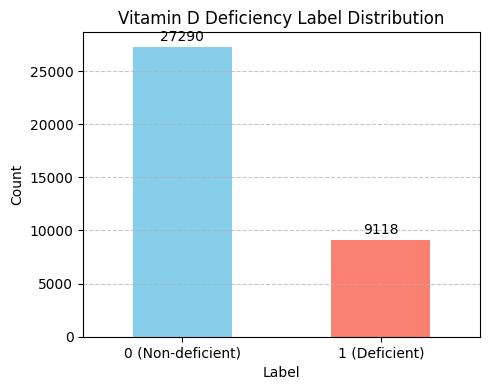

In [6]:
import matplotlib.pyplot as plt

# Count the labels
label_counts = df_train['label'].value_counts()

# Plot
plt.figure(figsize=(5, 4))
bars = label_counts.plot(kind='bar', color=['skyblue', 'salmon'])

# Add numbers on top of bars
for i, count in enumerate(label_counts):
    plt.text(i, count + max(label_counts) * 0.01, str(count), ha='center', va='bottom', fontsize=10)

plt.title('Vitamin D Deficiency Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['0 (Non-deficient)', '1 (Deficient)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


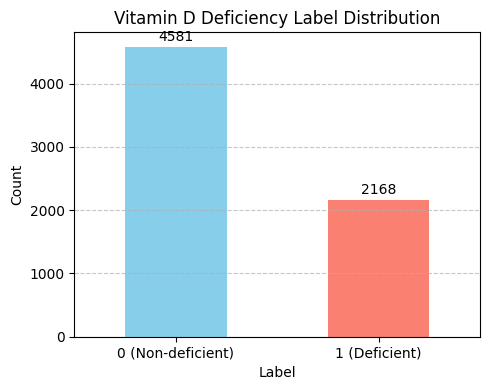

In [7]:
import matplotlib.pyplot as plt

# Count the labels
label_counts = df_test['label'].value_counts()

# Plot
plt.figure(figsize=(5, 4))
bars = label_counts.plot(kind='bar', color=['skyblue', 'salmon'])

# Add numbers on top of bars
for i, count in enumerate(label_counts):
    plt.text(i, count + max(label_counts) * 0.01, str(count), ha='center', va='bottom', fontsize=10)

plt.title('Vitamin D Deficiency Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['0 (Non-deficient)', '1 (Deficient)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [8]:
category_columns = [
    'Gender', 'Race', 'label','milk_consumption'
]

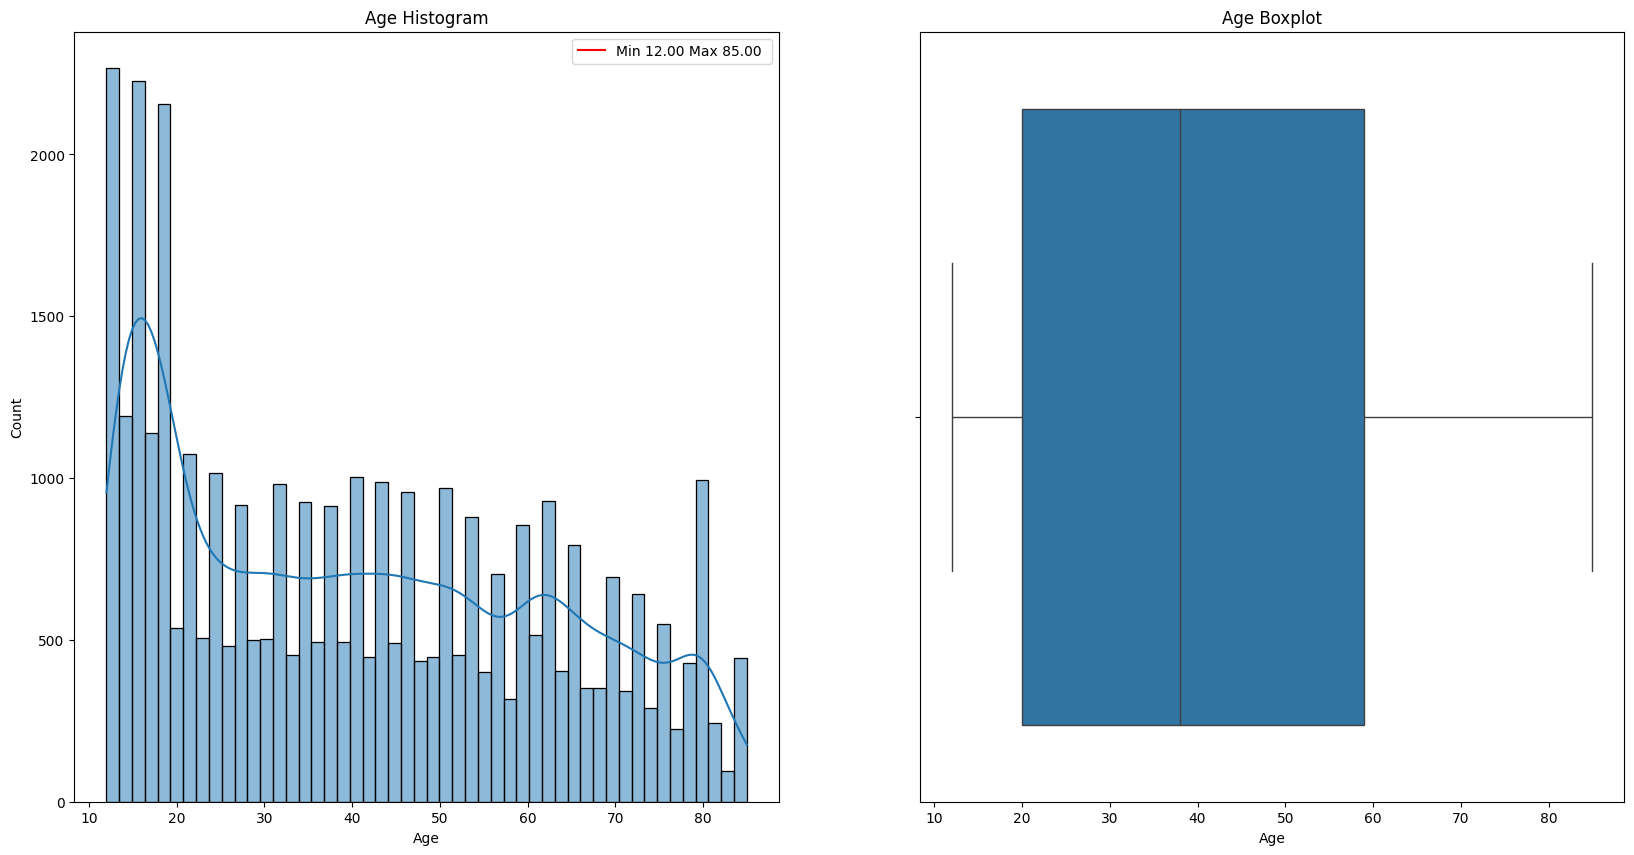

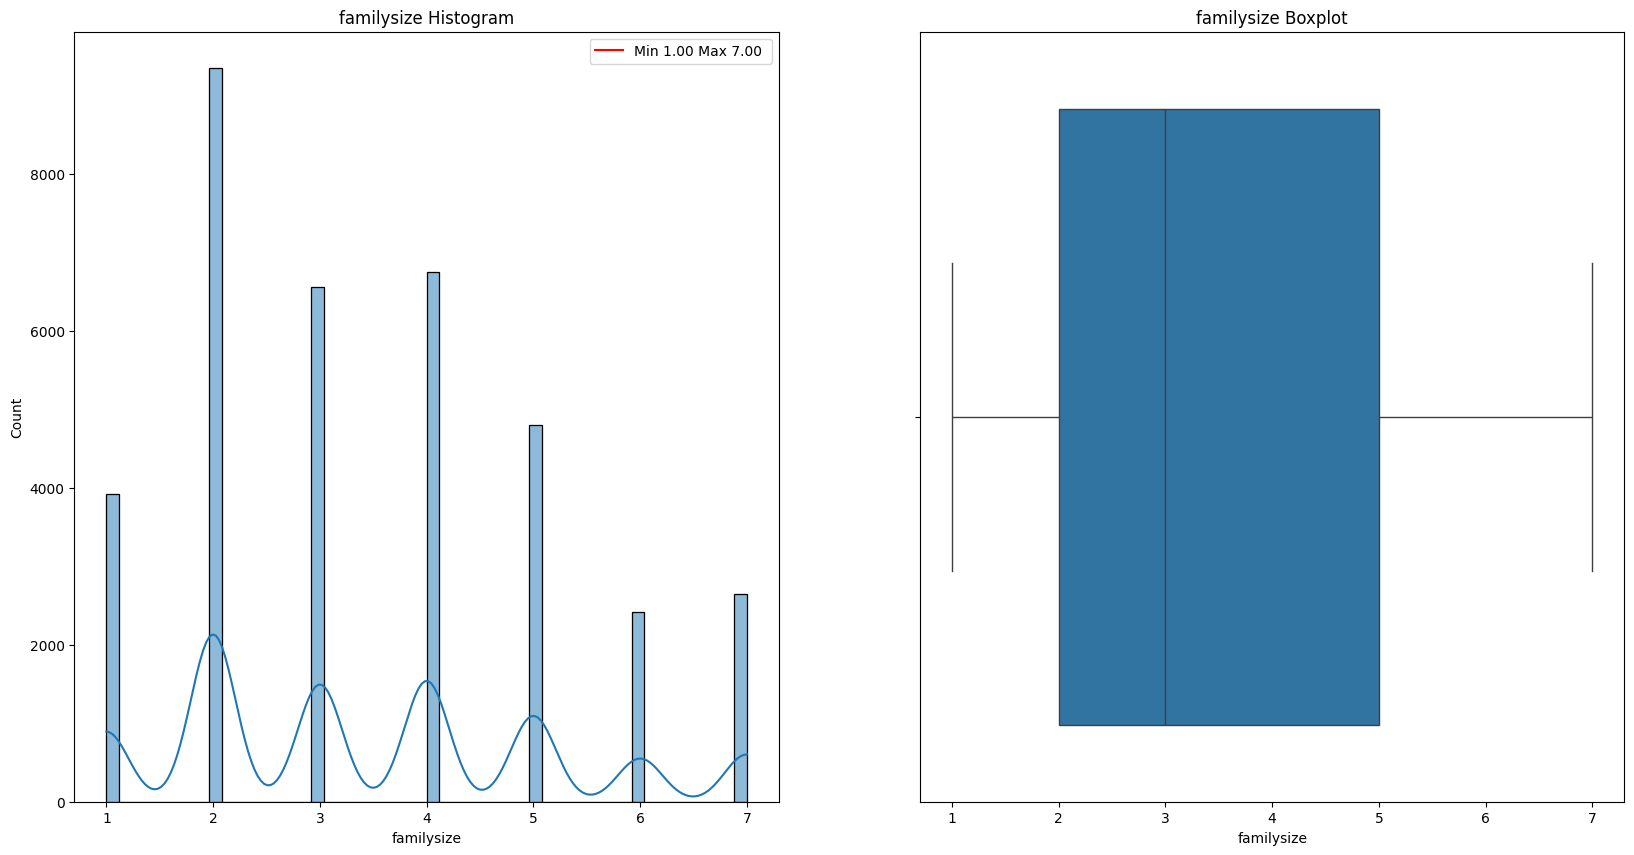

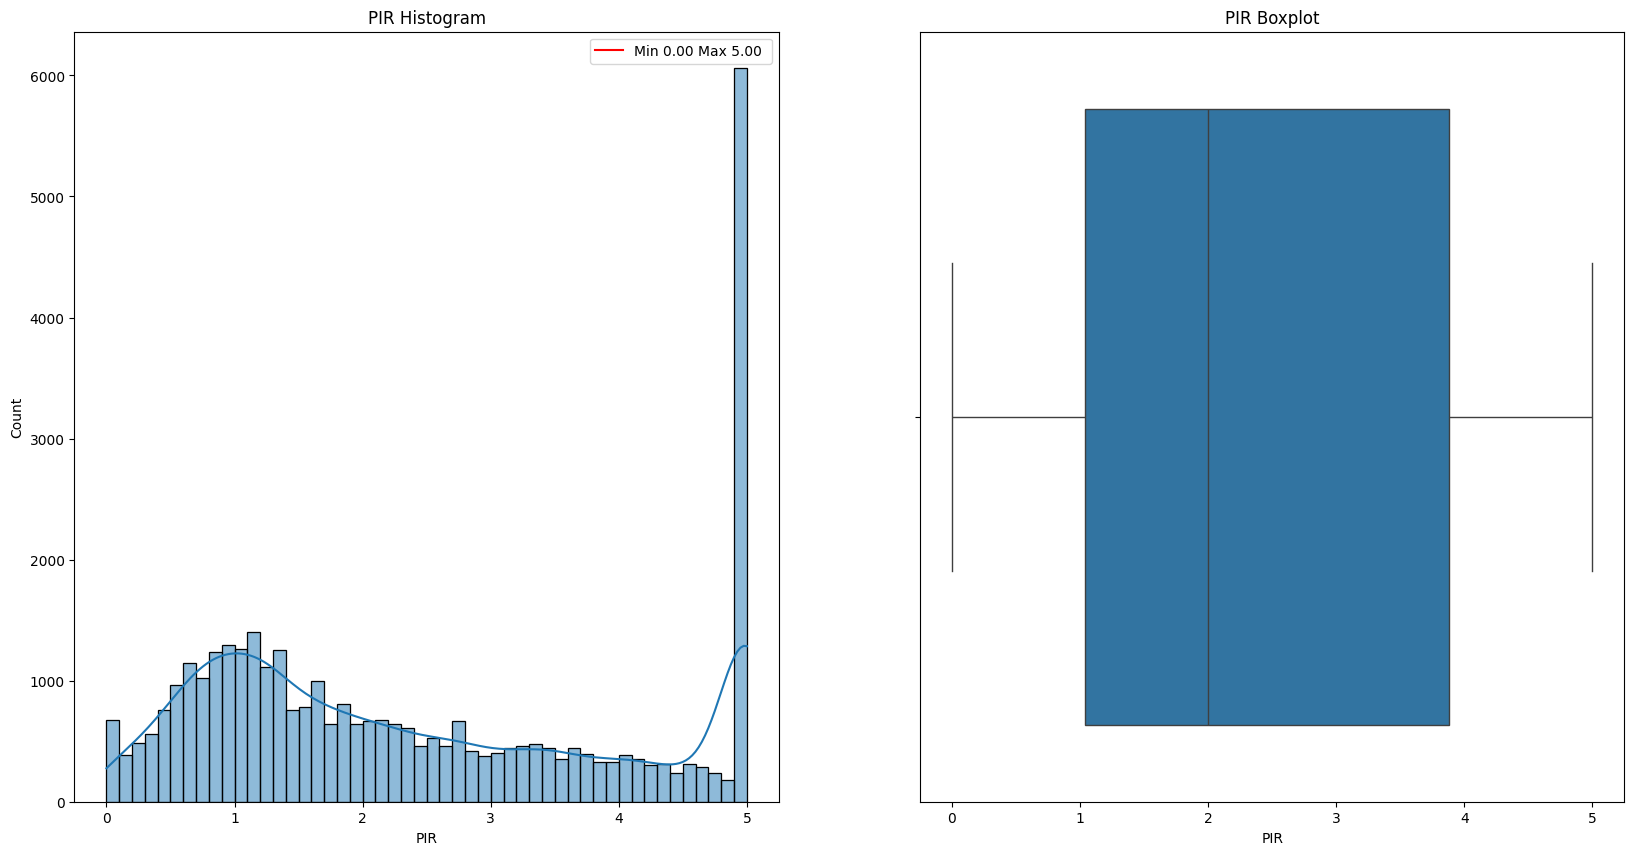

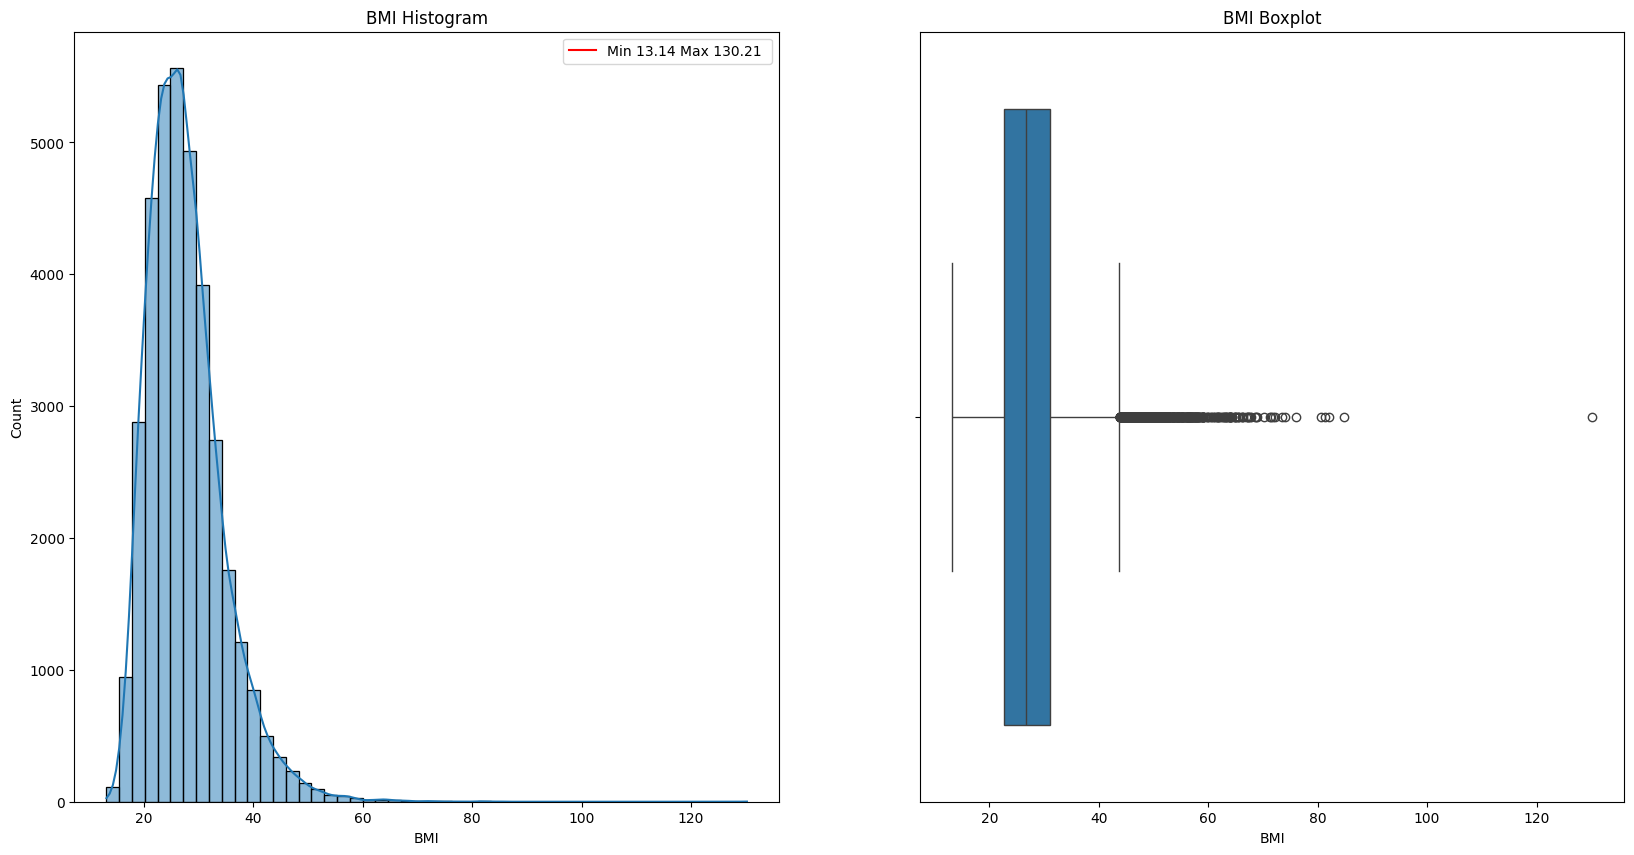

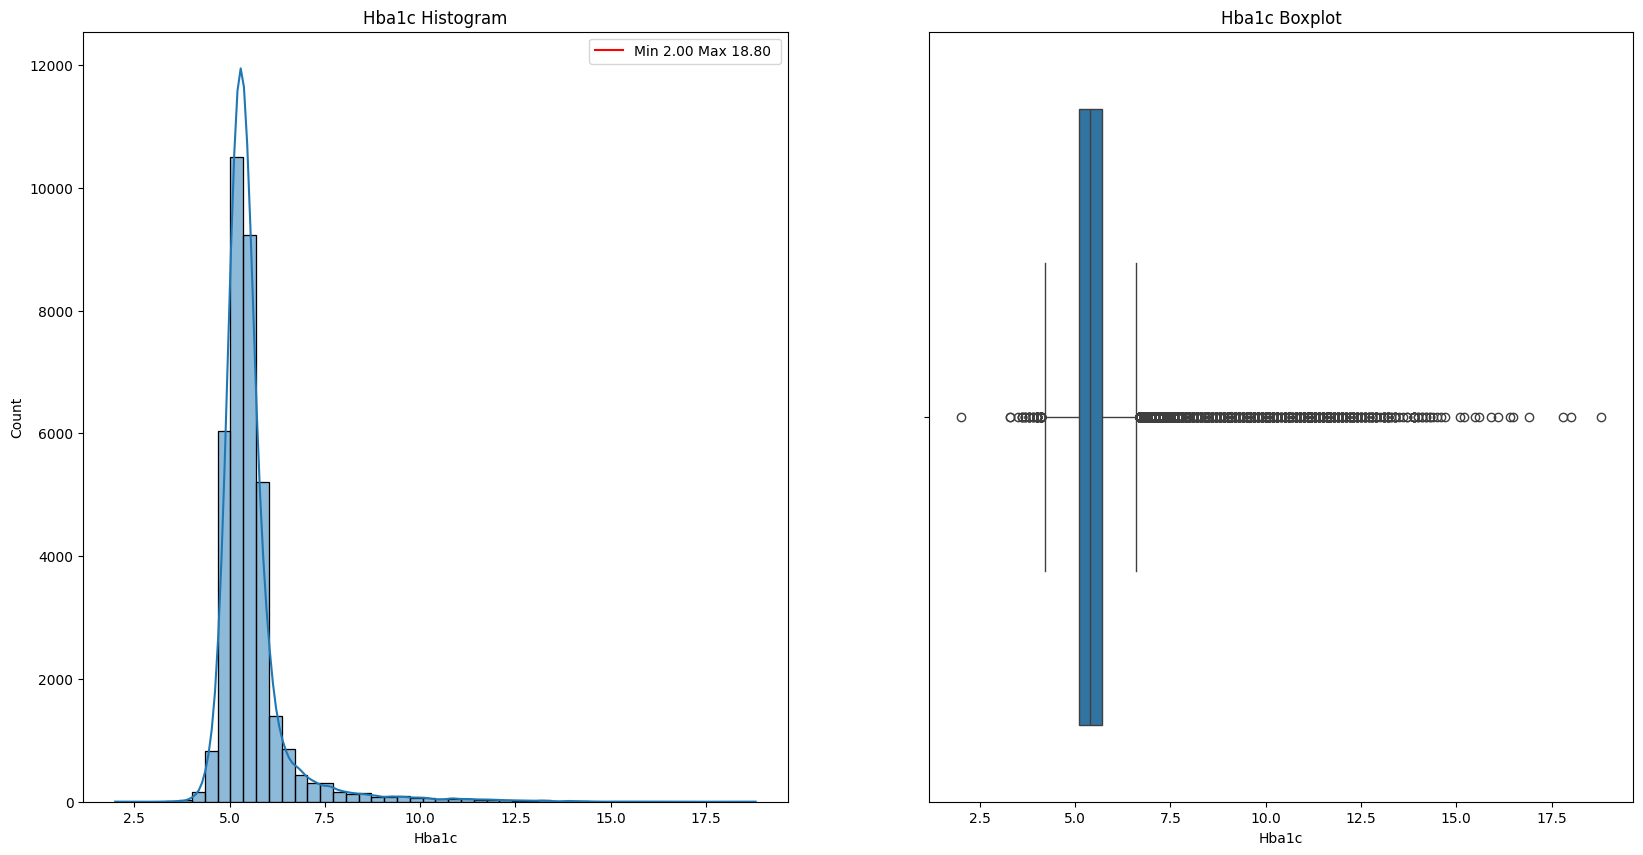

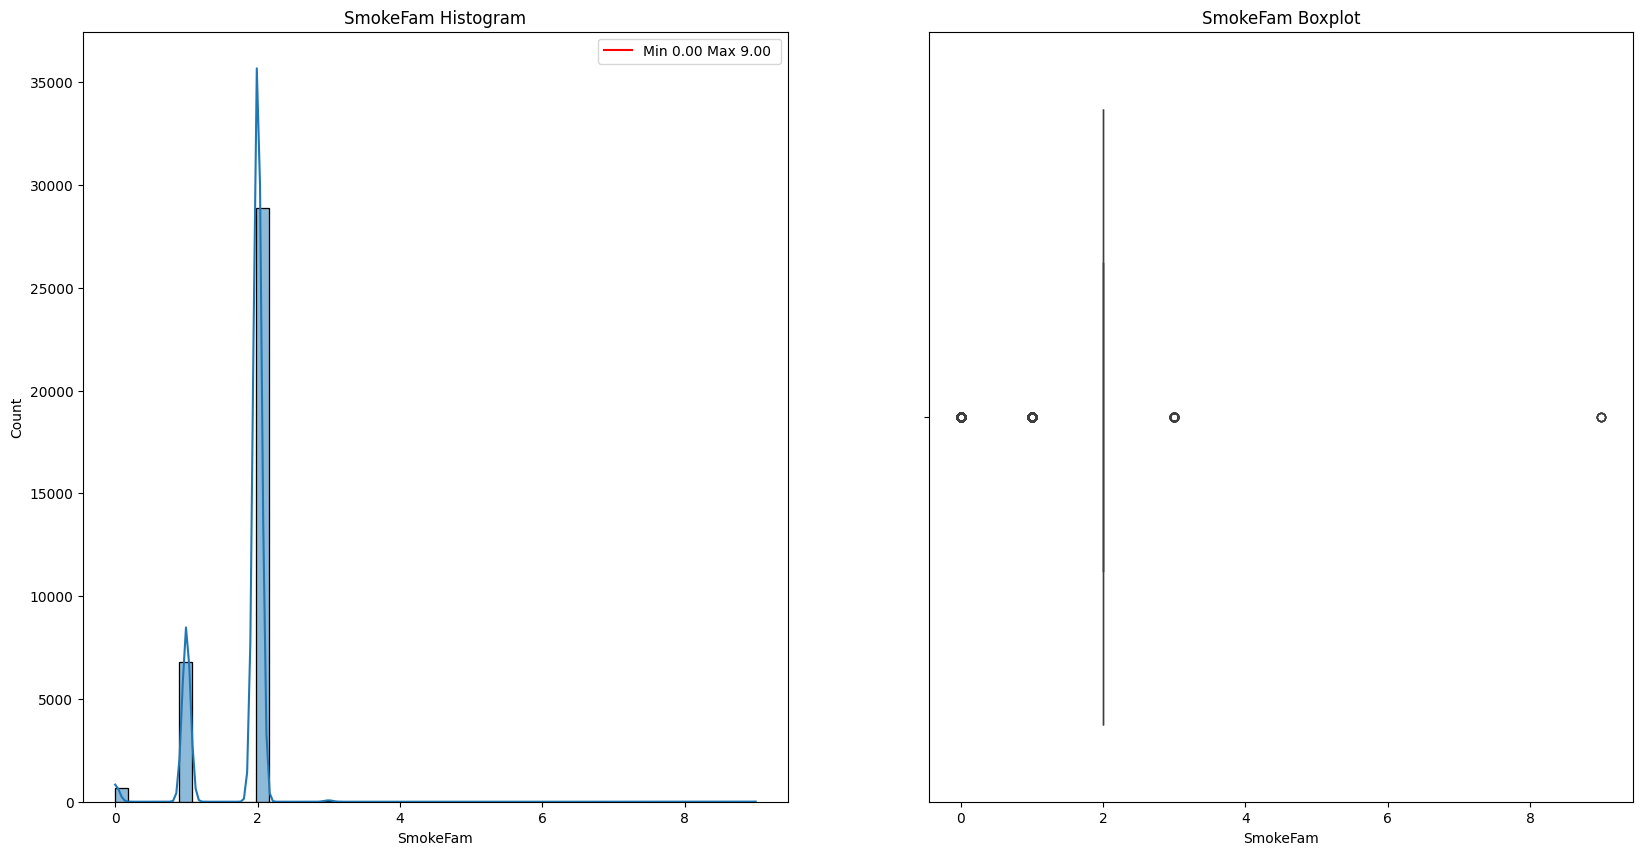

In [9]:
#revisuallize clean data
df_scaled = df_train.copy()
df_scaled.drop(columns=category_columns, inplace=True)

for col in df_scaled.columns:
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    sns.histplot(df_scaled[col], bins=50, kde=True)
    
    plt.plot([], [], label = f"Min {df_scaled[col].min():.2f} Max {df_scaled[col].max():.2f} ", color='red')
    plt.legend()
    plt.title(f"{col} Histogram")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_scaled[col])
    plt.title(f"{col} Boxplot")

    plt.show()


## Model training and evaluation

In [133]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36408 entries, 0 to 36563
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            36408 non-null  float64
 1   Age               36408 non-null  float64
 2   Race              36408 non-null  float64
 3   familysize        36408 non-null  float64
 4   PIR               36408 non-null  float64
 5   BMI               36408 non-null  float64
 6   Hba1c             36408 non-null  float64
 7   milk_consumption  36408 non-null  float64
 8   SmokeFam          36408 non-null  float64
 9   label             36408 non-null  float64
dtypes: float64(10)
memory usage: 3.1 MB


In [120]:
df_generated = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\baselinestore\generated_minority_data18000.csv")

In [121]:
df_train['label'].value_counts()

label
0.0    27290
1.0     9118
Name: count, dtype: int64

In [106]:
df_train = pd.concat([df_train,df_generated],ignore_index=True)

In [134]:
df_train['label'].value_counts()

label
0.0    27290
1.0     9118
Name: count, dtype: int64

Epoch 1/50, Contrastive Loss: 1139.3516
Epoch 2/50, Contrastive Loss: 1117.9712
Epoch 3/50, Contrastive Loss: 1114.7359
Epoch 4/50, Contrastive Loss: 1113.0856
Epoch 5/50, Contrastive Loss: 1111.1986
Epoch 6/50, Contrastive Loss: 1109.5398
Epoch 7/50, Contrastive Loss: 1108.7419
Epoch 8/50, Contrastive Loss: 1107.6549
Epoch 9/50, Contrastive Loss: 1107.0294
Epoch 10/50, Contrastive Loss: 1106.0250
Epoch 11/50, Contrastive Loss: 1105.7497
Epoch 12/50, Contrastive Loss: 1105.4626
Epoch 13/50, Contrastive Loss: 1105.8338
Epoch 14/50, Contrastive Loss: 1104.2599
Epoch 15/50, Contrastive Loss: 1104.8131
Epoch 16/50, Contrastive Loss: 1104.7831
Epoch 17/50, Contrastive Loss: 1103.3937
Epoch 18/50, Contrastive Loss: 1103.3830
Epoch 19/50, Contrastive Loss: 1103.6077
Epoch 20/50, Contrastive Loss: 1103.7432
Epoch 21/50, Contrastive Loss: 1102.8991
Epoch 22/50, Contrastive Loss: 1102.4061
Epoch 23/50, Contrastive Loss: 1103.0411
Epoch 24/50, Contrastive Loss: 1102.4506
Epoch 25/50, Contrastive 

c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:41:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.62      0.70      4581
         1.0       0.46      0.68      0.55      2168

    accuracy                           0.64      6749
   macro avg       0.63      0.65      0.63      6749
weighted avg       0.70      0.64      0.65      6749



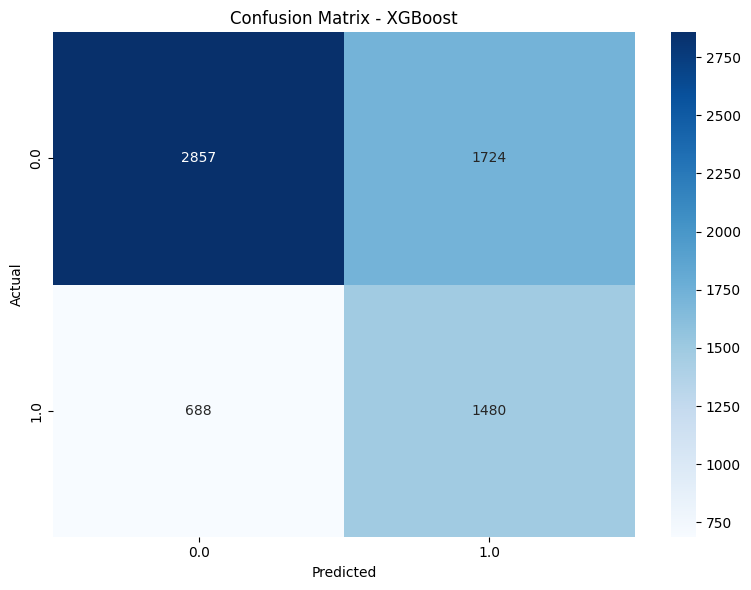

✅ Exported results to model_comparison_results_contrastive.csv


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

# ==== Prepare Data ====
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

# ==== Preprocessing ====
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

X_train_np = preprocessor.fit_transform(X_train_raw)
X_test_np = preprocessor.transform(X_test_raw)
input_dim = X_train_np.shape[1]

# ==== Contrastive Learning Components ====

def augment(x, noise_std=0.05, dropout_rate=0.1):
    x_noisy = x.copy()
    x_noisy += np.random.normal(0, noise_std, x.shape)
    dropout_mask = np.random.binomial(1, 1 - dropout_rate, x.shape)
    x_noisy *= dropout_mask
    return x_noisy

class ContrastiveDataset(Dataset):
    def __init__(self, X):
        self.X = X.astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        x_i = augment(x)
        x_j = augment(x)
        return torch.tensor(x_i), torch.tensor(x_j)

class TabularEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.encoder(x)

def nt_xent_loss(z_i, z_j, temperature=0.5):
    z_i = F.normalize(z_i, dim=1)
    z_j = F.normalize(z_j, dim=1)
    N = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)
    sim = torch.mm(z, z.t())
    sim_exp = torch.exp(sim / temperature)
    mask = (~torch.eye(2 * N, dtype=bool)).to(z.device)
    sim_exp = sim_exp * mask
    pos_sim = torch.exp(torch.sum(z_i * z_j, dim=1) / temperature)
    pos_sim = torch.cat([pos_sim, pos_sim], dim=0)
    loss = -torch.log(pos_sim / sim_exp.sum(dim=1))
    return loss.mean()

# ==== Contrastive Training ====

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = TabularEncoder(input_dim=input_dim).to(device)
optimizer = torch.optim.Adam(encoder.parameters(), lr=1e-3)

dataset = ContrastiveDataset(X_train_np)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
epochs = 50

for epoch in range(epochs):
    encoder.train()
    total_loss = 0
    for x_i, x_j in dataloader:
        x_i, x_j = x_i.to(device), x_j.to(device)
        z_i = encoder(x_i)
        z_j = encoder(x_j)
        loss = nt_xent_loss(z_i, z_j)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Contrastive Loss: {total_loss:.4f}")

# ==== Feature Extraction ====
encoder.eval()
with torch.no_grad():
    X_train_embed = encoder(torch.tensor(X_train_np, dtype=torch.float32).to(device)).cpu().numpy()
    X_test_embed = encoder(torch.tensor(X_test_np, dtype=torch.float32).to(device)).cpu().numpy()

# ==== Classification Models ====

models_to_test = {
    'XGBoost': XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.05, max_depth=7,
        n_estimators=100, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
}

results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")
    
    pipe = ImbPipeline(steps=[
        ('smote', SMOTETomek(random_state=42, sampling_strategy='minority')),
        ('classifier', model)
    ])
    
    pipe.fit(X_train_embed, y_train)
    y_pred = pipe.predict(X_test_embed)
    y_proba = pipe.predict_proba(X_test_embed)

    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })

    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results_contrastive.csv", index=False)
print("✅ Exported results to model_comparison_results_contrastive.csv")


Epoch 1/50, Contrastive Loss: 1137.7525
Epoch 2/50, Contrastive Loss: 1118.2112
Epoch 3/50, Contrastive Loss: 1116.2145
Epoch 4/50, Contrastive Loss: 1113.2212
Epoch 5/50, Contrastive Loss: 1112.2042
Epoch 6/50, Contrastive Loss: 1110.0718
Epoch 7/50, Contrastive Loss: 1109.1045
Epoch 8/50, Contrastive Loss: 1108.9021
Epoch 9/50, Contrastive Loss: 1107.5787
Epoch 10/50, Contrastive Loss: 1106.8699
Epoch 11/50, Contrastive Loss: 1106.1025
Epoch 12/50, Contrastive Loss: 1105.9924
Epoch 13/50, Contrastive Loss: 1106.5277
Epoch 14/50, Contrastive Loss: 1104.2642
Epoch 15/50, Contrastive Loss: 1105.0818
Epoch 16/50, Contrastive Loss: 1104.1615
Epoch 17/50, Contrastive Loss: 1103.3444
Epoch 18/50, Contrastive Loss: 1104.1167
Epoch 19/50, Contrastive Loss: 1103.4653
Epoch 20/50, Contrastive Loss: 1104.7540
Epoch 21/50, Contrastive Loss: 1103.2791
Epoch 22/50, Contrastive Loss: 1104.2158
Epoch 23/50, Contrastive Loss: 1103.0249
Epoch 24/50, Contrastive Loss: 1103.0703
Epoch 25/50, Contrastive 

c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:45:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.88      0.80      4581
         1.0       0.56      0.32      0.40      2168

    accuracy                           0.70      6749
   macro avg       0.65      0.60      0.60      6749
weighted avg       0.68      0.70      0.67      6749



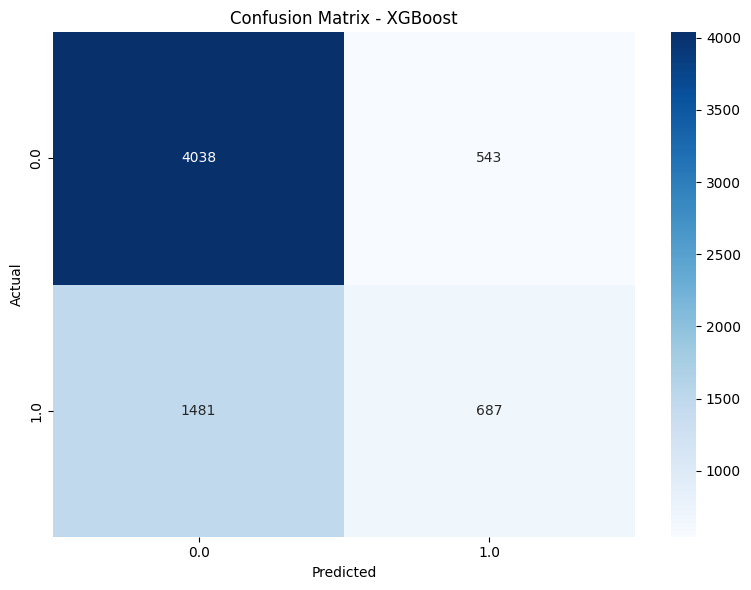

✅ Exported results to model_comparison_results_contrastive_no_smote.csv


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

from xgboost import XGBClassifier

# ==== Prepare Data ====
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

# ==== Preprocessing ====
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

X_train_np = preprocessor.fit_transform(X_train_raw)
X_test_np = preprocessor.transform(X_test_raw)
input_dim = X_train_np.shape[1]

# ==== Contrastive Learning Components ====

def augment(x, noise_std=0.05, dropout_rate=0.1):
    x_noisy = x.copy()
    x_noisy += np.random.normal(0, noise_std, x.shape)
    dropout_mask = np.random.binomial(1, 1 - dropout_rate, x.shape)
    x_noisy *= dropout_mask
    return x_noisy

class ContrastiveDataset(Dataset):
    def __init__(self, X):
        self.X = X.astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        x_i = augment(x)
        x_j = augment(x)
        return torch.tensor(x_i), torch.tensor(x_j)

class TabularEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.encoder(x)

def nt_xent_loss(z_i, z_j, temperature=0.5):
    z_i = F.normalize(z_i, dim=1)
    z_j = F.normalize(z_j, dim=1)
    N = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)
    sim = torch.mm(z, z.t())
    sim_exp = torch.exp(sim / temperature)
    mask = (~torch.eye(2 * N, dtype=bool)).to(z.device)
    sim_exp = sim_exp * mask
    pos_sim = torch.exp(torch.sum(z_i * z_j, dim=1) / temperature)
    pos_sim = torch.cat([pos_sim, pos_sim], dim=0)
    loss = -torch.log(pos_sim / sim_exp.sum(dim=1))
    return loss.mean()

# ==== Contrastive Training ====

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = TabularEncoder(input_dim=input_dim).to(device)
optimizer = torch.optim.Adam(encoder.parameters(), lr=1e-3)

dataset = ContrastiveDataset(X_train_np)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
epochs = 50

for epoch in range(epochs):
    encoder.train()
    total_loss = 0
    for x_i, x_j in dataloader:
        x_i, x_j = x_i.to(device), x_j.to(device)
        z_i = encoder(x_i)
        z_j = encoder(x_j)
        loss = nt_xent_loss(z_i, z_j)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Contrastive Loss: {total_loss:.4f}")

# ==== Feature Extraction ====
encoder.eval()
with torch.no_grad():
    X_train_embed = encoder(torch.tensor(X_train_np, dtype=torch.float32).to(device)).cpu().numpy()
    X_test_embed = encoder(torch.tensor(X_test_np, dtype=torch.float32).to(device)).cpu().numpy()

# ==== Classification Models ====

models_to_test = {
    'XGBoost': XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.05, max_depth=7,
        n_estimators=100, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
}

results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")
    
    model.fit(X_train_embed, y_train)
    y_pred = model.predict(X_test_embed)
    y_proba = model.predict_proba(X_test_embed)

    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })

    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results_contrastive_no_smote.csv", index=False)
print("✅ Exported results to model_comparison_results_contrastive_no_smote.csv")


In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# ==== STEP 1: Preprocess Tabular Data ====

categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Optional: Use SMOTE to handle imbalance
X_train, y_train = SMOTE().fit_resample(X_train, y_train)

# ==== STEP 2: Define Contrastive Learning Model ====

class ContrastiveMLP(nn.Module):
    def __init__(self, input_dim, emb_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, emb_dim)
        )

    def forward(self, x):
        emb = self.encoder(x)
        return F.normalize(emb, dim=1)

class ContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, zi, zj):
        batch_size = zi.shape[0]
        z = torch.cat([zi, zj], dim=0)
        sim_matrix = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
        sim_matrix = sim_matrix / self.temperature

        labels = torch.arange(batch_size).repeat(2)
        labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
        mask = torch.eye(2 * batch_size).bool()
        labels = labels[~mask].view(2 * batch_size, -1)
        sim_matrix = sim_matrix[~mask].view(2 * batch_size, -1)

        loss = -torch.log(torch.exp(sim_matrix) / torch.exp(sim_matrix).sum(dim=1, keepdim=True))
        return loss.mean()

# ==== STEP 3: Contrastive Training ====

def augment(X):
    # simple Gaussian noise augmentation
    return X + 0.05 * np.random.randn(*X.shape)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
input_dim = X_train.shape[1]
model = ContrastiveMLP(input_dim).to(device)
criterion = ContrastiveLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X_tensor = torch.tensor(X_train.toarray() if hasattr(X_train, "toarray") else X_train).float().to(device)
for epoch in range(50):
    model.train()
    x_i = augment(X_tensor.cpu().numpy())
    x_j = augment(X_tensor.cpu().numpy())
    x_i = torch.tensor(x_i).float().to(device)
    x_j = torch.tensor(x_j).float().to(device)

    z_i = model(x_i)
    z_j = model(x_j)
    loss = criterion(z_i, z_j)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# ==== STEP 4: Use Embeddings for Classification ====

model.eval()
with torch.no_grad():
    emb_train = model(X_tensor).cpu().numpy()
    emb_test = model(torch.tensor(X_test.toarray() if hasattr(X_test, "toarray") else X_test).float().to(device)).cpu().numpy()

# ==== STEP 5: Test Multiple Classifiers ====

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "LGBM": LGBMClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "GBDT": GradientBoostingClassifier()
}

for name, clf in models.items():
    print(f"🔍 Training {name}")
    clf.fit(emb_train, y_train)
    y_pred = clf.predict(emb_test)
    print(f"\n🧾 Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("="*60)


RuntimeError: [enforce fail at alloc_cpu.cpp:116] data. DefaultCPUAllocator: not enough memory: you tried to allocate 47663622400 bytes.

In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# ==== STEP 1: Preprocess Tabular Data ====

categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols)
    ]
)

X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Optional: Use SMOTE to handle imbalance
use_smote = True
if use_smote:
    X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

# ==== STEP 2: Define Contrastive Learning Model ====

class ContrastiveMLP(nn.Module):
    def __init__(self, input_dim, emb_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, emb_dim)
        )

    def forward(self, x):
        emb = self.encoder(x)
        return F.normalize(emb, dim=1)

class ContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, zi, zj):
        batch_size = zi.size(0)
        z = torch.cat([zi, zj], dim=0)
        sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2) / self.temperature

        labels = torch.arange(batch_size).repeat(2).to(z.device)
        mask = torch.eye(2 * batch_size, dtype=bool).to(z.device)
        positive_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)) & (~mask)

        sim = sim.masked_fill(mask, float('-inf'))  # exclude self-similarity
        sim_exp = torch.exp(sim)
        sim_sum = sim_exp.sum(dim=1, keepdim=True)
        pos_sim = sim_exp[positive_mask].view(2 * batch_size, -1)

        loss = -torch.log(pos_sim / sim_sum)
        return loss.mean()

# ==== STEP 3: Contrastive Training ====

def augment(X, noise_std=0.05):
    return X + noise_std * np.random.randn(*X.shape)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = X_train.shape[1]
model = ContrastiveMLP(input_dim=input_dim).to(device)
criterion = ContrastiveLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Convert sparse to dense if needed, and ensure float32 for memory efficiency
X_array = X_train.toarray() if hasattr(X_train, "toarray") else X_train
X_array = np.asarray(X_array, dtype=np.float32)

X_tensor = torch.tensor(X_array).to(device)

epochs = 30
batch_size = 256

for epoch in range(epochs):
    model.train()
    total_loss = 0
    perm = np.random.permutation(X_tensor.shape[0])
    for i in range(0, len(perm), batch_size):
        batch_idx = perm[i:i+batch_size]
        x_i = torch.tensor(augment(X_array[batch_idx]), dtype=torch.float32).to(device)
        x_j = torch.tensor(augment(X_array[batch_idx]), dtype=torch.float32).to(device)

        z_i = model(x_i)
        z_j = model(x_j)
        loss = criterion(z_i, z_j)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] - Contrastive Loss: {total_loss:.4f}")

# ==== STEP 4: Use Embeddings for Classification ====

model.eval()
with torch.no_grad():
    X_train_embed = model(X_tensor).cpu().numpy()
    X_test_array = X_test.toarray() if hasattr(X_test, "toarray") else X_test
    X_test_tensor = torch.tensor(np.asarray(X_test_array, dtype=np.float32)).to(device)
    X_test_embed = model(X_test_tensor).cpu().numpy()

# ==== STEP 5: Test Multiple Classifiers ====

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "LGBM": LGBMClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "GBDT": GradientBoostingClassifier()
}

for name, clf in models.items():
    print(f"\n🔍 Training {name}")
    clf.fit(X_train_embed, y_train)
    y_pred = clf.predict(X_test_embed)

    print(f"\n🧾 Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("=" * 60)


Epoch [1/30] - Contrastive Loss: 946.2803
Epoch [2/30] - Contrastive Loss: 930.3447
Epoch [3/30] - Contrastive Loss: 927.9180
Epoch [4/30] - Contrastive Loss: 926.2537
Epoch [5/30] - Contrastive Loss: 925.2991
Epoch [6/30] - Contrastive Loss: 924.5652
Epoch [7/30] - Contrastive Loss: 924.0366
Epoch [8/30] - Contrastive Loss: 923.4931
Epoch [9/30] - Contrastive Loss: 922.9503
Epoch [10/30] - Contrastive Loss: 922.5710
Epoch [11/30] - Contrastive Loss: 922.3326
Epoch [12/30] - Contrastive Loss: 922.1049
Epoch [13/30] - Contrastive Loss: 921.8971
Epoch [14/30] - Contrastive Loss: 921.6604
Epoch [15/30] - Contrastive Loss: 921.6314
Epoch [16/30] - Contrastive Loss: 921.3918
Epoch [17/30] - Contrastive Loss: 921.2270
Epoch [18/30] - Contrastive Loss: 921.1366
Epoch [19/30] - Contrastive Loss: 920.8685
Epoch [20/30] - Contrastive Loss: 920.7602
Epoch [21/30] - Contrastive Loss: 920.8178
Epoch [22/30] - Contrastive Loss: 920.6029
Epoch [23/30] - Contrastive Loss: 920.5527
Epoch [24/30] - Cont

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:01:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🧾 Classification Report for LGBM:

              precision    recall  f1-score   support

         0.0     0.8169    0.4412    0.5729      4581
         1.0     0.4012    0.7911    0.5324      2168

    accuracy                         0.5536      6749
   macro avg     0.6090    0.6161    0.5526      6749
weighted avg     0.6834    0.5536    0.5599      6749

Confusion Matrix:
 [[2021 2560]
 [ 453 1715]]

🔍 Training XGBoost

🧾 Classification Report for XGBoost:

              precision    recall  f1-score   support

         0.0     0.7913    0.5726    0.6644      4581
         1.0     0.4298    0.6808    0.5270      2168

    accuracy                         0.6073      6749
   macro avg     0.6105    0.6267    0.5957      6749
weighted avg     0.6751    0.6073    0.6202      6749

Confusion Matrix:
 [[2623 1958]
 [ 692 1476]]

🔍 Training GBDT

🧾 Classification Report for GBDT:

              precision    recall  f1-score   support

         0.0     0.8199    0.3508    0.4914      45

In [14]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Your data (replace with actual df_train and df_test)
# df_train = ...
# df_test = ...

# Prepare input/output
X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

# Column types
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
numeric_cols = [col for col in X_train_raw.columns if col not in categorical_cols]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Models to compare
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier()
}

# Fit and evaluate each
for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocess', preprocessor),
        ('smote', SMOTE()),
        ('clf', model)
    ])
    pipeline.fit(X_train_raw, y_train)
    y_pred = pipeline.predict(X_test_raw)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))

# -----------------------------
# Contrastive Learning Section
# -----------------------------

class ContrastiveDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class ContrastiveNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.classifier = nn.Linear(32, 2)
    def forward(self, x):
        emb = self.encoder(x)
        out = self.classifier(emb)
        return emb, out

def contrastive_loss(embeddings, labels, margin=1.0):
    batch_size = len(labels)
    loss = 0
    for i in range(batch_size):
        for j in range(i + 1, batch_size):
            dist = torch.norm(embeddings[i] - embeddings[j])
            if labels[i] == labels[j]:
                loss += dist ** 2
            else:
                loss += torch.clamp(margin - dist, min=0) ** 2
    return loss / batch_size

# Prepare encoded data
X_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

# Use SMOTE to balance
X_smote, y_smote = SMOTE().fit_resample(X_processed, y_train)

# Create dataset and loader
train_data = ContrastiveDataset(X_smote, y_smote)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)

# Build model
input_dim = X_smote.shape[1]
model = ContrastiveNet(input_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
ce_loss = nn.CrossEntropyLoss()

# Training loop
model.train()
for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        emb, out = model(X_batch)
        loss1 = ce_loss(out, y_batch)
        loss2 = contrastive_loss(emb, y_batch)
        loss = loss1 + 0.1 * loss2
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} - Loss: {total_loss:.4f}")

# Evaluate
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
    _, logits = model(X_test_tensor)
    preds = torch.argmax(logits, dim=1).numpy()
print("\nContrastive Neural Network Report:")
print(classification_report(y_test, preds))



LogisticRegression Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.49      0.62      4581
         1.0       0.43      0.82      0.57      2168

    accuracy                           0.60      6749
   macro avg       0.64      0.66      0.59      6749
weighted avg       0.72      0.60      0.60      6749


RandomForest Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.84      0.79      4581
         1.0       0.56      0.43      0.48      2168

    accuracy                           0.71      6749
   macro avg       0.66      0.63      0.64      6749
weighted avg       0.69      0.71      0.70      6749



c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:06:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.86      0.81      4581
         1.0       0.59      0.41      0.48      2168

    accuracy                           0.72      6749
   macro avg       0.67      0.64      0.64      6749
weighted avg       0.70      0.72      0.70      6749

[LightGBM] [Info] Number of positive: 27290, number of negative: 27290
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9733
[LightGBM] [Info] Number of data points in the train set: 54580, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.85      0.80      4581
         1.0       0.58      0.43      0.50      2168

    accuracy                           0.72      6749
   macro avg       0.67      0.64      0.65      6749
weighted avg       0.70      0.72      0.70      6749



TypeError: sparse array length is ambiguous; use getnnz() or shape[0]

In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ===========================
# Define Dataset
# ===========================
class ContrastiveDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values if isinstance(y, pd.Series) else y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ===========================
# NT-Xent Loss (SimCLR style)
# ===========================
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        self.cos_sim = nn.CosineSimilarity(dim=2)

    def forward(self, z_i, z_j):
        batch_size = z_i.size(0)
        z = torch.cat([z_i, z_j], dim=0)
        sim = self.cos_sim(z.unsqueeze(1), z.unsqueeze(0)) / self.temperature

        labels = torch.arange(batch_size).to(z.device)
        labels = torch.cat([labels, labels], dim=0)

        mask = torch.eye(2 * batch_size, dtype=torch.bool).to(z.device)
        sim = sim.masked_fill(mask, -float('inf'))

        positives = torch.cat([torch.diag(sim, batch_size), torch.diag(sim, -batch_size)], dim=0)
        nominator = torch.exp(positives)
        denominator = torch.sum(torch.exp(sim), dim=1)

        loss = -torch.log(nominator / denominator)
        return loss.mean()

# ===========================
# Contrastive Encoder
# ===========================
class ContrastiveNet(nn.Module):
    def __init__(self, input_dim, emb_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, emb_dim)
        )
        self.classifier = nn.Linear(emb_dim, 2)

    def forward(self, x):
        emb = self.encoder(x)
        norm_emb = F.normalize(emb, dim=1)
        return norm_emb, self.classifier(emb)

# ===========================
# Augmentation (Gaussian noise)
# ===========================
def augment(X, noise_std=0.05):
    return X + noise_std * torch.randn_like(X)

# ===========================
# Main Training and Evaluation
# ===========================
def full_pipeline(df_train, df_test):
    X_train_raw = df_train.drop(columns=['label'])
    y_train = df_train['label']
    X_test_raw = df_test.drop(columns=['label'])
    y_test = df_test['label']

    categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
    numeric_cols = [col for col in X_train_raw.columns if col not in categorical_cols]

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

    X_train_processed = preprocessor.fit_transform(X_train_raw)
    X_test_processed = preprocessor.transform(X_test_raw)

    X_train_bal, y_train_bal = SMOTE().fit_resample(X_train_processed, y_train)
    train_data = ContrastiveDataset(X_train_bal, y_train_bal)
    train_loader = DataLoader(train_data, batch_size=256, shuffle=True)

    model = ContrastiveNet(input_dim=X_train_bal.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    ce_loss = nn.CrossEntropyLoss()
    contrastive_loss = NTXentLoss()

    model.train()
    for epoch in range(20):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            z, out = model(X_batch)
            z_i = augment(X_batch)
            z_j = augment(X_batch)
            z_i = model.encoder(z_i)
            z_j = model.encoder(z_j)
            z_i = F.normalize(z_i, dim=1)
            z_j = F.normalize(z_j, dim=1)
            loss = ce_loss(out, y_batch) + 0.1 * contrastive_loss(z_i, z_j)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

    model.eval()
    with torch.no_grad():
        X_train_tensor = torch.tensor(X_train_bal, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test_processed.toarray() if hasattr(X_test_processed, 'toarray') else X_test_processed, dtype=torch.float32)
        train_embeddings, _ = model(X_train_tensor)
        test_embeddings, logits = model(X_test_tensor)
        test_preds = torch.argmax(logits, dim=1).numpy()

    print("\n📊 Contrastive Classifier Report:")
    print(classification_report(y_test, test_preds))
    print("AUC:", roc_auc_score(y_test, torch.softmax(logits, dim=1)[:, 1].numpy()))

    print("\n🧪 Testing Other Classifiers with Embeddings")
    classifiers = {
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "RandomForest": RandomForestClassifier(),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "LightGBM": LGBMClassifier()
    }

    for name, clf in classifiers.items():
        clf.fit(train_embeddings.numpy(), y_train_bal)
        preds = clf.predict(test_embeddings.numpy())
        proba = clf.predict_proba(test_embeddings.numpy())[:, 1]
        print(f"\n{name} Report:")
        print(classification_report(y_test, preds))
        print("AUC:", roc_auc_score(y_test, proba))

# Example usage:
full_pipeline(df_train, df_test)


TypeError: sparse array length is ambiguous; use getnnz() or shape[0]

In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# -----------------------------
# Dataset & Augmentation
# -----------------------------
class ContrastiveDataset(Dataset):
    def __init__(self, X, y):
        if hasattr(X, "toarray"):
            X = X.toarray()  # Convert sparse to dense if necessary
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values if isinstance(y, pd.Series) else y, dtype=torch.long)

    def add_noise(self, x, noise_level=0.05):
        return x + noise_level * torch.randn_like(x)

    def apply_dropout(self, x, dropout_rate=0.1):
        mask = (torch.rand_like(x) > dropout_rate).float()
        return x * mask

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        # Augmentations for contrastive learning
        x1 = self.add_noise(x)
        x2 = self.apply_dropout(x)
        return x1, x2, y

    def __len__(self):
        return len(self.X)

# -----------------------------
# Contrastive Encoder
# -----------------------------
class ContrastiveNet(nn.Module):
    def __init__(self, input_dim, emb_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, emb_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return F.normalize(z, dim=1)

# -----------------------------
# NT-Xent Contrastive Loss
# -----------------------------
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        batch_size = z1.size(0)
        z = torch.cat([z1, z2], dim=0)
        sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
        sim = sim / self.temperature

        labels = torch.arange(batch_size).to(z.device)
        labels = torch.cat([labels, labels], dim=0)
        loss = F.cross_entropy(sim, labels)
        return loss

# -----------------------------
# Classifier Head
# -----------------------------
class Classifier(nn.Module):
    def __init__(self, encoder, emb_dim, n_classes):
        super().__init__()
        self.encoder = encoder
        self.clf = nn.Linear(emb_dim, n_classes)

    def forward(self, x):
        with torch.no_grad():  # Freeze encoder by default
            z = self.encoder(x)
        return self.clf(z)

# -----------------------------
# Training Loop
# -----------------------------
def train_contrastive(model, loader, device, epochs=20):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = NTXentLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x1, x2, _ in loader:
            x1, x2 = x1.to(device), x2.to(device)
            z1 = model(x1)
            z2 = model(x2)
            loss = criterion(z1, z2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Contrastive Loss: {total_loss/len(loader):.4f}")

# -----------------------------
# Full Pipeline
# -----------------------------
def full_pipeline(df_train, df_test, label_col='label'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Split
    X_train_raw = df_train.drop(columns=[label_col])
    y_train = df_train[label_col]
    X_test_raw = df_test.drop(columns=[label_col])
    y_test = df_test[label_col]

    # Preprocess
    num_cols = X_train_raw.select_dtypes(include='number').columns.tolist()
    cat_cols = X_train_raw.select_dtypes(include='object').columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    X_train_processed = preprocessor.fit_transform(X_train_raw)
    X_test_processed = preprocessor.transform(X_test_raw)

    # Handle sparse issue
    if hasattr(X_train_processed, "toarray"):
        X_train_processed = X_train_processed.toarray()
    if hasattr(X_test_processed, "toarray"):
        X_test_processed = X_test_processed.toarray()

    # SMOTE
    X_train_bal, y_train_bal = SMOTE().fit_resample(X_train_processed, y_train)

    # Contrastive Learning
    train_data = ContrastiveDataset(X_train_bal, y_train_bal)
    train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
    model = ContrastiveNet(input_dim=X_train_bal.shape[1])
    train_contrastive(model, train_loader, device)

    # Generate embeddings
    with torch.no_grad():
        model.eval()
        z_train = model(torch.tensor(X_train_bal, dtype=torch.float32).to(device)).cpu().numpy()
        z_test = model(torch.tensor(X_test_processed, dtype=torch.float32).to(device)).cpu().numpy()

    # Classifier with GridSearch
    param_grid = {'C': [0.01, 0.1, 1, 10]}
    clf = GridSearchCV(LogisticRegression(max_iter=500), param_grid, cv=3)
    clf.fit(z_train, y_train_bal)
    y_pred = clf.predict(z_test)
    proba = clf.predict_proba(z_test)[:, 1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, proba))

# -----------------------------
# Example use
# -----------------------------
# df = pd.read_csv("your_dataset.csv")
# df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
full_pipeline(df_train, df_test)


Epoch 1, Contrastive Loss: 4.5905
Epoch 2, Contrastive Loss: 4.5368
Epoch 3, Contrastive Loss: 4.5162
Epoch 4, Contrastive Loss: 4.5049
Epoch 5, Contrastive Loss: 4.4993
Epoch 6, Contrastive Loss: 4.4930
Epoch 7, Contrastive Loss: 4.4908
Epoch 8, Contrastive Loss: 4.4863
Epoch 9, Contrastive Loss: 4.4849
Epoch 10, Contrastive Loss: 4.4820
Epoch 11, Contrastive Loss: 4.4819
Epoch 12, Contrastive Loss: 4.4796
Epoch 13, Contrastive Loss: 4.4782
Epoch 14, Contrastive Loss: 4.4762
Epoch 15, Contrastive Loss: 4.4751
Epoch 16, Contrastive Loss: 4.4749
Epoch 17, Contrastive Loss: 4.4738
Epoch 18, Contrastive Loss: 4.4728
Epoch 19, Contrastive Loss: 4.4720
Epoch 20, Contrastive Loss: 4.4722
Accuracy: 0.4667358127129945
AUC: 0.6082827675035101


Epoch 1, Loss: 4.8886
Epoch 2, Loss: 4.8007
Epoch 3, Loss: 4.7873
Epoch 4, Loss: 4.7794
Epoch 5, Loss: 4.7755
Epoch 6, Loss: 4.7736
Epoch 7, Loss: 4.7689
Epoch 8, Loss: 4.7674
Epoch 9, Loss: 4.7665
Epoch 10, Loss: 4.7638
Epoch 11, Loss: 4.7646
Epoch 12, Loss: 4.7615
Epoch 13, Loss: 4.7612
Epoch 14, Loss: 4.7611
Epoch 15, Loss: 4.7581
Epoch 16, Loss: 4.7577
Epoch 17, Loss: 4.7575
Epoch 18, Loss: 4.7555
Epoch 19, Loss: 4.7536
Epoch 20, Loss: 4.7524

🔍 LogReg Evaluation:
              precision    recall  f1-score   support

         0.0     0.8046    0.4449    0.5730      4581
         1.0     0.3968    0.7717    0.5241      2168

    accuracy                         0.5499      6749
   macro avg     0.6007    0.6083    0.5485      6749
weighted avg     0.6736    0.5499    0.5573      6749

Accuracy: 0.5498592384056897
Precision: 0.3968216318785579
Recall: 0.7716789667896679
F1 Score: 0.5241228070175439
AUC: 0.6434882448038627


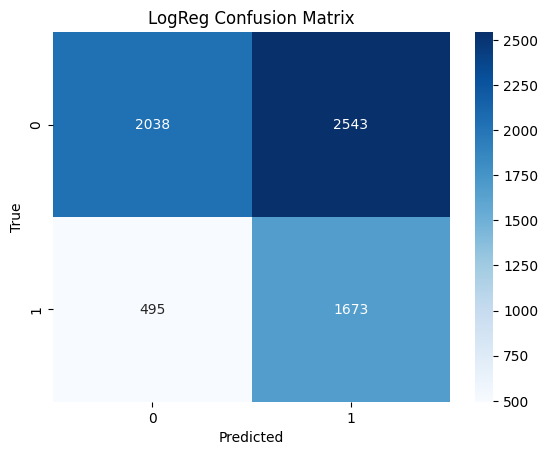

c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:51:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔍 XGB Evaluation:
              precision    recall  f1-score   support

         0.0     0.7742    0.5905    0.6700      4581
         1.0     0.4237    0.6361    0.5086      2168

    accuracy                         0.6051      6749
   macro avg     0.5989    0.6133    0.5893      6749
weighted avg     0.6616    0.6051    0.6181      6749

Accuracy: 0.6051266854348792
Precision: 0.4236559139784946
Recall: 0.636070110701107
F1 Score: 0.5085745897104923
AUC: 0.6559002328726626


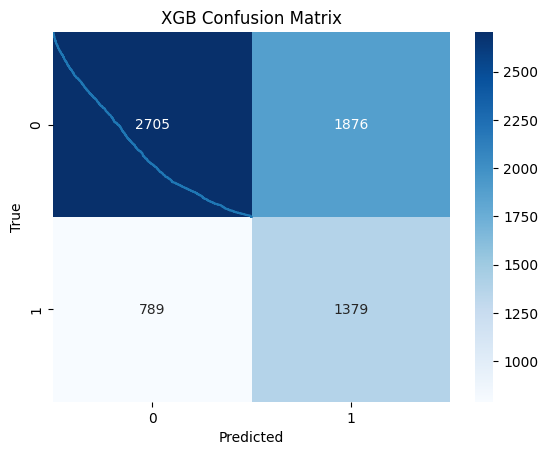

[LightGBM] [Info] Number of positive: 27290, number of negative: 27290
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005496 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16320
[LightGBM] [Info] Number of data points in the train set: 54580, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

🔍 LightGBM Evaluation:
              precision    recall  f1-score   support

         0.0     0.7938    0.5237    0.6311      4581
         1.0     0.4145    0.7126    0.5242      2168

    accuracy                         0.5844      6749
   macro avg     0.6042    0.6182    0.5776      6749
weighted avg     0.6720    0.5844    0.5967      6749

Accuracy: 0.5843828715365239
Precision: 0.41454252750201237
Recall: 0.7126383763837638
F1 Score: 0.5241730279898219
AUC: 0.6670817555425064


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


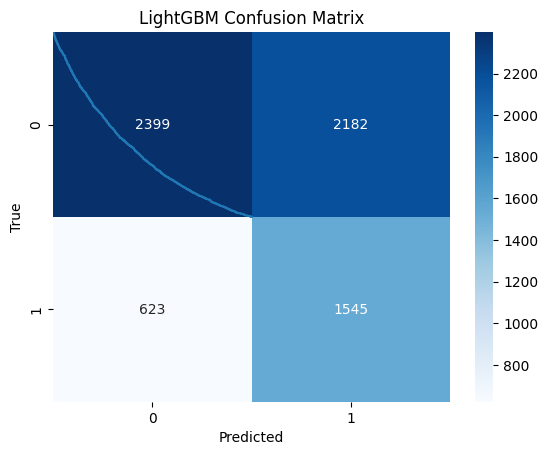

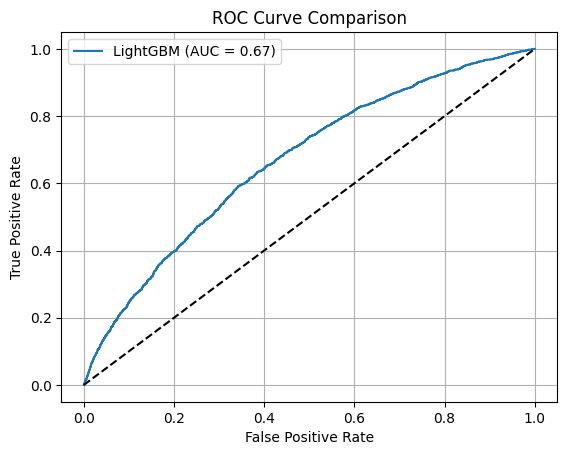

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix, roc_curve
)
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Contrastive Dataset =====
class ContrastiveDataset(Dataset):
    def __init__(self, X, y, noise_std=0.05, dropout_prob=0.2):
        self.X = torch.tensor(X.toarray() if hasattr(X, 'toarray') else X, dtype=torch.float32)
        self.y = torch.tensor(y.values if isinstance(y, pd.Series) else y, dtype=torch.long)
        self.noise_std = noise_std
        self.dropout_prob = dropout_prob

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        anchor = self.X[idx]
        label = self.y[idx]

        # Augmented positive
        positive = anchor + self.noise_std * torch.randn_like(anchor)
        positive = F.dropout(positive, p=self.dropout_prob, training=True)

        # Negative with different label
        neg_idx = torch.randint(0, len(self.X), (1,))
        while self.y[neg_idx] == label:
            neg_idx = torch.randint(0, len(self.X), (1,))
        negative = self.X[neg_idx].squeeze()
        return anchor, positive, negative, label


# ===== NT-Xent Loss =====
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, anchor, positive):
        batch_size = anchor.size(0)
        z = torch.cat([anchor, positive], dim=0)  # [2B, D]
        sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=-1)  # [2B, 2B]
        sim = sim / self.temperature

        labels = torch.arange(batch_size).to(anchor.device)
        labels = torch.cat([labels + batch_size, labels], dim=0)  # [2B]
        mask = torch.eye(2 * batch_size, dtype=torch.bool).to(anchor.device)
        sim.masked_fill_(mask, float('-inf'))  # no self-comparisons

        return F.cross_entropy(sim, labels)


class ContrastiveNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.Dropout(0.3),
            nn.Linear(64, 64)
        )

    def forward(self, x):
        out = self.encoder(x)
        return F.normalize(out, dim=-1)


# ===== Full Pipeline Function =====
def full_pipeline(df_train, df_test, target_col="label"):
    X_train_raw, y_train = df_train.drop(columns=[target_col]), df_train[target_col]
    X_test_raw, y_test = df_test.drop(columns=[target_col]), df_test[target_col]

    cat_cols = X_train_raw.select_dtypes(include='object').columns.tolist()
    num_cols = X_train_raw.select_dtypes(exclude='object').columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    X_train_processed = preprocessor.fit_transform(X_train_raw)
    X_test_processed = preprocessor.transform(X_test_raw)

    X_train_bal, y_train_bal = SMOTE().fit_resample(X_train_processed, y_train)

    train_data = ContrastiveDataset(X_train_bal, y_train_bal)
    loader = DataLoader(train_data, batch_size=256, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    encoder = ContrastiveNet(X_train_bal.shape[1]).to(device)
    optimizer = torch.optim.Adam(encoder.parameters(), lr=1e-3)
    criterion = NTXentLoss()

    encoder.train()
    for epoch in range(20):
        total_loss = 0
        for a, p, n, _ in loader:
            a, p = a.to(device), p.to(device)
            a_out = encoder(a)
            p_out = encoder(p)
            loss = criterion(a_out, p_out)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

    encoder.eval()
    with torch.no_grad():
        X_embed_bal = encoder(torch.tensor(X_train_bal.toarray() if hasattr(X_train_bal, 'toarray') else X_train_bal, dtype=torch.float32).to(device)).cpu().numpy()
        X_embed_test = encoder(torch.tensor(X_test_processed.toarray() if hasattr(X_test_processed, 'toarray') else X_test_processed, dtype=torch.float32).to(device)).cpu().numpy()

    classifiers = {
        "LogReg": LogisticRegression(max_iter=1000),
        #"RandomForest": RandomForestClassifier(n_estimators=100),
        "XGB": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "LightGBM": lgb.LGBMClassifier()
    }

    for name, clf in classifiers.items():
        clf.fit(X_embed_bal, y_train_bal)
        preds = clf.predict(X_embed_test)
        proba = clf.predict_proba(X_embed_test)[:, 1]

        print(f"\n🔍 {name} Evaluation:")
        print(classification_report(y_test, preds, digits=4))
        print("Accuracy:", accuracy_score(y_test, preds))
        print("Precision:", precision_score(y_test, preds, zero_division=0))
        print("Recall:", recall_score(y_test, preds))
        print("F1 Score:", f1_score(y_test, preds))
        print("AUC:", roc_auc_score(y_test, proba))

        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'{name} Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()

        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, proba):.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
full_pipeline(df_train, df_test)




Numeric columns: ['Age', 'familysize', 'PIR', 'BMI', 'SmokeFam']
Categorical columns: ['Gender', 'Race', 'Hba1c', 'milk_consumption']

🚀 Training and Evaluating: XGBoost


c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:54:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.79      0.79      0.79      4581
         1.0       0.55      0.56      0.55      2168

    accuracy                           0.71      6749
   macro avg       0.67      0.67      0.67      6749
weighted avg       0.71      0.71      0.71      6749



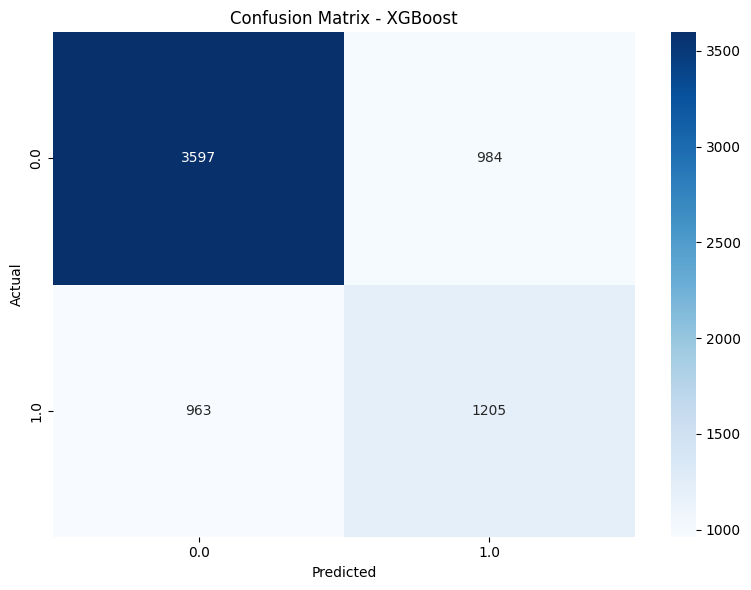

✅ Exported results to model_comparison_results.csv


In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier

# Separate features and labels
X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

# Identify categorical and numeric columns
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']  # removed 'SmokeFam'
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Define preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Define models
models_to_test = {
# 'LightGBM': LGBMClassifier(
#     n_estimators=1000,           # up to 1000 boosting rounds
#     learning_rate=0.5,          # smaller learning rate → more stable training
#     max_depth=-1,                # no limit on tree depth
#     num_leaves=31,               # controls model complexity
#     min_child_samples=20,        # minimum samples per leaf
#     subsample=0.8,               # row sampling (boosting randomly)
#     colsample_bytree=0.8,        # feature sampling
#     reg_alpha=1.0,               # L1 regularization (can help generalize)
#     reg_lambda=1.0,              # L2 regularization
#     class_weight='balanced',     # handle imbalanced classes automatically
#     objective='binary',          # binary classification task
#     random_state=42,             # for reproducibility
#     n_jobs=-1                    # use all cores
# ),
    'XGBoost': XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.05, max_depth=7,
        n_estimators=100, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
    # 'ElasticNetLogistic': LogisticRegression(
    #     penalty='elasticnet', solver='saga', max_iter=1000,
    #     random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    # ),
    # 'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
#     'AdaBoost': AdaBoostClassifier(
#     estimator=DecisionTreeClassifier(
#         max_depth=2,               # Weak learner depth (shallow trees)
#         min_samples_split=10,      # Minimum samples to split a node
#         min_samples_leaf=5         # Minimum samples in a leaf
#     ),
#     n_estimators=200,             # More rounds improves accuracy
#     learning_rate=0.5,            # Adjusts weight of each weak learner
#     algorithm='SAMME.R',          # Default: uses probabilities (better for performance)
#     random_state=42
# ),

}


from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")
    
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTETomek(random_state=42, sampling_strategy='minority')),
        ('classifier', model)
    ])
    
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)
    
    # Predict proba for AUC
    y_proba = pipe.predict_proba(X_test_raw)

    # Handle binary and multiclass AUC
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # Collect scores
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Save result
    results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })

    # Optional: show classification report and confusion matrix
    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results_baseline.csv", index=False)
print("✅ Exported results to model_comparison_results.csv")

Numeric columns: ['Age', 'familysize', 'PIR', 'BMI', 'SmokeFam']
Categorical columns: ['Gender', 'Race', 'Hba1c', 'milk_consumption']

🚀 Training and Evaluating: XGBoost
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.68      1.00      0.81      4581
         1.0       0.00      0.00      0.00      2168

    accuracy                           0.68      6749
   macro avg       0.34      0.50      0.40      6749
weighted avg       0.46      0.68      0.55      6749



c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:35:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetric

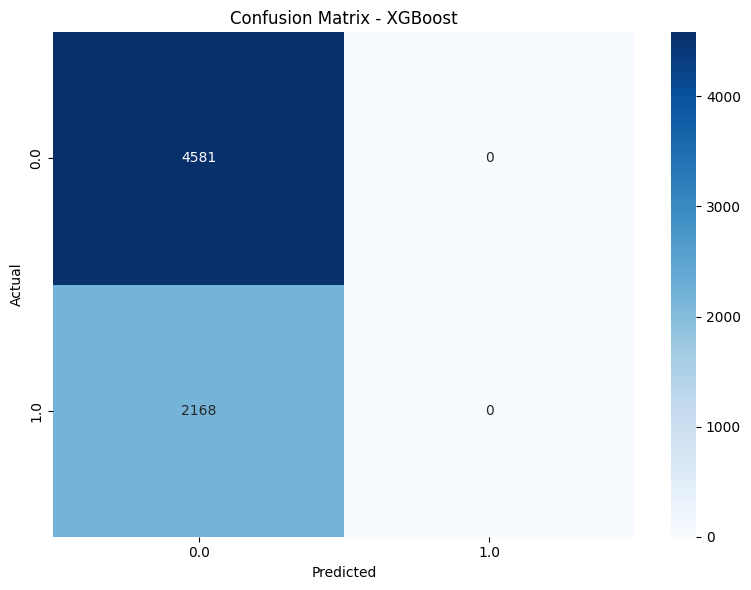


🚀 Training and Evaluating: LightGBM
[LightGBM] [Info] Number of positive: 9118, number of negative: 27290
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 735
[LightGBM] [Info] Number of data points in the train set: 36408, number of used features: 75
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.48      0.62      4581
         1.0       0.43      0.83      0.57      2168

    accuracy                           0.59      6749
   macro avg       0.64      0.65      0.59      6749
weighted avg       0.72      0.59      0.60      6749



c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


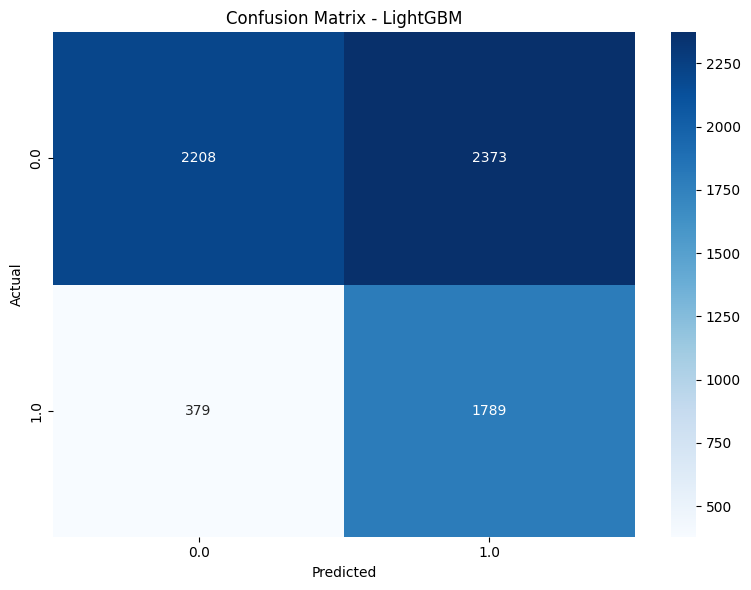

✅ Exported results to model_comparison_results.csv


In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# Separate features and labels
X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

# Identify categorical and numeric columns
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']  # removed 'SmokeFam'
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Define preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Define models
models_to_test = {
    'XGBoost': XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.01, max_depth=7,
        n_estimators=50, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
    # 'ElasticNetLogistic': LogisticRegression(
    #     penalty='elasticnet', solver='saga', max_iter=1000,
    #     random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    # ),
    # 'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    # 'AdaBoost': AdaBoostClassifier(
    # estimator=DecisionTreeClassifier(
    #     max_depth=2,               # Weak learner depth (shallow trees)
    #     min_samples_split=10,      # Minimum samples to split a node
    #     min_samples_leaf=5         # Minimum samples in a leaf
    # ),
    # n_estimators=200,             # More rounds improves accuracy
    # learning_rate=0.5,            # Adjusts weight of each weak learner
    # algorithm='SAMME.R',          # Default: uses probabilities (better for performance)
    # random_state=42
    # ),
    'LightGBM': LGBMClassifier(
    n_estimators=1000,           # up to 1000 boosting rounds
    learning_rate=0.01,          # smaller learning rate → more stable training
    max_depth=-1,                # no limit on tree depth
    num_leaves=31,               # controls model complexity
    min_child_samples=20,        # minimum samples per leaf
    subsample=0.8,               # row sampling (boosting randomly)
    colsample_bytree=0.8,        # feature sampling
    reg_alpha=1.0,               # L1 regularization (can help generalize)
    reg_lambda=1.0,              # L2 regularization
    class_weight='balanced',     # handle imbalanced classes automatically
    objective='binary',          # binary classification task
    random_state=42,             # for reproducibility
    n_jobs=-1                    # use all cores
),
}


from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")
    
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        #('smote', SMOTETomek(random_state=42, sampling_strategy='minority')),
        ('classifier', model)
    ])
    
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)
    
    # Predict proba for AUC
    y_proba = pipe.predict_proba(X_test_raw)

    # Handle binary and multiclass AUC
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # Collect scores
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Save result
    results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })

    # Optional: show classification report and confusion matrix
    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results_baseline.csv", index=False)
print("✅ Exported results to model_comparison_results.csv")

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier

# === Step 1: Load CSVs ===
df_train = pd.read_csv("your_train_file.csv")
df_test = pd.read_csv("your_test_file.csv")

X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

# === Step 2: Define preprocessing ===
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# === Step 3: Define Balanced Random Forest ===
brf_model = BalancedRandomForestClassifier(
    n_estimators=100,
    sampling_strategy='auto',
    random_state=42,
    n_jobs=-1
)

# === Step 4: Create pipeline ===
brf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', brf_model)
])

# === Step 5: Fit model ===
brf_pipeline.fit(X_train_raw, y_train)
y_pred = brf_pipeline.predict(X_test_raw)
y_proba = brf_pipeline.predict_proba(X_test_raw)

# === Step 6: Evaluate ===
if len(np.unique(y_test)) == 2:
    auc = roc_auc_score(y_test, y_proba[:, 1])
else:
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
accuracy = accuracy_score(y_test, y_pred)

# === Step 7: Show results ===
print("🔍 Classification Report for BalancedRandomForest:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix - BalancedRandomForest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\n📊 Metrics Summary:")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro):    {recall:.4f}")
print(f"F1 Score (Macro):  {f1:.4f}")
print(f"Accuracy:          {accuracy:.4f}")
print(f"AUC:               {auc:.4f}")


FileNotFoundError: [Errno 2] No such file or directory: 'your_train_file.csv'

Numeric columns: ['Age', 'familysize', 'PIR', 'BMI', 'SmokeFam']
Categorical columns: ['Gender', 'Race', 'Hba1c', 'milk_consumption']

🚀 Training and Evaluating: XGBoost


c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:10:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.84      0.79      4581
         1.0       0.55      0.42      0.48      2168

    accuracy                           0.70      6749
   macro avg       0.65      0.63      0.63      6749
weighted avg       0.69      0.70      0.69      6749



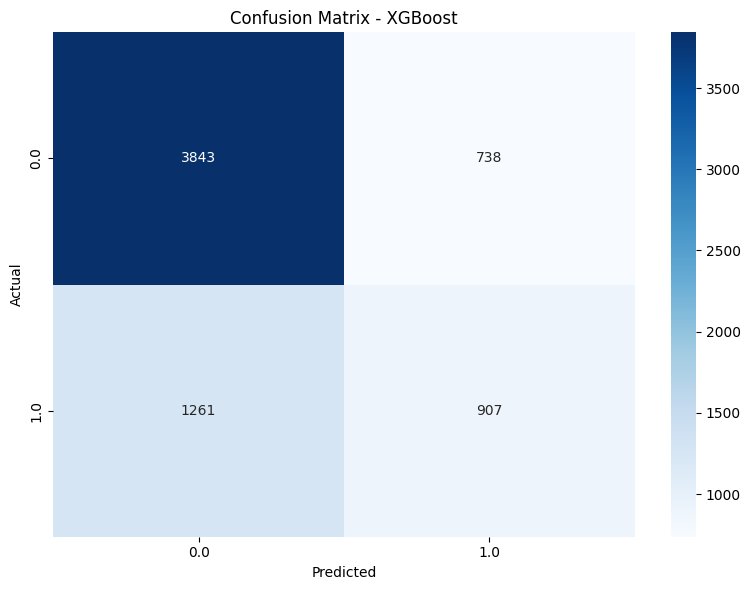


🚀 Training and Evaluating: AdaBoost


KeyboardInterrupt: 

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# Separate features and labels
X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

# Identify categorical and numeric columns
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']  # removed 'SmokeFam'
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Define preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Define models
models_to_test = {
    'XGBoost': XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
        n_estimators=50, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
    # 'ElasticNetLogistic': LogisticRegression(
    #     penalty='elasticnet', solver='saga', max_iter=1000,
    #     random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    # ),
    # 'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
}


from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")
    
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTETomek(random_state=42, sampling_strategy='minority')),
        ('classifier', model)
    ])
    
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)
    
    # Predict proba for AUC
    y_proba = pipe.predict_proba(X_test_raw)

    # Handle binary and multiclass AUC
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # Collect scores
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Save result
    results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })

    # Optional: show classification report and confusion matrix
    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results_baseline.csv", index=False)
print("✅ Exported results to model_comparison_results.csv")

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, roc_auc_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Separate features and labels
X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

# Identify categorical and numeric columns
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']  # removed 'SmokeFam'
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Define preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Define base models
models_to_test = {
    'xgb': XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
        n_estimators=50, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
    'logreg': LogisticRegression(
        penalty='elasticnet', solver='saga', max_iter=1000,
        random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    ),
    'lgbm': LGBMClassifier(random_state=42),
}

# Create a VotingClassifier with soft voting
voting_clf = VotingClassifier(
    estimators=[(name, model) for name, model in models_to_test.items()],
    voting='hard',
    n_jobs=-1
)

# Build pipeline with preprocessing, SMOTETomek, and voting ensemble
pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smotetomek', SMOTETomek(random_state=42, sampling_strategy='minority')),
    ('voting_classifier', voting_clf)
])

# Train
pipe.fit(X_train_raw, y_train)

# Predict and evaluate
y_pred = pipe.predict(X_test_raw)
y_proba = pipe.predict_proba(X_test_raw)

# AUC handling (binary or multi-class)
if len(np.unique(y_test)) == 2:
    auc = roc_auc_score(y_test, y_proba[:, 1])
else:
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
accuracy = accuracy_score(y_test, y_pred)

print("✅ Voting Classifier Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")
print(f"AUC: {auc:.4f}")

print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix - Voting Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


NameError: name 'df_train' is not defined

Numeric columns: ['Age', 'familysize', 'PIR', 'BMI', 'SmokeFam']
Categorical columns: ['Gender', 'Race', 'Hba1c', 'milk_consumption']
✅ Voting Classifier Performance:
Accuracy: 0.6908
Precision (Macro): 0.6624
Recall (Macro): 0.6793
F1 Score (Macro): 0.6655
AUC: 0.7373

🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.71      0.76      4581
         1.0       0.51      0.65      0.57      2168

    accuracy                           0.69      6749
   macro avg       0.66      0.68      0.67      6749
weighted avg       0.72      0.69      0.70      6749



c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


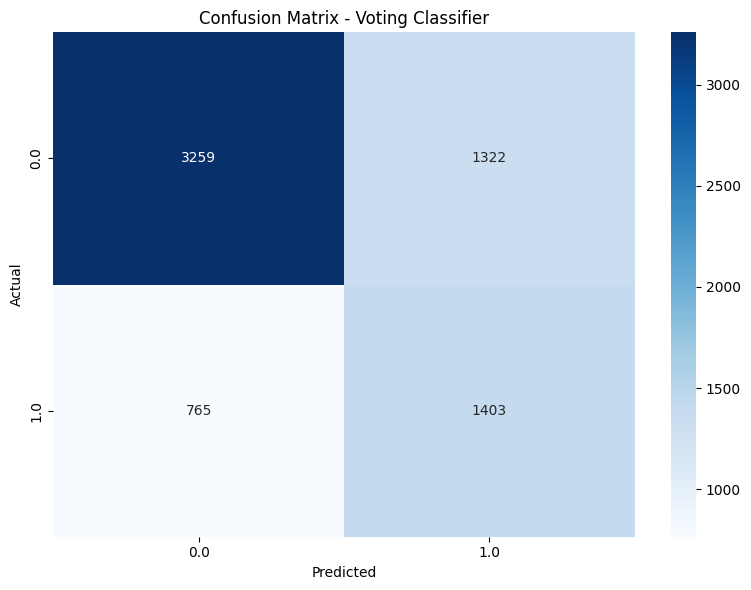

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, roc_auc_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Separate features and labels
X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

# Identify categorical and numeric columns
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']  # removed 'SmokeFam'
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Define preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Define base models
# models_to_test = {
#     'xgb': XGBClassifier(
#         colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
#         n_estimators=50, subsample=1.0, use_label_encoder=False,
#         eval_metric='mlogloss', random_state=42
#     ),
#     'logreg': LogisticRegression(
#         penalty='elasticnet', solver='saga', max_iter=1000,
#         random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
#     ),
#     'lgbm': LGBMClassifier(random_state=42),
# }
# Define models
models_to_test = {
'LightGBM': LGBMClassifier(
    n_estimators=1000,           # up to 1000 boosting rounds
    learning_rate=0.01,          # smaller learning rate → more stable training
    max_depth=-1,                # no limit on tree depth
    num_leaves=31,               # controls model complexity
    min_child_samples=20,        # minimum samples per leaf
    subsample=0.8,               # row sampling (boosting randomly)
    colsample_bytree=0.8,        # feature sampling
    reg_alpha=1.0,               # L1 regularization (can help generalize)
    reg_lambda=1.0,              # L2 regularization
    class_weight='balanced',     # handle imbalanced classes automatically
    objective='binary',          # binary classification task
    random_state=42,             # for reproducibility
    n_jobs=-1                    # use all cores
),
    'XGBoost': XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
        n_estimators=50, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
    # 'ElasticNetLogistic': LogisticRegression(
    #     penalty='elasticnet', solver='saga', max_iter=1000,
    #     random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    # ),
    # 'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'ElasticNetLogistic': LogisticRegression(
        penalty='elasticnet', solver='saga', max_iter=1000,
        random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    ),

}

# Create a VotingClassifier with soft voting
voting_clf = VotingClassifier(
    estimators=[(name, model) for name, model in models_to_test.items()],
    voting='soft',
    n_jobs=-1
)

# Build pipeline with preprocessing, SMOTETomek, and voting ensemble
pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smotetomek', SMOTETomek(random_state=42, sampling_strategy='minority')),
    ('voting_classifier', voting_clf)
])

# Train
pipe.fit(X_train_raw, y_train)

# Predict and evaluate
y_pred = pipe.predict(X_test_raw)
y_proba = pipe.predict_proba(X_test_raw)

# AUC handling (binary or multi-class)
if len(np.unique(y_test)) == 2:
    auc = roc_auc_score(y_test, y_proba[:, 1])
else:
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
accuracy = accuracy_score(y_test, y_pred)

print("✅ Voting Classifier Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")
print(f"AUC: {auc:.4f}")

print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix - Voting Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_52728\367642440.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in df_train.groupby('age_group'):


🔄 Processing age group: 0-20, samples: 9512
🔄 Processing age group: 21-40, samples: 9792
🔄 Processing age group: 41-60, samples: 8812
🔄 Processing age group: 61+, samples: 8292

🚀 Training and Evaluating: XGBoost


c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:28:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.77      0.78      4581
         1.0       0.53      0.53      0.53      2168

    accuracy                           0.70      6749
   macro avg       0.65      0.65      0.65      6749
weighted avg       0.70      0.70      0.70      6749



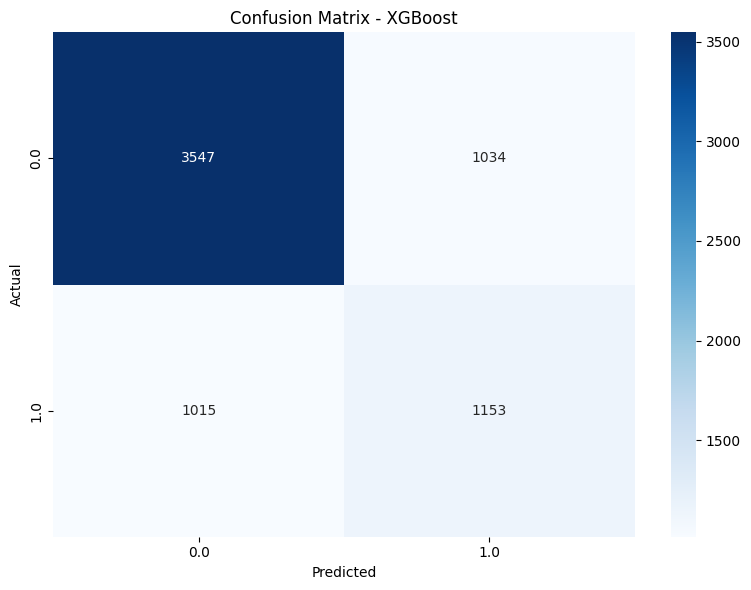


🚀 Training and Evaluating: ElasticNetLogistic


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.47      0.60      4581
         1.0       0.42      0.82      0.56      2168

    accuracy                           0.58      6749
   macro avg       0.63      0.64      0.58      6749
weighted avg       0.71      0.58      0.59      6749



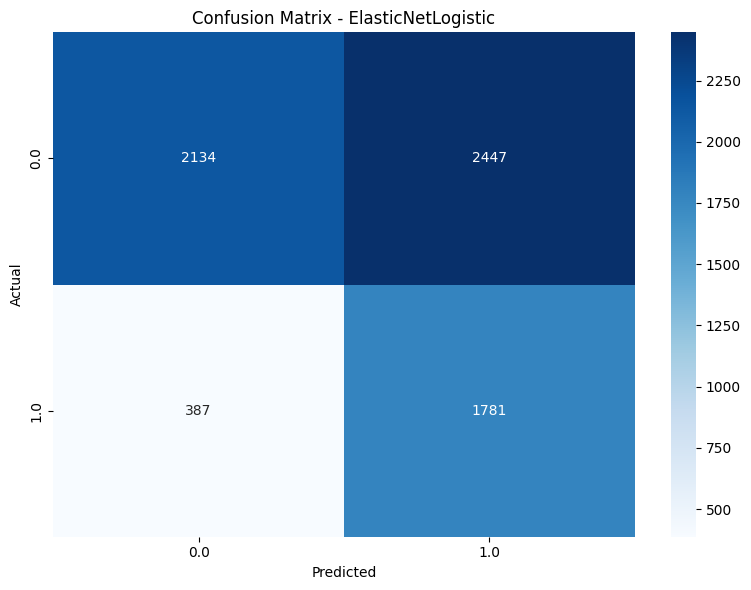


🚀 Training and Evaluating: RandomForest
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.85      0.80      4581
         1.0       0.56      0.39      0.46      2168

    accuracy                           0.71      6749
   macro avg       0.65      0.62      0.63      6749
weighted avg       0.69      0.71      0.69      6749



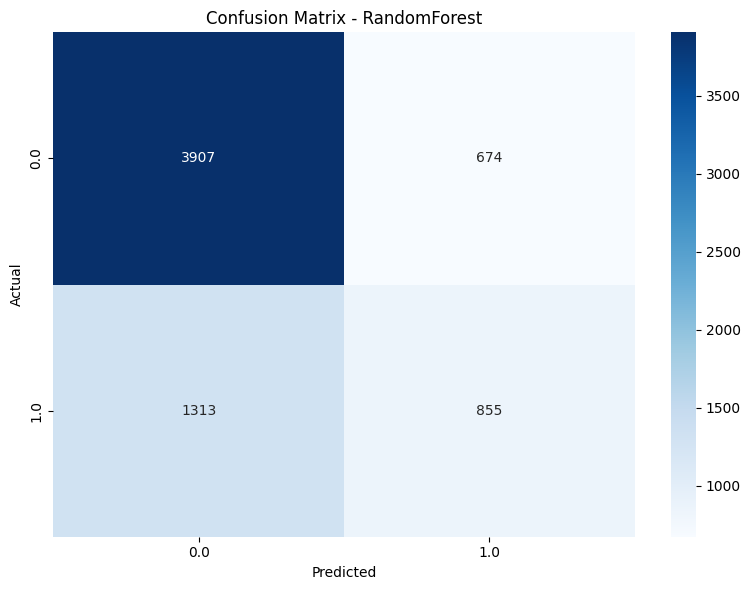


🚀 Training and Evaluating: AdaBoost
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.62      0.71      4581
         1.0       0.47      0.71      0.57      2168

    accuracy                           0.65      6749
   macro avg       0.65      0.67      0.64      6749
weighted avg       0.71      0.65      0.66      6749



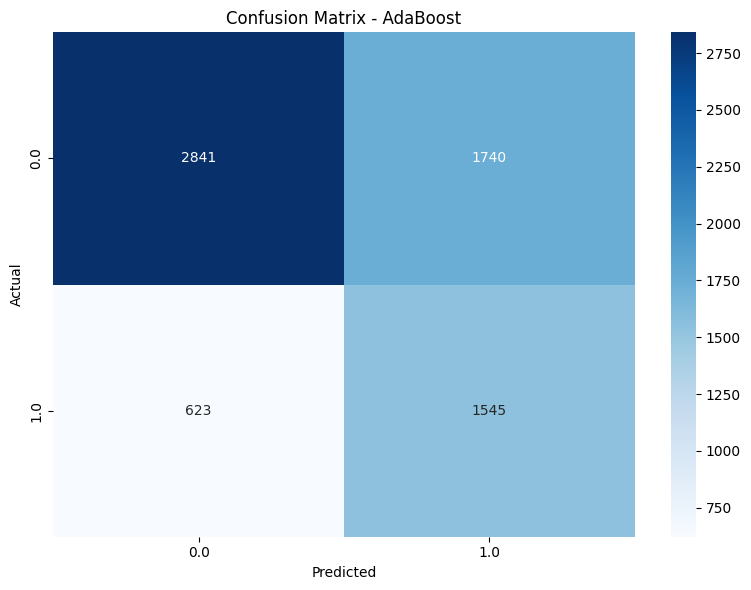


🚀 Training and Evaluating: LightGBM
[LightGBM] [Info] Number of positive: 27290, number of negative: 27290
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10213
[LightGBM] [Info] Number of data points in the train set: 54580, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.88      0.81      4581
         1.0       0.60      0.39      0.47      2168

    accuracy                           0.72      6749
   macro avg       0.67      0.63      0.64      6749
weighted avg       0.70      0.72      0.70      6749



c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


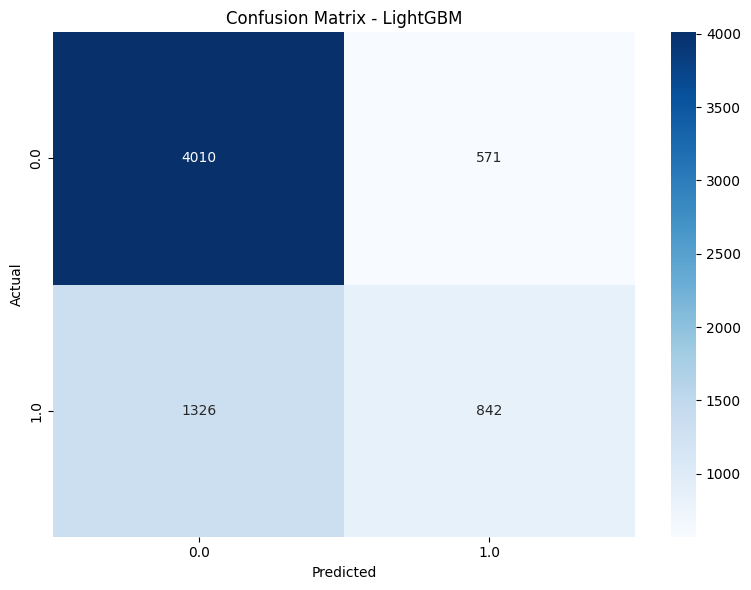

✅ Exported results to model_comparison_results_agegroup_smote.csv


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, roc_auc_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from scipy.sparse import vstack

# -------------------------
# 🔹 STEP 1: Setup
# -------------------------

# Create age groups first
df_train['age_group'] = pd.cut(df_train['Age'], bins=[0, 20, 40, 60, 100], labels=['0-20', '21-40', '41-60', '61+'])

# Define columns
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label', 'age_group']]

# Drop label and age_group to create clean raw feature set
X_train_raw = df_train.drop(columns=['label', 'age_group'])

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Fit preprocessor ONCE on the full feature columns
preprocessor.fit(X_train_raw)

# -------------------------
# 🔹 STEP 2: SMOTE by Age Group
# -------------------------
X_smoted_list = []
y_smoted_list = []

for group, group_df in df_train.groupby('age_group'):
    print(f"🔄 Processing age group: {group}, samples: {len(group_df)}")

    X_group = group_df.drop(columns=['label', 'age_group'])
    y_group = group_df['label'].astype(int)

    # Use fitted preprocessor for transformation
    X_group_processed = preprocessor.transform(X_group)

    try:
        smote = SMOTE(random_state=42, sampling_strategy='minority')
        X_res, y_res = smote.fit_resample(X_group_processed, y_group)
        X_smoted_list.append(X_res)
        y_smoted_list.append(y_res)
    except ValueError as e:
        print(f"⚠️ Skipping group {group} due to SMOTE error: {e}")

# Combine SMOTEd groups
X_train = np.vstack(X_smoted_list)
y_train = np.concatenate(y_smoted_list)

# -------------------------
# 🔹 STEP 3: Preprocess Test Set
# -------------------------
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']
X_test = preprocessor.transform(X_test_raw)

# -------------------------
# 🔹 STEP 4: Model Definitions
# -------------------------
models_to_test = {
    'XGBoost': XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
        n_estimators=50, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
    'ElasticNetLogistic': LogisticRegression(
        penalty='elasticnet', solver='saga', max_iter=1000,
        random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    ),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
}

# -------------------------
# 🔹 STEP 5: Model Training and Evaluation
# -------------------------
results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # AUC logic
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # Metrics
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })

    # Report and confusion matrix
    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# -------------------------
# 🔹 STEP 6: Export Results
# -------------------------
results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results_agegroup_smote.csv", index=False)
print("✅ Exported results to model_comparison_results_agegroup_smote.csv")


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_52728\3664670155.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in df_train.groupby('age_group'):


🔄 Processing age group: 0-20, samples: 9512
🔄 Processing age group: 21-40, samples: 9792
🔄 Processing age group: 41-60, samples: 8812
🔄 Processing age group: 61+, samples: 8292

🚀 Training and Evaluating: XGBoost


c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:37:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.77      0.78      4581
         1.0       0.53      0.55      0.54      2168

    accuracy                           0.70      6749
   macro avg       0.66      0.66      0.66      6749
weighted avg       0.70      0.70      0.70      6749



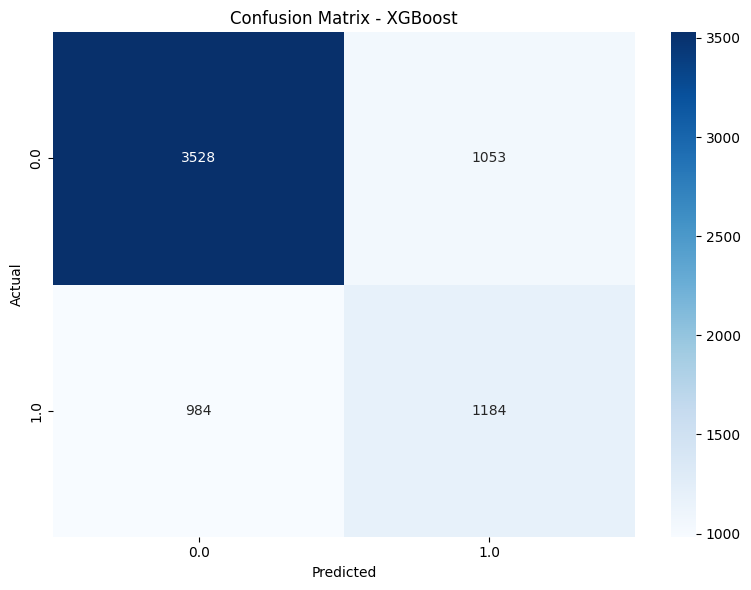


🚀 Training and Evaluating: ElasticNetLogistic


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.47      0.60      4581
         1.0       0.42      0.82      0.56      2168

    accuracy                           0.58      6749
   macro avg       0.63      0.64      0.58      6749
weighted avg       0.71      0.58      0.59      6749



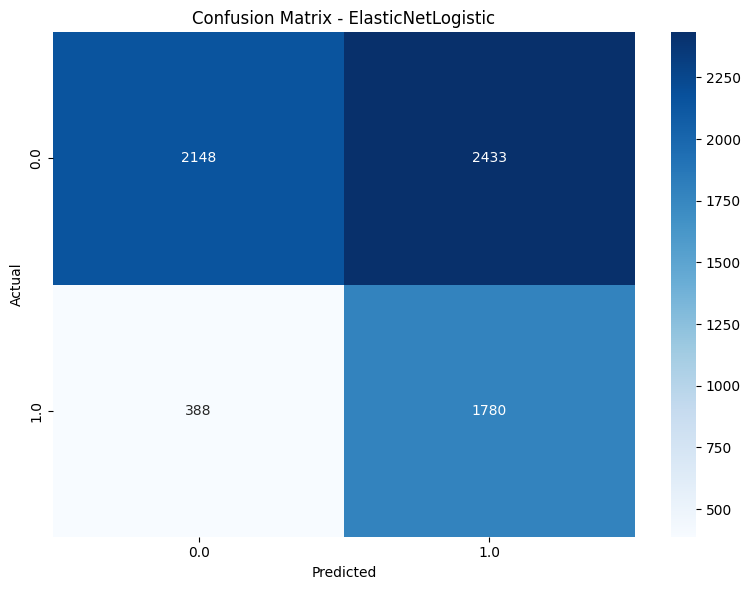


🚀 Training and Evaluating: RandomForest
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.85      0.79      4581
         1.0       0.55      0.39      0.46      2168

    accuracy                           0.70      6749
   macro avg       0.65      0.62      0.63      6749
weighted avg       0.68      0.70      0.69      6749



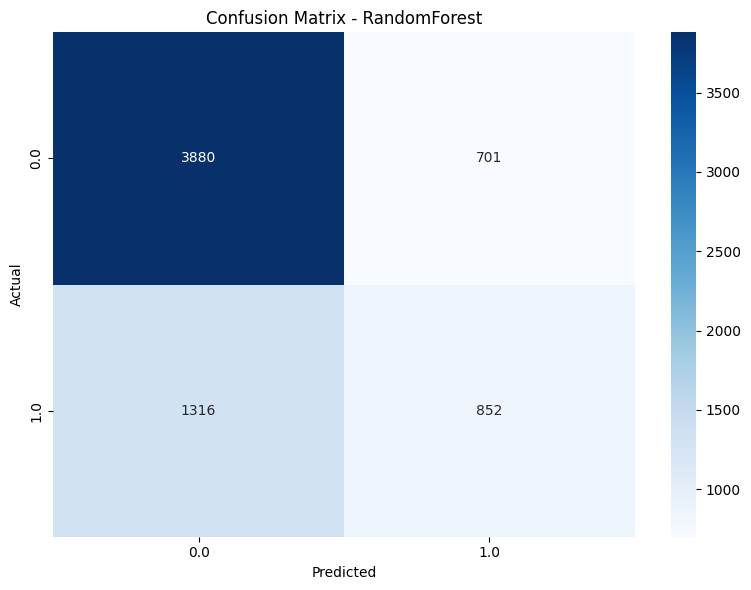


🚀 Training and Evaluating: AdaBoost
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.64      0.72      4581
         1.0       0.48      0.70      0.57      2168

    accuracy                           0.66      6749
   macro avg       0.65      0.67      0.64      6749
weighted avg       0.71      0.66      0.67      6749



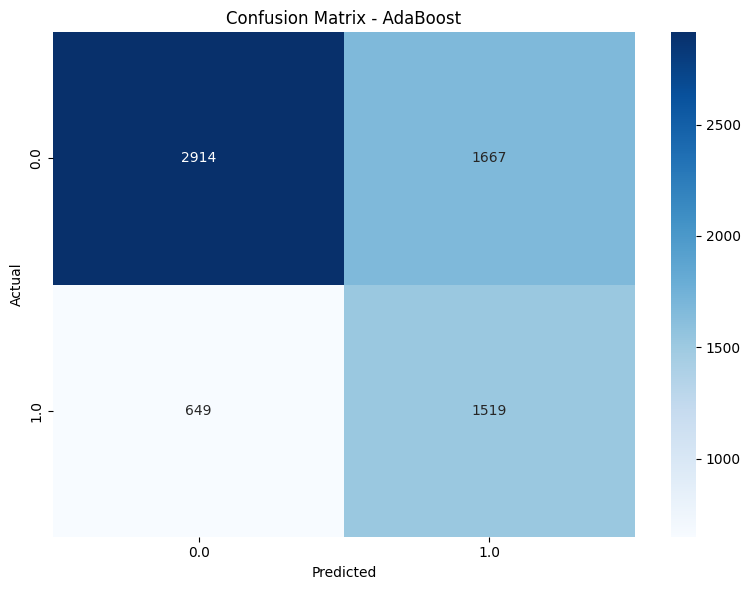


🚀 Training and Evaluating: LightGBM
[LightGBM] [Info] Number of positive: 26513, number of negative: 26513
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10133
[LightGBM] [Info] Number of data points in the train set: 53026, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.87      0.81      4581
         1.0       0.59      0.41      0.49      2168

    accuracy                           0.72      6749
   macro avg       0.68      0.64      0.65      6749
weighted avg       0.70      0.72      0.71      6749



c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


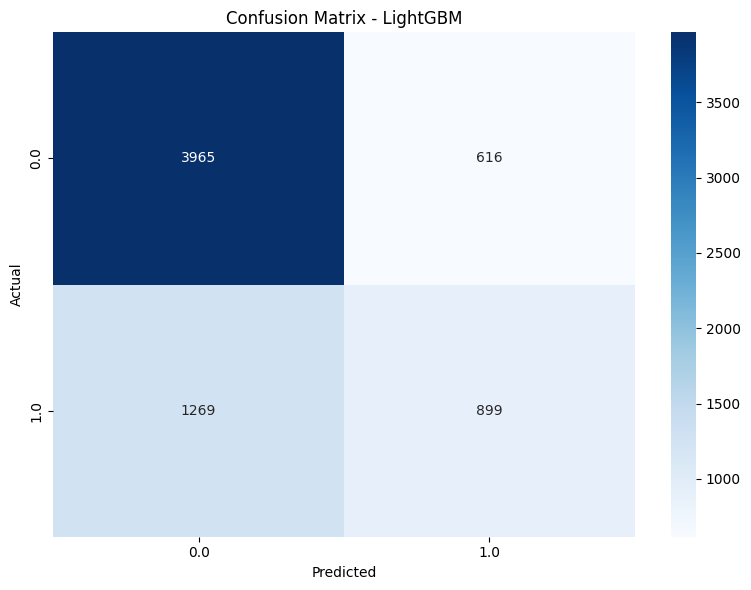

✅ Exported results to model_comparison_results_agegroup_smote.csv


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, roc_auc_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from scipy.sparse import vstack

# -------------------------
# 🔹 STEP 1: Setup
# -------------------------

# Create age groups first
df_train['age_group'] = pd.cut(df_train['Age'], bins=[0, 20, 40, 60, 100], labels=['0-20', '21-40', '41-60', '61+'])

# Define columns
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label', 'age_group']]

# Drop label and age_group to create clean raw feature set
X_train_raw = df_train.drop(columns=['label', 'age_group'])

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Fit preprocessor ONCE on the full feature columns
preprocessor.fit(X_train_raw)

# -------------------------
# 🔹 STEP 2: SMOTE by Age Group
# -------------------------
# -------------------------
# 🔹 STEP 2: SMOTETomek by Age Group
# -------------------------
X_smoted_list = []
y_smoted_list = []

for group, group_df in df_train.groupby('age_group'):
    print(f"🔄 Processing age group: {group}, samples: {len(group_df)}")

    X_group = group_df.drop(columns=['label', 'age_group'])
    y_group = group_df['label'].astype(int)

    # Use fitted preprocessor for transformation
    X_group_processed = preprocessor.transform(X_group)

    try:
        smote_tomek = SMOTETomek(random_state=42, sampling_strategy='minority')
        X_res, y_res = smote_tomek.fit_resample(X_group_processed, y_group)
        X_smoted_list.append(X_res)
        y_smoted_list.append(y_res)
    except ValueError as e:
        print(f"⚠️ Skipping group {group} due to SMOTETomek error: {e}")

# Combine resampled groups
X_train = np.vstack(X_smoted_list)
y_train = np.concatenate(y_smoted_list)

# -------------------------
# 🔹 STEP 3: Preprocess Test Set
# -------------------------
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']
X_test = preprocessor.transform(X_test_raw)

# -------------------------
# 🔹 STEP 4: Model Definitions
# -------------------------
models_to_test = {
    'XGBoost': XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
        n_estimators=50, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
    'ElasticNetLogistic': LogisticRegression(
        penalty='elasticnet', solver='saga', max_iter=1000,
        random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    ),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
}

# -------------------------
# 🔹 STEP 5: Model Training and Evaluation
# -------------------------
results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # AUC logic
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # Metrics
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })

    # Report and confusion matrix
    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# -------------------------
# 🔹 STEP 6: Export Results
# -------------------------
results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results_agegroup_smote.csv", index=False)
print("✅ Exported results to model_comparison_results_agegroup_smote.csv")


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

from sklearn.pipeline import Pipeline

# ⚠️ Assume df_train and df_test are already loaded

# === Prepare Data ===
X_train_raw = df_train.drop(columns=['label'])
y_train_raw = df_train['label']

X_test_raw = df_test.drop(columns=['label'])
y_test_raw = df_test['label']

# Set categorical and numerical columns
categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

# OneHot + Scale
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

# === Build Neural Network Model ===
def build_model(input_dim, output_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# === Full Pipeline ===
# Step 1: Preprocess
X_train_transformed = preprocessor.fit_transform(X_train_raw)
X_test_transformed = preprocessor.transform(X_test_raw)

# Step 2: Handle imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_transformed, y_train_raw)

# Step 3: Convert labels
num_classes = len(np.unique(y_train_raw))
y_train_encoded = to_categorical(y_train_res, num_classes=num_classes)
y_test_encoded = to_categorical(y_test_raw, num_classes=num_classes)

# Step 4: Train model
model = build_model(input_dim=X_train_res.shape[1], output_dim=num_classes)
history = model.fit(X_train_res, y_train_encoded, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Step 5: Evaluate
y_pred_proba = model.predict(X_test_transformed)
y_pred = np.argmax(y_pred_proba, axis=1)

# Step 6: Metrics
print("Classification Report:")
print(classification_report(y_test_raw, y_pred))

cm = confusion_matrix(y_test_raw, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test_raw), yticklabels=np.unique(y_test_raw))
plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# AUC (multi-class)
auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr', average='macro')
print(f"Macro AUC: {auc:.4f}")


ModuleNotFoundError: No module named 'tensorflow'

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, ReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# === Prepare Data ===
X_train_raw = df_train.drop(columns=['label'])
y_train_raw = df_train['label']

X_test_raw = df_test.drop(columns=['label'])
y_test_raw = df_test['label']

categorical_cols = ['Gender', 'Race', 'Hba1c', 'milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

# === Preprocess
X_train_transformed = preprocessor.fit_transform(X_train_raw)
X_test_transformed = preprocessor.transform(X_test_raw)

# === Resample
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_transformed, y_train_raw)

# === Encode Labels
num_classes = len(np.unique(y_train_res))
y_train_encoded = to_categorical(y_train_res, num_classes=num_classes)
y_test_encoded = to_categorical(y_test_raw, num_classes=num_classes)

# === Build Improved Model ===
def build_improved_model(input_dim, output_dim):
    model = Sequential([
        Dense(128, input_shape=(input_dim,)),
        BatchNormalization(),
        ReLU(max_value=6),
        Dropout(0.4),
        
        Dense(64),
        BatchNormalization(),
        ReLU(max_value=6),
        Dropout(0.3),
        
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_improved_model(input_dim=X_train_res.shape[1], output_dim=num_classes)

# === Train with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_res, y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# === Evaluate
y_pred_proba = model.predict(X_test_transformed)
y_pred = np.argmax(y_pred_proba, axis=1)

print("Classification Report:")
print(classification_report(y_test_raw, y_pred))

cm = confusion_matrix(y_test_raw, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=np.unique(y_test_raw), yticklabels=np.unique(y_test_raw))
plt.title("Confusion Matrix - Improved Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr', average='macro')
print(f"Macro AUC: {auc:.4f}")


ModuleNotFoundError: No module named 'tensorflow'

In [86]:
df_test = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatest.csv")
df_train = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatrain.csv")

In [89]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14886 entries, 0 to 14885
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    14886 non-null  float64
 1   Age                       14886 non-null  float64
 2   Race                      14886 non-null  float64
 3   familysize                14886 non-null  float64
 4   PIR                       14886 non-null  float64
 5   BMI                       14886 non-null  float64
 6   WaistCircumference        14886 non-null  float64
 7   FastingGlucose            14886 non-null  float64
 8   ALT                       14886 non-null  float64
 9   AST                       14886 non-null  float64
 10  AlkalinePhosphotase       14886 non-null  float64
 11  Triglycerides             14886 non-null  float64
 12  UricAcid                  14886 non-null  float64
 13  Creatinine                14886 non-null  float64
 14  HDLCho

In [90]:
df_train.columns

Index(['Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMI',
       'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
       'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', 'SmokeFam', 'milk_consumption',
       'label'],
      dtype='object')

In [98]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.experimental import enable_iterative_imputer  # Must import this first
from sklearn.impute import KNNImputer, IterativeImputer
import warnings
warnings.filterwarnings('ignore')

class VitaminDFeatureEngineer:
    """
    Advanced feature engineering specifically for Vitamin D classification
    Based on medical domain knowledge and biomarker interactions
    """
    
    def __init__(self):
        self.scalers = {}
        self.pca_components = {}
        self.cluster_models = {}
        self.reference_ranges = self._define_reference_ranges()
        
    def _define_reference_ranges(self):
        """Define normal reference ranges for biomarkers"""
        return {
            'BMI': {'underweight': 18.5, 'normal': 25, 'overweight': 30},
            'FastingGlucose': {'normal': 100, 'prediabetic': 125},
            'HDLCholesterol': {'low_male': 40, 'low_female': 50, 'optimal': 60},
            'LDLCholesterol': {'optimal': 100, 'near_optimal': 130, 'high': 160},
            'Triglycerides': {'normal': 150, 'borderline': 200, 'high': 500},
            'UricAcid': {'normal_male': 7.0, 'normal_female': 6.0},
            'Creatinine': {'normal_male': 1.2, 'normal_female': 1.0},
            'Hemoglobin': {'low_male': 13.8, 'low_female': 12.1},
            'Hematocrit': {'low_male': 41, 'low_female': 36}
        }
    
    def create_metabolic_features(self, df):
        """Create metabolic syndrome and diabetes risk features"""
        features = df.copy()
        
        print("Creating metabolic features...")
        
        # 1. Metabolic Syndrome Score (0-5 criteria)
        metabolic_score = 0
        
        # Waist circumference (>102 men, >88 women)
        waist_risk = ((features['Gender'] == 1) & (features['WaistCircumference'] > 102)) | \
                    ((features['Gender'] == 2) & (features['WaistCircumference'] > 88))
        metabolic_score += waist_risk.astype(int)
        
        # High triglycerides (≥150)
        metabolic_score += (features['Triglycerides'] >= 150).astype(int)
        
        # Low HDL (<40 men, <50 women)
        hdl_low = ((features['Gender'] == 1) & (features['HDLCholesterol'] < 40)) | \
                 ((features['Gender'] == 2) & (features['HDLCholesterol'] < 50))
        metabolic_score += hdl_low.astype(int)
        
        # High fasting glucose (≥100)
        metabolic_score += (features['FastingGlucose'] >= 100).astype(int)
        
        # BMI obesity (≥30)
        metabolic_score += (features['BMI'] >= 30).astype(int)
        
        features['metabolic_syndrome_score'] = metabolic_score
        features['has_metabolic_syndrome'] = (metabolic_score >= 3).astype(int)
        
        # 2. Insulin Resistance Proxy (TyG Index)
        features['tyg_index'] = np.log(features['Triglycerides'] * features['FastingGlucose'] / 2)
        
        # 3. Cardiovascular Risk Ratios
        features['total_hdl_ratio'] = (features['HDLCholesterol'] + features['LDLCholesterol']) / features['HDLCholesterol']
        features['ldl_hdl_ratio'] = features['LDLCholesterol'] / features['HDLCholesterol']
        features['trig_hdl_ratio'] = features['Triglycerides'] / features['HDLCholesterol']
        
        # 4. Atherogenic Index
        features['atherogenic_index'] = np.log10(features['Triglycerides'] / features['HDLCholesterol'])
        
        return features
    
    def create_liver_kidney_features(self, df):
        """Create liver and kidney function composite features"""
        features = df.copy()
        
        print("Creating liver and kidney function features...")
        
        # 1. Liver Function Score
        # AST/ALT ratio (>2 suggests alcoholic liver disease, >1 suggests liver damage)
        features['ast_alt_ratio'] = features['AST'] / (features['ALT'] + 1e-6)
        features['liver_damage_risk'] = (features['ast_alt_ratio'] > 1).astype(int)
        
        # Liver enzyme elevation score
        alt_elevated = (features['ALT'] > 40).astype(int)  # Normal <40 U/L
        ast_elevated = (features['AST'] > 40).astype(int)  # Normal <40 U/L
        alp_elevated = (features['AlkalinePhosphotase'] > 120).astype(int)  # Normal <120 U/L
        features['liver_enzyme_score'] = alt_elevated + ast_elevated + alp_elevated
        
        # 2. Kidney Function Features
        # eGFR estimation (simplified MDRD formula)
        features['egfr_estimate'] = 175 * (features['Creatinine'] ** -1.154) * (features['Age'] ** -0.203)
        features.loc[features['Gender'] == 2, 'egfr_estimate'] *= 0.742  # Female adjustment
        
        # Chronic kidney disease stages
        features['ckd_stage'] = pd.cut(features['egfr_estimate'], 
                                     bins=[0, 15, 30, 45, 60, 90, float('inf')], 
                                     labels=[5, 4, 3, 2, 1, 0])
        features['ckd_stage'] = features['ckd_stage'].astype(int)
        
        # Uric acid to creatinine ratio
        features['uric_creatinine_ratio'] = features['UricAcid'] / features['Creatinine']
        
        return features
    
    def create_hematological_features(self, df):
        """Create blood-related composite features"""
        features = df.copy()
        
        print("Creating hematological features...")
        
        # 1. Anemia Detection
        anemia_male = (features['Gender'] == 1) & (features['Hemoglobin'] < 13.8)
        anemia_female = (features['Gender'] == 2) & (features['Hemoglobin'] < 12.1)
        features['has_anemia'] = (anemia_male | anemia_female).astype(int)
        
        # 2. Iron Deficiency Indicators
        # MCV <80 suggests microcytic anemia (often iron deficiency)
        features['microcytic_anemia'] = (features['MeanCellVolumn'] < 80).astype(int)
        
        # MCH <27 suggests iron deficiency
        features['low_mch'] = (features['MeanCellHemoglobin'] < 27).astype(int)
        
        # High RDW suggests iron deficiency or B12/folate deficiency
        features['high_rdw'] = (features['RedCellDistributionWidth'] > 14.5).astype(int)
        
        # Iron deficiency score
        features['iron_deficiency_score'] = (features['microcytic_anemia'] + 
                                           features['low_mch'] + 
                                           features['high_rdw'])
        
        # 3. Platelet Function
        features['thrombocytopenia'] = (features['PlateletCount'] < 150).astype(int)
        features['thrombocytosis'] = (features['PlateletCount'] > 450).astype(int)
        
        # 4. Complete Blood Count Ratios
        features['hemoglobin_hematocrit_ratio'] = features['Hemoglobin'] / features['Hematocrit']
        features['platelet_mpv_ratio'] = features['PlateletCount'] / features['MeanPlateletVolume']
        
        return features
    
    def create_demographic_risk_features(self, df):
        """Create demographic and lifestyle risk features"""
        features = df.copy()
        
        print("Creating demographic and lifestyle features...")
        
        # 1. Age Categories for Vitamin D Risk
        features['age_group'] = pd.cut(features['Age'], 
                                     bins=[0, 18, 30, 50, 65, 100], 
                                     labels=[0, 1, 2, 3, 4])
        features['age_group'] = features['age_group'].astype(int)
        
        # High risk age groups for vitamin D deficiency
        features['vitamin_d_age_risk'] = ((features['Age'] < 5) | 
                                        (features['Age'] > 65)).astype(int)
        
        # 2. BMI Categories
        features['bmi_category'] = pd.cut(features['BMI'], 
                                        bins=[0, 18.5, 25, 30, 35, 100], 
                                        labels=[0, 1, 2, 3, 4])
        features['bmi_category'] = features['bmi_category'].astype(int)
        
        # Obesity (BMI ≥30) - major vitamin D deficiency risk factor
        features['obesity'] = (features['BMI'] >= 30).astype(int)
        features['severe_obesity'] = (features['BMI'] >= 35).astype(int)
        
        # 3. Socioeconomic Factors
        # PIR (Poverty Income Ratio) categories
        features['poverty_level'] = pd.cut(features['PIR'], 
                                         bins=[0, 1, 2, 3, 5, 100], 
                                         labels=[4, 3, 2, 1, 0])  # Higher number = more poverty
        features['poverty_level'] = features['poverty_level'].astype(int)
        
        # Low income (PIR < 2) - associated with vitamin D deficiency
        features['low_income'] = (features['PIR'] < 2).astype(int)
        
        # 4. Family Size Impact
        features['large_family'] = (features['familysize'] >= 5).astype(int)
        features['single_person'] = (features['familysize'] == 1).astype(int)
        
        # 5. Combined Risk Factors
        # High-risk demographic profile for vitamin D deficiency
        demographic_risk = (features['vitamin_d_age_risk'] + 
                          features['obesity'] + 
                          features['low_income'] + 
                          (features['Race'].isin([3, 4])).astype(int))  # Assuming minority races
        features['demographic_vitamin_d_risk'] = demographic_risk
        
        return features
    
    def create_interaction_features(self, df):
        """Create interaction features between key variables"""
        features = df.copy()
        
        print("Creating interaction features...")
        
        # 1. Age × BMI interaction (obesity impact varies by age)
        features['age_bmi_interaction'] = features['Age'] * features['BMI']
        
        # 2. Gender × Metabolic interactions
        features['gender_bmi'] = features['Gender'] * features['BMI']
        features['gender_glucose'] = features['Gender'] * features['FastingGlucose']
        features['gender_hdl'] = features['Gender'] * features['HDLCholesterol']
        
        # 3. Smoking × Metabolic interactions
        features['smoke_bmi'] = features['SmokeFam'] * features['BMI']
        features['smoke_glucose'] = features['SmokeFam'] * features['FastingGlucose']
        
        # 4. Race × Socioeconomic interactions
        features['race_income'] = features['Race'] * features['PIR']
        features['race_bmi'] = features['Race'] * features['BMI']
        
        # 5. Milk consumption interactions (directly related to vitamin D)
        features['milk_age'] = features['milk_consumption'] * features['Age']
        features['milk_bmi'] = features['milk_consumption'] * features['BMI']
        features['milk_income'] = features['milk_consumption'] * features['PIR']
        
        return features
    
    def create_polynomial_features(self, df, degree=2):
        """Create polynomial features for key continuous variables"""
        features = df.copy()
        
        print("Creating polynomial features...")
        
        # Key variables for polynomial expansion
        poly_vars = ['Age', 'BMI', 'FastingGlucose', 'Triglycerides', 'HDLCholesterol']
        
        for var in poly_vars:
            if var in features.columns:
                # Quadratic terms
                features[f'{var}_squared'] = features[var] ** 2
                
                # Log transformation (add small constant to avoid log(0))
                features[f'{var}_log'] = np.log(features[var] + 1)
                
                # Square root transformation
                features[f'{var}_sqrt'] = np.sqrt(features[var])
        
        return features
    
    def create_ratio_features(self, df):
        """Create meaningful ratio features"""
        features = df.copy()
        
        print("Creating ratio features...")
        
        # 1. Body composition ratios
        features['waist_bmi_ratio'] = features['WaistCircumference'] / features['BMI']
        
        # 2. Metabolic ratios
        features['glucose_bmi_ratio'] = features['FastingGlucose'] / features['BMI']
        features['uric_glucose_ratio'] = features['UricAcid'] / features['FastingGlucose']
        
        # 3. Liver function ratios
        features['alt_glucose_ratio'] = features['ALT'] / features['FastingGlucose']
        features['ast_glucose_ratio'] = features['AST'] / features['FastingGlucose']
        
        # 4. Hematological ratios
        features['rbc_indices_ratio'] = features['MeanCellVolumn'] / features['MeanCellHemoglobin']
        features['platelet_hemoglobin_ratio'] = features['PlateletCount'] / features['Hemoglobin']
        
        # 5. Age-adjusted ratios
        features['bmi_age_ratio'] = features['BMI'] / (features['Age'] + 1)
        features['glucose_age_ratio'] = features['FastingGlucose'] / (features['Age'] + 1)
        
        return features
    
    def create_clustering_features(self, df):
        """Create cluster-based features"""
        features = df.copy()
        
        print("Creating clustering features...")
        
        # Select key features for clustering
        cluster_features = ['Age', 'BMI', 'FastingGlucose', 'HDLCholesterol', 
                          'LDLCholesterol', 'Triglycerides', 'WaistCircumference']
        
        # Standardize features for clustering
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(features[cluster_features])
        
        # K-means clustering with different k values
        for k in [3, 5, 7]:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            features[f'metabolic_cluster_{k}'] = kmeans.fit_predict(scaled_data)
            
            # Distance to cluster centers
            distances = kmeans.transform(scaled_data)
            features[f'distance_to_cluster_{k}'] = np.min(distances, axis=1)
        
        return features
    
    def create_statistical_features(self, df):
        """Create statistical summary features across related biomarkers"""
        features = df.copy()
        
        print("Creating statistical features...")
        
        # 1. Lipid panel statistics
        lipid_cols = ['HDLCholesterol', 'LDLCholesterol', 'Triglycerides']
        features['lipid_mean'] = features[lipid_cols].mean(axis=1)
        features['lipid_std'] = features[lipid_cols].std(axis=1)
        features['lipid_range'] = features[lipid_cols].max(axis=1) - features[lipid_cols].min(axis=1)
        
        # 2. Liver enzyme statistics
        liver_cols = ['ALT', 'AST', 'AlkalinePhosphotase']
        features['liver_enzyme_mean'] = features[liver_cols].mean(axis=1)
        features['liver_enzyme_max'] = features[liver_cols].max(axis=1)
        features['liver_enzyme_std'] = features[liver_cols].std(axis=1)
        
        # 3. Blood count statistics
        blood_cols = ['Hemoglobin', 'Hematocrit', 'MeanCellVolumn', 'MeanCellHemoglobin']
        features['blood_count_mean'] = features[blood_cols].mean(axis=1)
        features['blood_count_cv'] = features[blood_cols].std(axis=1) / features[blood_cols].mean(axis=1)
        
        return features
    
    def create_risk_scores(self, df):
        """Create composite risk scores"""
        features = df.copy()
        
        print("Creating risk scores...")
        
        # 1. Cardiovascular Disease Risk Score
        cvd_risk = 0
        cvd_risk += (features['Age'] > 45).astype(int) * 2  # Age factor
        cvd_risk += features['obesity'].astype(int) * 2  # Obesity
        cvd_risk += (features['FastingGlucose'] > 125).astype(int) * 2  # Diabetes
        cvd_risk += (features['HDLCholesterol'] < 40).astype(int)  # Low HDL
        cvd_risk += (features['LDLCholesterol'] > 160).astype(int)  # High LDL
        cvd_risk += features['SmokeFam'].astype(int) * 3  # Smoking
        features['cvd_risk_score'] = cvd_risk
        
        # 2. Vitamin D Deficiency Risk Score
        vit_d_risk = 0
        vit_d_risk += features['obesity'].astype(int) * 3  # Obesity (major factor)
        vit_d_risk += features['vitamin_d_age_risk'].astype(int) * 2  # Age risk
        vit_d_risk += features['low_income'].astype(int) * 2  # Socioeconomic
        vit_d_risk += (features['milk_consumption'] == 0).astype(int) * 2  # No milk
        vit_d_risk += (features['Race'].isin([3, 4])).astype(int) * 2  # Skin pigmentation
        features['vitamin_d_risk_score'] = vit_d_risk
        
        # 3. Inflammation Risk Score (affects vitamin D metabolism)
        inflam_risk = 0
        inflam_risk += (features['BMI'] > 30).astype(int) * 2
        inflam_risk += (features['WaistCircumference'] > 100).astype(int)
        inflam_risk += features['liver_enzyme_score']
        inflam_risk += features['SmokeFam'].astype(int) * 2
        features['inflammation_risk_score'] = inflam_risk
        
        return features
    
    def generate_all_features(self, df_train, df_test):
        """Generate all enhanced features"""
        print("Starting comprehensive feature engineering for Vitamin D classification...")
        print(f"Original features: {df_train.shape[1] - 1}")  # Excluding label
        
        # Combine datasets for consistent feature engineering
        train_labels = df_train['label'].copy() if 'label' in df_train.columns else None
        test_labels = df_test['label'].copy() if 'label' in df_test.columns else None
        
        # Remove labels temporarily
        df_train_features = df_train.drop('label', axis=1) if 'label' in df_train.columns else df_train.copy()
        df_test_features = df_test.drop('label', axis=1) if 'label' in df_test.columns else df_test.copy()
        
        # Combine for consistent feature engineering
        df_combined = pd.concat([df_train_features, df_test_features], ignore_index=True)
        
        # Apply all feature engineering steps
        enhanced_features = df_combined.copy()
        enhanced_features = self.create_metabolic_features(enhanced_features)
        enhanced_features = self.create_liver_kidney_features(enhanced_features)
        enhanced_features = self.create_hematological_features(enhanced_features)
        #enhanced_features = self.create_demographic_risk_features(enhanced_features)
        enhanced_features = self.create_interaction_features(enhanced_features)
        enhanced_features = self.create_polynomial_features(enhanced_features)
        enhanced_features = self.create_ratio_features(enhanced_features)
        enhanced_features = self.create_clustering_features(enhanced_features)
        enhanced_features = self.create_statistical_features(enhanced_features)
        #enhanced_features = self.create_risk_scores(enhanced_features)
        
        # Handle any infinite or NaN values
        enhanced_features = enhanced_features.replace([np.inf, -np.inf], np.nan)
        enhanced_features = enhanced_features.fillna(enhanced_features.median())
        
        # Split back to train and test
        n_train = len(df_train)
        enhanced_train = enhanced_features.iloc[:n_train].copy()
        enhanced_test = enhanced_features.iloc[n_train:].copy()
        
        # Add back labels
        if train_labels is not None:
            enhanced_train['label'] = train_labels.values
        if test_labels is not None:
            enhanced_test['label'] = test_labels.values
        
        print(f"Enhanced features: {enhanced_train.shape[1] - (1 if 'label' in enhanced_train.columns else 0)}")
        print(f"Feature increase: {enhanced_train.shape[1] - df_train.shape[1]} new features")
        
        # Print feature categories
        original_cols = set(df_train.columns)
        new_cols = [col for col in enhanced_train.columns if col not in original_cols]
        
        print("\nNew feature categories:")
        categories = {}
        for col in new_cols:
            if 'metabolic' in col:
                category = 'Metabolic'
            elif any(word in col for word in ['liver', 'kidney', 'ast', 'alt']):
                category = 'Liver/Kidney'
            elif any(word in col for word in ['anemia', 'hemoglobin', 'platelet', 'hematocrit']):
                category = 'Hematological'
            elif any(word in col for word in ['age', 'bmi', 'demographic', 'race']):
                category = 'Demographic'
            elif 'interaction' in col or any(word in col for word in ['gender_', 'smoke_', 'milk_']):
                category = 'Interactions'
            elif any(word in col for word in ['squared', 'log', 'sqrt']):
                category = 'Polynomial'
            elif 'ratio' in col:
                category = 'Ratios'
            elif 'cluster' in col:
                category = 'Clustering'
            elif any(word in col for word in ['mean', 'std', 'range', 'cv']):
                category = 'Statistical'
            elif 'risk' in col:
                category = 'Risk Scores'
            else:
                category = 'Other'
            
            categories[category] = categories.get(category, 0) + 1
        
        for cat, count in sorted(categories.items()):
            print(f"  - {cat}: {count} features")
        
        return enhanced_train, enhanced_test, new_cols

# Usage function
def enhance_vitamin_d_features():
    """Main function to enhance vitamin D dataset"""
    
    # Load data
    df_train = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatrain.csv")
    df_test = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatest.csv")
    
    
    print(f"Original train shape: {df_train.shape}")
    print(f"Original test shape: {df_test.shape}")
    print(f"Original features: {list(df_train.columns)}")
    
    # Initialize feature engineer
    feature_engineer = VitaminDFeatureEngineer()
    
    # Generate enhanced features
    enhanced_train, enhanced_test, new_features = feature_engineer.generate_all_features(df_train, df_test)
    
    print(f"\nEnhanced train shape: {enhanced_train.shape}")
    print(f"Enhanced test shape: {enhanced_test.shape}")
    
    # Save enhanced datasets
    enhanced_train.to_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatrain_enhanced.csv", index=False)
    enhanced_test.to_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatest_enhanced.csv", index=False)
    
    print("\nEnhanced datasets saved successfully!")
    print("Files saved:")
    print("- datatrain_enhanced.csv")
    print("- datatest_enhanced.csv")
    
    return enhanced_train, enhanced_test, new_features

if __name__ == "__main__":
    enhanced_train, enhanced_test, new_features = enhance_vitamin_d_features()

Original train shape: (14886, 26)
Original test shape: (3034, 26)
Original features: ['Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMI', 'WaistCircumference', 'FastingGlucose', 'ALT', 'AST', 'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine', 'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit', 'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth', 'PlateletCount', 'MeanPlateletVolume', 'SmokeFam', 'milk_consumption', 'label']
Starting comprehensive feature engineering for Vitamin D classification...
Original features: 25
Creating metabolic features...
Creating liver and kidney function features...
Creating hematological features...
Creating interaction features...
Creating polynomial features...
Creating ratio features...
Creating clustering features...
Creating statistical features...
Enhanced features: 96
Feature increase: 71 new features

New feature categories:
  - Clustering: 3 features
  - Demographic: 12 features
  - Hematological: 5 feat

In [102]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.experimental import enable_iterative_imputer
import warnings
warnings.filterwarnings('ignore')

class VitaminDFeatureEngineer:
    """
    Advanced feature engineering specifically for Vitamin D classification
    With comprehensive null handling strategies
    """
    
    def __init__(self):
        self.scalers = {}
        self.pca_components = {}
        self.cluster_models = {}
        self.imputers = {}
        self.reference_ranges = self._define_reference_ranges()
        self.missing_indicators = {}
        
    def _define_reference_ranges(self):
        """Define normal reference ranges for biomarkers"""
        return {
            'BMI': {'underweight': 18.5, 'normal': 25, 'overweight': 30},
            'FastingGlucose': {'normal': 100, 'prediabetic': 125},
            'HDLCholesterol': {'low_male': 40, 'low_female': 50, 'optimal': 60},
            'LDLCholesterol': {'optimal': 100, 'near_optimal': 130, 'high': 160},
            'Triglycerides': {'normal': 150, 'borderline': 200, 'high': 500},
            'UricAcid': {'normal_male': 7.0, 'normal_female': 6.0},
            'Creatinine': {'normal_male': 1.2, 'normal_female': 1.0},
            'Hemoglobin': {'low_male': 13.8, 'low_female': 12.1},
            'Hematocrit': {'low_male': 41, 'low_female': 36}
        }
    
    def analyze_missing_patterns(self, df):
        """Analyze missing data patterns and create missing indicators"""
        print("Analyzing missing data patterns...")
        
        # Calculate missing percentages
        missing_pct = df.isnull().sum() / len(df) * 100
        missing_summary = pd.DataFrame({
            'Column': missing_pct.index,
            'Missing_Count': df.isnull().sum(),
            'Missing_Percentage': missing_pct.values
        }).sort_values('Missing_Percentage', ascending=False)
        
        print(f"\nMissing Data Summary:")
        print(missing_summary[missing_summary['Missing_Percentage'] > 0])
        
        # Create missing indicators for features with >5% missing
        high_missing_cols = missing_summary[missing_summary['Missing_Percentage'] > 5]['Column'].tolist()
        
        for col in high_missing_cols:
            if col in df.columns:
                df[f'{col}_missing'] = df[col].isnull().astype(int)
                self.missing_indicators[col] = f'{col}_missing'
        
        # Analyze missing patterns across related biomarkers
        biomarker_groups = {
            'lipid_panel': ['HDLCholesterol', 'LDLCholesterol', 'Triglycerides'],
            'liver_panel': ['ALT', 'AST', 'AlkalinePhosphotase'],
            'blood_count': ['Hemoglobin', 'Hematocrit', 'PlateletCount', 'MeanCellVolumn'],
            'metabolic_panel': ['FastingGlucose', 'UricAcid', 'Creatinine']
        }
        
        for group_name, cols in biomarker_groups.items():
            available_cols = [col for col in cols if col in df.columns]
            if available_cols:
                # Count missing values in each group
                missing_count = df[available_cols].isnull().sum(axis=1)
                df[f'{group_name}_missing_count'] = missing_count
                df[f'{group_name}_all_missing'] = (missing_count == len(available_cols)).astype(int)
        
        return df
    
    def smart_imputation(self, df):
        """Apply intelligent imputation strategies based on medical knowledge"""
        print("Applying smart imputation strategies...")
        
        df_imputed = df.copy()
        
        # 1. Domain-specific imputation rules
        imputation_rules = {
            # Demographic variables - use mode or median
            'Age': {'method': 'median', 'group_by': ['Gender', 'Race']},
            'Gender': {'method': 'mode'},
            'Race': {'method': 'mode'},
            'familysize': {'method': 'median'},
            'PIR': {'method': 'median', 'group_by': ['Race']},
            
            # Anthropometric - group by gender and age
            'BMI': {'method': 'median', 'group_by': ['Gender', 'age_group']},
            'WaistCircumference': {'method': 'median', 'group_by': ['Gender', 'BMI_category']},
            
            # Metabolic markers - use iterative imputation
            'FastingGlucose': {'method': 'iterative', 'related_features': ['BMI', 'Age', 'WaistCircumference']},
            'UricAcid': {'method': 'iterative', 'related_features': ['Gender', 'BMI', 'Creatinine']},
            'Creatinine': {'method': 'iterative', 'related_features': ['Age', 'Gender', 'BMI']},
            
            # Lipid panel - often measured together, use group imputation
            'HDLCholesterol': {'method': 'iterative', 'related_features': ['Gender', 'BMI', 'Age', 'Triglycerides']},
            'LDLCholesterol': {'method': 'iterative', 'related_features': ['HDLCholesterol', 'Triglycerides', 'Age']},
            'Triglycerides': {'method': 'iterative', 'related_features': ['BMI', 'FastingGlucose', 'HDLCholesterol']},
            
            # Liver enzymes - often correlated
            'ALT': {'method': 'iterative', 'related_features': ['AST', 'BMI', 'Age']},
            'AST': {'method': 'iterative', 'related_features': ['ALT', 'AlkalinePhosphotase']},
            'AlkalinePhosphotase': {'method': 'iterative', 'related_features': ['AST', 'ALT', 'Age']},
            
            # Blood count parameters - highly correlated
            'Hemoglobin': {'method': 'iterative', 'related_features': ['Hematocrit', 'Gender', 'Age']},
            'Hematocrit': {'method': 'iterative', 'related_features': ['Hemoglobin', 'Gender']},
            'MeanCellVolumn': {'method': 'knn', 'n_neighbors': 5},
            'MeanCellHemoglobin': {'method': 'knn', 'n_neighbors': 5},
            'RedCellDistributionWidth': {'method': 'median', 'group_by': ['Gender']},
            'PlateletCount': {'method': 'iterative', 'related_features': ['Age', 'Gender']},
            'MeanPlateletVolume': {'method': 'median', 'group_by': ['Gender']},
            
            # Lifestyle factors
            'milk_consumption': {'method': 'mode', 'group_by': ['Race', 'PIR']},
            'SmokeFam': {'method': 'mode', 'group_by': ['Age', 'Gender']}
        }
        
        # Create age and BMI groups for imputation if they don't exist
        if 'Age' in df_imputed.columns and not df_imputed['Age'].isnull().all():
            df_imputed['age_group'] = pd.cut(df_imputed['Age'], bins=[0, 18, 30, 50, 65, 100], labels=[0, 1, 2, 3, 4])
        
        if 'BMI' in df_imputed.columns and not df_imputed['BMI'].isnull().all():
            df_imputed['BMI_category'] = pd.cut(df_imputed['BMI'], bins=[0, 18.5, 25, 30, 35, 100], labels=[0, 1, 2, 3, 4])
        
        # Apply imputation rules
        for col, rule in imputation_rules.items():
            if col in df_imputed.columns and df_imputed[col].isnull().sum() > 0:
                print(f"  Imputing {col} using {rule['method']} method...")
                
                if rule['method'] == 'median':
                    if 'group_by' in rule:
                        # Group-based median imputation
                        group_cols = [g for g in rule['group_by'] if g in df_imputed.columns]
                        if group_cols:
                            df_imputed[col] = df_imputed.groupby(group_cols)[col].transform(
                                lambda x: x.fillna(x.median())
                            )
                        # Fill remaining nulls with overall median
                        df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
                    else:
                        df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
                
                elif rule['method'] == 'mode':
                    if 'group_by' in rule:
                        # Group-based mode imputation
                        group_cols = [g for g in rule['group_by'] if g in df_imputed.columns]
                        if group_cols:
                            df_imputed[col] = df_imputed.groupby(group_cols)[col].transform(
                                lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
                            )
                        # Fill remaining nulls with overall mode
                        mode_val = df_imputed[col].mode()
                        if not mode_val.empty:
                            df_imputed[col].fillna(mode_val.iloc[0], inplace=True)
                    else:
                        mode_val = df_imputed[col].mode()
                        if not mode_val.empty:
                            df_imputed[col].fillna(mode_val.iloc[0], inplace=True)
                
                elif rule['method'] == 'iterative':
                    # Iterative imputation using related features
                    related_cols = [c for c in rule.get('related_features', []) if c in df_imputed.columns]
                    if related_cols:
                        features_for_imputation = [col] + related_cols
                        imputer = IterativeImputer(random_state=42, max_iter=10)
                        
                        # Select only numeric columns for imputation
                        numeric_features = df_imputed[features_for_imputation].select_dtypes(include=[np.number]).columns
                        if len(numeric_features) > 1:  # Need at least 2 features
                            imputed_values = imputer.fit_transform(df_imputed[numeric_features])
                            df_imputed[col] = imputed_values[:, numeric_features.get_loc(col)]
                        else:
                            # Fallback to median
                            df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
                    else:
                        # Fallback to median
                        df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
                
                elif rule['method'] == 'knn':
                    # KNN imputation
                    n_neighbors = rule.get('n_neighbors', 5)
                    imputer = KNNImputer(n_neighbors=n_neighbors)
                    
                    # Use all numeric columns for KNN
                    numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns
                    if len(numeric_cols) > 1:
                        imputed_data = imputer.fit_transform(df_imputed[numeric_cols])
                        col_idx = numeric_cols.get_loc(col)
                        df_imputed[col] = imputed_data[:, col_idx]
                    else:
                        # Fallback to median
                        df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
        
        return df_imputed
    
    def handle_outliers_with_missing(self, df):
        """Handle outliers while preserving imputation quality"""
        print("Handling outliers with missing value considerations...")
        
        df_cleaned = df.copy()
        
        # Define outlier handling strategies for different biomarker types
        outlier_rules = {
            # Anthropometric measures - use IQR method
            'BMI': {'method': 'iqr', 'factor': 2.0, 'bounds': (10, 60)},
            'WaistCircumference': {'method': 'iqr', 'factor': 2.0, 'bounds': (40, 200)},
            
            # Lab values - use reference ranges and z-score
            'FastingGlucose': {'method': 'bounds', 'bounds': (50, 500)},
            'HDLCholesterol': {'method': 'bounds', 'bounds': (10, 150)},
            'LDLCholesterol': {'method': 'bounds', 'bounds': (20, 300)},
            'Triglycerides': {'method': 'bounds', 'bounds': (20, 1000)},
            'UricAcid': {'method': 'bounds', 'bounds': (1, 15)},
            'Creatinine': {'method': 'bounds', 'bounds': (0.3, 5.0)},
            
            # Liver enzymes
            'ALT': {'method': 'bounds', 'bounds': (5, 300)},
            'AST': {'method': 'bounds', 'bounds': (5, 300)},
            'AlkalinePhosphotase': {'method': 'bounds', 'bounds': (30, 500)},
            
            # Blood count
            'Hemoglobin': {'method': 'bounds', 'bounds': (5, 20)},
            'Hematocrit': {'method': 'bounds', 'bounds': (15, 60)},
            'PlateletCount': {'method': 'bounds', 'bounds': (50, 800)},
            'MeanCellVolumn': {'method': 'bounds', 'bounds': (60, 120)},
            'MeanCellHemoglobin': {'method': 'bounds', 'bounds': (20, 40)}
        }
        
        for col, rule in outlier_rules.items():
            if col in df_cleaned.columns:
                if rule['method'] == 'iqr':
                    # IQR-based outlier detection
                    Q1 = df_cleaned[col].quantile(0.25)
                    Q3 = df_cleaned[col].quantile(0.75)
                    IQR = Q3 - Q1
                    factor = rule.get('factor', 1.5)
                    
                    lower = Q1 - factor * IQR
                    upper = Q3 + factor * IQR
                    
                    # Apply bounds if specified
                    if 'bounds' in rule:
                        lower = max(lower, rule['bounds'][0])
                        upper = min(upper, rule['bounds'][1])
                    
                    # Cap outliers instead of removing them
                    df_cleaned[col] = df_cleaned[col].clip(lower=lower, upper=upper)
                
                elif rule['method'] == 'bounds':
                    # Hard bounds based on medical knowledge
                    lower, upper = rule['bounds']
                    df_cleaned[col] = df_cleaned[col].clip(lower=lower, upper=upper)
        
        return df_cleaned
    
    def create_missing_aware_features(self, df):
        """Create features that account for missing data patterns"""
        print("Creating missing-data-aware features...")
        
        features = df.copy()
        
        # 1. Missing data burden score
        important_biomarkers = ['FastingGlucose', 'HDLCholesterol', 'LDLCholesterol', 
                              'Triglycerides', 'Hemoglobin', 'ALT', 'AST']
        available_biomarkers = [col for col in important_biomarkers if col in features.columns]
        
        if available_biomarkers:
            missing_count = features[available_biomarkers].isnull().sum(axis=1)
            features['biomarker_missing_burden'] = missing_count / len(available_biomarkers)
        
        # 2. Data completeness quality score
        all_numeric_cols = features.select_dtypes(include=[np.number]).columns
        total_missing = features[all_numeric_cols].isnull().sum(axis=1)
        features['data_completeness_score'] = 1 - (total_missing / len(all_numeric_cols))
        
        # 3. Panel-specific completeness
        biomarker_panels = {
            'lipid_panel_complete': ['HDLCholesterol', 'LDLCholesterol', 'Triglycerides'],
            'liver_panel_complete': ['ALT', 'AST', 'AlkalinePhosphotase'],
            'blood_count_complete': ['Hemoglobin', 'Hematocrit', 'PlateletCount'],
            'metabolic_panel_complete': ['FastingGlucose', 'UricAcid', 'Creatinine']
        }
        
        for panel_name, panel_cols in biomarker_panels.items():
            available_cols = [col for col in panel_cols if col in features.columns]
            if available_cols:
                complete_panel = features[available_cols].notnull().all(axis=1).astype(int)
                features[panel_name] = complete_panel
        
        return features
    
    def safe_divide(self, numerator, denominator, fill_value=0):
        """Safe division that handles division by zero and null values"""
        result = np.where(
            (denominator == 0) | (denominator.isna()) | (numerator.isna()),
            fill_value,
            numerator / denominator
        )
        return result
    
    def safe_log(self, x, fill_value=0):
        """Safe logarithm that handles negative and null values"""
        result = np.where(
            (x <= 0) | (x.isna()),
            fill_value,
            np.log(x)
        )
        return result
    
    def create_metabolic_features(self, df):
        """Create metabolic syndrome and diabetes risk features with null safety"""
        features = df.copy()
        
        print("Creating metabolic features with null handling...")
        
        # 1. Metabolic Syndrome Score (0-5 criteria) - handle missing values
        metabolic_score = pd.Series(0, index=features.index)
        
        # Waist circumference (>102 men, >88 women)
        if all(col in features.columns for col in ['Gender', 'WaistCircumference']):
            waist_risk = (
                ((features['Gender'] == 1) & (features['WaistCircumference'] > 102)) |
                ((features['Gender'] == 2) & (features['WaistCircumference'] > 88))
            ).fillna(False)
            metabolic_score += waist_risk.astype(int)
        
        # High triglycerides (≥150)
        if 'Triglycerides' in features.columns:
            metabolic_score += (features['Triglycerides'] >= 150).fillna(False).astype(int)
        
        # Low HDL (<40 men, <50 women)
        if all(col in features.columns for col in ['Gender', 'HDLCholesterol']):
            hdl_low = (
                ((features['Gender'] == 1) & (features['HDLCholesterol'] < 40)) |
                ((features['Gender'] == 2) & (features['HDLCholesterol'] < 50))
            ).fillna(False)
            metabolic_score += hdl_low.astype(int)
        
        # High fasting glucose (≥100)
        if 'FastingGlucose' in features.columns:
            metabolic_score += (features['FastingGlucose'] >= 100).fillna(False).astype(int)
        
        # BMI obesity (≥30)
        if 'BMI' in features.columns:
            metabolic_score += (features['BMI'] >= 30).fillna(False).astype(int)
        
        features['metabolic_syndrome_score'] = metabolic_score
        features['has_metabolic_syndrome'] = (metabolic_score >= 3).astype(int)
        
        # 2. Insulin Resistance Proxy (TyG Index) - safe calculation
        if all(col in features.columns for col in ['Triglycerides', 'FastingGlucose']):
            trig_glucose_product = features['Triglycerides'] * features['FastingGlucose'] / 2
            features['tyg_index'] = self.safe_log(trig_glucose_product, fill_value=np.nan)
        
        # 3. Cardiovascular Risk Ratios - safe division
        if all(col in features.columns for col in ['HDLCholesterol', 'LDLCholesterol']):
            features['total_hdl_ratio'] = self.safe_divide(
                features['HDLCholesterol'] + features['LDLCholesterol'],
                features['HDLCholesterol'],
                fill_value=np.nan
            )
            features['ldl_hdl_ratio'] = self.safe_divide(
                features['LDLCholesterol'],
                features['HDLCholesterol'],
                fill_value=np.nan
            )
        
        if all(col in features.columns for col in ['Triglycerides', 'HDLCholesterol']):
            features['trig_hdl_ratio'] = self.safe_divide(
                features['Triglycerides'],
                features['HDLCholesterol'],
                fill_value=np.nan
            )
            
            # 4. Atherogenic Index - safe log calculation
            trig_hdl_ratio = self.safe_divide(
                features['Triglycerides'],
                features['HDLCholesterol'],
                fill_value=1  # Use 1 to make log(1) = 0
            )
            features['atherogenic_index'] = self.safe_log(trig_hdl_ratio, fill_value=np.nan)
        
        return features
    
    def create_liver_kidney_features(self, df):
        """Create liver and kidney function composite features with null safety"""
        features = df.copy()
        
        print("Creating liver and kidney function features with null handling...")
        
        # 1. Liver Function Score - safe calculations
        if all(col in features.columns for col in ['AST', 'ALT']):
            features['ast_alt_ratio'] = self.safe_divide(
                features['AST'],
                features['ALT'],
                fill_value=np.nan
            )
            features['liver_damage_risk'] = (features['ast_alt_ratio'] > 1).fillna(False).astype(int)
        
        # Liver enzyme elevation score
        liver_enzyme_score = pd.Series(0, index=features.index)
        if 'ALT' in features.columns:
            liver_enzyme_score += (features['ALT'] > 40).fillna(False).astype(int)
        if 'AST' in features.columns:
            liver_enzyme_score += (features['AST'] > 40).fillna(False).astype(int)
        if 'AlkalinePhosphotase' in features.columns:
            liver_enzyme_score += (features['AlkalinePhosphotase'] > 120).fillna(False).astype(int)
        features['liver_enzyme_score'] = liver_enzyme_score
        
        # 2. Kidney Function Features - safe calculations
        if all(col in features.columns for col in ['Creatinine', 'Age', 'Gender']):
            # eGFR estimation (simplified MDRD formula) - handle nulls
            egfr_base = 175 * (features['Creatinine'] ** -1.154) * (features['Age'] ** -0.203)
            egfr_base = egfr_base.fillna(60)  # Default to normal GFR
            
            # Female adjustment
            features['egfr_estimate'] = np.where(
                features['Gender'] == 2,
                egfr_base * 0.742,
                egfr_base
            )
            
            # Chronic kidney disease stages
            features['ckd_stage'] = pd.cut(
                features['egfr_estimate'], 
                bins=[0, 15, 30, 45, 60, 90, float('inf')], 
                labels=[5, 4, 3, 2, 1, 0]
            ).astype(int)
        
        # Uric acid to creatinine ratio
        if all(col in features.columns for col in ['UricAcid', 'Creatinine']):
            features['uric_creatinine_ratio'] = self.safe_divide(
                features['UricAcid'],
                features['Creatinine'],
                fill_value=np.nan
            )
        
        return features
    
    def create_hematological_features(self, df):
        """Create blood-related composite features with null safety"""
        features = df.copy()
        
        print("Creating hematological features with null handling...")
        
        # 1. Anemia Detection - handle missing gender or hemoglobin
        if all(col in features.columns for col in ['Gender', 'Hemoglobin']):
            anemia_male = (features['Gender'] == 1) & (features['Hemoglobin'] < 13.8)
            anemia_female = (features['Gender'] == 2) & (features['Hemoglobin'] < 12.1)
            features['has_anemia'] = (anemia_male | anemia_female).fillna(False).astype(int)
        
        # 2. Iron Deficiency Indicators
        iron_deficiency_score = pd.Series(0, index=features.index)
        
        if 'MeanCellVolumn' in features.columns:
            features['microcytic_anemia'] = (features['MeanCellVolumn'] < 80).fillna(False).astype(int)
            iron_deficiency_score += features['microcytic_anemia']
        
        if 'MeanCellHemoglobin' in features.columns:
            features['low_mch'] = (features['MeanCellHemoglobin'] < 27).fillna(False).astype(int)
            iron_deficiency_score += features['low_mch']
        
        if 'RedCellDistributionWidth' in features.columns:
            features['high_rdw'] = (features['RedCellDistributionWidth'] > 14.5).fillna(False).astype(int)
            iron_deficiency_score += features['high_rdw']
        
        features['iron_deficiency_score'] = iron_deficiency_score
        
        # 3. Platelet Function
        if 'PlateletCount' in features.columns:
            features['thrombocytopenia'] = (features['PlateletCount'] < 150).fillna(False).astype(int)
            features['thrombocytosis'] = (features['PlateletCount'] > 450).fillna(False).astype(int)
        
        # 4. Complete Blood Count Ratios - safe division
        if all(col in features.columns for col in ['Hemoglobin', 'Hematocrit']):
            features['hemoglobin_hematocrit_ratio'] = self.safe_divide(
                features['Hemoglobin'],
                features['Hematocrit'],
                fill_value=np.nan
            )
        
        if all(col in features.columns for col in ['PlateletCount', 'MeanPlateletVolume']):
            features['platelet_mpv_ratio'] = self.safe_divide(
                features['PlateletCount'],
                features['MeanPlateletVolume'],
                fill_value=np.nan
            )
        
        return features
    
    def create_demographic_risk_features(self, df):
        """Create demographic and lifestyle risk features with null safety"""
        features = df.copy()
        
        print("Creating demographic and lifestyle features with null handling...")
        
        # 1. Age Categories for Vitamin D Risk
        if 'Age' in features.columns:
            # Handle missing age values
            age_filled = features['Age'].fillna(features['Age'].median())
            features['age_group'] = pd.cut(
                age_filled, 
                bins=[0, 18, 30, 50, 65, 100], 
                labels=[0, 1, 2, 3, 4]
            ).astype(int)
            
            # High risk age groups for vitamin D deficiency
            features['vitamin_d_age_risk'] = (
                (features['Age'] < 5) | (features['Age'] > 65)
            ).fillna(False).astype(int)
        
        # 2. BMI Categories
        if 'BMI' in features.columns:
            bmi_filled = features['BMI'].fillna(features['BMI'].median())
            features['bmi_category'] = pd.cut(
                bmi_filled, 
                bins=[0, 18.5, 25, 30, 35, 100], 
                labels=[0, 1, 2, 3, 4]
            ).astype(int)
            
            # Obesity indicators
            features['obesity'] = (features['BMI'] >= 30).fillna(False).astype(int)
            features['severe_obesity'] = (features['BMI'] >= 35).fillna(False).astype(int)
        
        # 3. Socioeconomic Factors
        if 'PIR' in features.columns:
            pir_filled = features['PIR'].fillna(features['PIR'].median())
            features['poverty_level'] = pd.cut(
                pir_filled, 
                bins=[0, 1, 2, 3, 5, 100], 
                labels=[4, 3, 2, 1, 0]
            ).astype(int)
            
            features['low_income'] = (features['PIR'] < 2).fillna(False).astype(int)
        
        # 4. Family Size Impact
        if 'familysize' in features.columns:
            features['large_family'] = (features['familysize'] >= 5).fillna(False).astype(int)
            features['single_person'] = (features['familysize'] == 1).fillna(False).astype(int)
        
        # 5. Combined Risk Factors - safe calculation
        demographic_risk = pd.Series(0, index=features.index)
        
        if 'vitamin_d_age_risk' in features.columns:
            demographic_risk += features['vitamin_d_age_risk']
        if 'obesity' in features.columns:
            demographic_risk += features['obesity']
        if 'low_income' in features.columns:
            demographic_risk += features['low_income']
        if 'Race' in features.columns:
            # Assuming minority races have higher risk
            demographic_risk += (features['Race'].isin([3, 4])).fillna(False).astype(int)
        
        features['demographic_vitamin_d_risk'] = demographic_risk
        
        return features
    
    def create_interaction_features(self, df):
        """Create interaction features between key variables with null safety"""
        features = df.copy()
        
        print("Creating interaction features with null handling...")
        
        # 1. Age × BMI interaction (obesity impact varies by age)
        if all(col in features.columns for col in ['Age', 'BMI']):
            age_filled = features['Age'].fillna(features['Age'].median())
            bmi_filled = features['BMI'].fillna(features['BMI'].median())
            features['age_bmi_interaction'] = age_filled * bmi_filled
        
        # 2. Gender × Metabolic interactions
        if all(col in features.columns for col in ['Gender', 'BMI']):
            gender_filled = features['Gender'].fillna(features['Gender'].mode().iloc[0] if not features['Gender'].mode().empty else 1)
            bmi_filled = features['BMI'].fillna(features['BMI'].median())
            features['gender_bmi'] = gender_filled * bmi_filled
        
        if all(col in features.columns for col in ['Gender', 'FastingGlucose']):
            gender_filled = features['Gender'].fillna(features['Gender'].mode().iloc[0] if not features['Gender'].mode().empty else 1)
            glucose_filled = features['FastingGlucose'].fillna(features['FastingGlucose'].median())
            features['gender_glucose'] = gender_filled * glucose_filled
        
        if all(col in features.columns for col in ['Gender', 'HDLCholesterol']):
            gender_filled = features['Gender'].fillna(features['Gender'].mode().iloc[0] if not features['Gender'].mode().empty else 1)
            hdl_filled = features['HDLCholesterol'].fillna(features['HDLCholesterol'].median())
            features['gender_hdl'] = gender_filled * hdl_filled
        
        # 3. Smoking × Metabolic interactions
        if all(col in features.columns for col in ['SmokeFam', 'BMI']):
            smoke_filled = features['SmokeFam'].fillna(0)  # Assume no smoking if missing
            bmi_filled = features['BMI'].fillna(features['BMI'].median())
            features['smoke_bmi'] = smoke_filled * bmi_filled
        
        if all(col in features.columns for col in ['SmokeFam', 'FastingGlucose']):
            smoke_filled = features['SmokeFam'].fillna(0)
            glucose_filled = features['FastingGlucose'].fillna(features['FastingGlucose'].median())
            features['smoke_glucose'] = smoke_filled * glucose_filled
        
        # 4. Race × Socioeconomic interactions
        if all(col in features.columns for col in ['Race', 'PIR']):
            race_filled = features['Race'].fillna(features['Race'].mode().iloc[0] if not features['Race'].mode().empty else 1)
            pir_filled = features['PIR'].fillna(features['PIR'].median())
            features['race_income'] = race_filled * pir_filled
        
        if all(col in features.columns for col in ['Race', 'BMI']):
            race_filled = features['Race'].fillna(features['Race'].mode().iloc[0] if not features['Race'].mode().empty else 1)
            bmi_filled = features['BMI'].fillna(features['BMI'].median())
            features['race_bmi'] = race_filled * bmi_filled
        
        # 5. Milk consumption interactions (directly related to vitamin D)
        if all(col in features.columns for col in ['milk_consumption', 'Age']):
            milk_filled = features['milk_consumption'].fillna(0)  # Assume no milk if missing
            age_filled = features['Age'].fillna(features['Age'].median())
            features['milk_age'] = milk_filled * age_filled
        
        if all(col in features.columns for col in ['milk_consumption', 'BMI']):
            milk_filled = features['milk_consumption'].fillna(0)
            bmi_filled = features['BMI'].fillna(features['BMI'].median())
            features['milk_bmi'] = milk_filled * bmi_filled
        
        if all(col in features.columns for col in ['milk_consumption', 'PIR']):
            milk_filled = features['milk_consumption'].fillna(0)
            pir_filled = features['PIR'].fillna(features['PIR'].median())
            features['milk_income'] = milk_filled * pir_filled
        
        return features
    
    def create_polynomial_features(self, df, degree=2):
        """Create polynomial features for key continuous variables with null safety"""
        features = df.copy()
        
        print("Creating polynomial features with null handling...")
        
        # Key variables for polynomial expansion
        poly_vars = ['Age', 'BMI', 'FastingGlucose', 'Triglycerides', 'HDLCholesterol']
        
        for var in poly_vars:
            if var in features.columns:
                # Fill missing values before transformation
                var_filled = features[var].fillna(features[var].median())
                
                # Quadratic terms
                features[f'{var}_squared'] = var_filled ** 2
                
                # Log transformation (add small constant to avoid log(0))
                var_positive = np.maximum(var_filled, 1e-6)  # Ensure positive values
                features[f'{var}_log'] = self.safe_log(var_positive, fill_value=0)
                
                # Square root transformation
                var_nonnegative = np.maximum(var_filled, 0)  # Ensure non-negative values
                features[f'{var}_sqrt'] = np.sqrt(var_nonnegative)
        
        return features
    
    def create_ratio_features(self, df):
        """Create meaningful ratio features with null safety"""
        features = df.copy()
        
        print("Creating ratio features with null handling...")
        
        # 1. Body composition ratios
        if all(col in features.columns for col in ['WaistCircumference', 'BMI']):
            features['waist_bmi_ratio'] = self.safe_divide(
                features['WaistCircumference'],
                features['BMI'],
                fill_value=np.nan
            )
        
        # 2. Metabolic ratios
        if all(col in features.columns for col in ['FastingGlucose', 'BMI']):
            features['glucose_bmi_ratio'] = self.safe_divide(
                features['FastingGlucose'],
                features['BMI'],
                fill_value=np.nan
            )
        
        if all(col in features.columns for col in ['UricAcid', 'FastingGlucose']):
            features['uric_glucose_ratio'] = self.safe_divide(
                features['UricAcid'],
                features['FastingGlucose'],
                fill_value=np.nan
            )
        
        # 3. Liver function ratios
        if all(col in features.columns for col in ['ALT', 'FastingGlucose']):
            features['alt_glucose_ratio'] = self.safe_divide(
                features['ALT'],
                features['FastingGlucose'],
                fill_value=np.nan
            )
        
        if all(col in features.columns for col in ['AST', 'FastingGlucose']):
            features['ast_glucose_ratio'] = self.safe_divide(
                features['AST'],
                features['FastingGlucose'],
                fill_value=np.nan
            )
        
        # 4. Hematological ratios
        if all(col in features.columns for col in ['MeanCellVolumn', 'MeanCellHemoglobin']):
            features['rbc_indices_ratio'] = self.safe_divide(
                features['MeanCellVolumn'],
                features['MeanCellHemoglobin'],
                fill_value=np.nan
            )
        
        if all(col in features.columns for col in ['PlateletCount', 'Hemoglobin']):
            features['platelet_hemoglobin_ratio'] = self.safe_divide(
                features['PlateletCount'],
                features['Hemoglobin'],
                fill_value=np.nan
            )
        
        # 5. Age-adjusted ratios
        if all(col in features.columns for col in ['BMI', 'Age']):
            age_plus_one = features['Age'].fillna(features['Age'].median()) + 1
            features['bmi_age_ratio'] = self.safe_divide(
                features['BMI'],
                age_plus_one,
                fill_value=np.nan
            )
        
        if all(col in features.columns for col in ['FastingGlucose', 'Age']):
            age_plus_one = features['Age'].fillna(features['Age'].median()) + 1
            features['glucose_age_ratio'] = self.safe_divide(
                features['FastingGlucose'],
                age_plus_one,
                fill_value=np.nan
            )
        
        return features
    
    def create_clustering_features(self, df):
        """Create cluster-based features with null handling"""
        features = df.copy()
        
        print("Creating clustering features with null handling...")
        
        # Select key features for clustering
        cluster_features = ['Age', 'BMI', 'FastingGlucose', 'HDLCholesterol', 
                          'LDLCholesterol', 'Triglycerides', 'WaistCircumference']
        
        # Use only available features
        available_features = [col for col in cluster_features if col in features.columns]
        
        if len(available_features) >= 3:  # Need at least 3 features for meaningful clustering
            # Prepare data for clustering - handle missing values
            cluster_data = features[available_features].copy()
            
            # Impute missing values with median for clustering
            for col in available_features:
                cluster_data[col] = cluster_data[col].fillna(cluster_data[col].median())
            
            # Standardize features for clustering
            scaler = StandardScaler()
            scaled_data = scaler.fit_transform(cluster_data)
            
            # K-means clustering with different k values
            for k in [3, 5, 7]:
                try:
                    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
                    cluster_labels = kmeans.fit_predict(scaled_data)
                    features[f'metabolic_cluster_{k}'] = cluster_labels
                    
                    # Distance to cluster centers
                    distances = kmeans.transform(scaled_data)
                    features[f'distance_to_cluster_{k}'] = np.min(distances, axis=1)
                except Exception as e:
                    print(f"Warning: Clustering with k={k} failed: {e}")
                    # Create dummy features if clustering fails
                    features[f'metabolic_cluster_{k}'] = 0
                    features[f'distance_to_cluster_{k}'] = 0
        
        return features
    
    def create_statistical_features(self, df):
        """Create statistical summary features across related biomarkers with null handling"""
        features = df.copy()
        
        print("Creating statistical features with null handling...")
        
        # 1. Lipid panel statistics
        lipid_cols = [col for col in ['HDLCholesterol', 'LDLCholesterol', 'Triglycerides'] if col in features.columns]
        if len(lipid_cols) >= 2:
            lipid_data = features[lipid_cols]
            features['lipid_mean'] = lipid_data.mean(axis=1, skipna=True)
            features['lipid_std'] = lipid_data.std(axis=1, skipna=True)
            features['lipid_range'] = lipid_data.max(axis=1, skipna=True) - lipid_data.min(axis=1, skipna=True)
            features['lipid_count_available'] = lipid_data.count(axis=1)
        
        # 2. Liver enzyme statistics
        liver_cols = [col for col in ['ALT', 'AST', 'AlkalinePhosphotase'] if col in features.columns]
        if len(liver_cols) >= 2:
            liver_data = features[liver_cols]
            features['liver_enzyme_mean'] = liver_data.mean(axis=1, skipna=True)
            features['liver_enzyme_max'] = liver_data.max(axis=1, skipna=True)
            features['liver_enzyme_std'] = liver_data.std(axis=1, skipna=True)
            features['liver_enzyme_count_available'] = liver_data.count(axis=1)
        
        # 3. Blood count statistics
        blood_cols = [col for col in ['Hemoglobin', 'Hematocrit', 'MeanCellVolumn', 'MeanCellHemoglobin'] if col in features.columns]
        if len(blood_cols) >= 2:
            blood_data = features[blood_cols]
            features['blood_count_mean'] = blood_data.mean(axis=1, skipna=True)
            
            # Coefficient of variation (CV) - handle division by zero
            mean_vals = blood_data.mean(axis=1, skipna=True)
            std_vals = blood_data.std(axis=1, skipna=True)
            features['blood_count_cv'] = self.safe_divide(std_vals, mean_vals, fill_value=np.nan)
            features['blood_count_available'] = blood_data.count(axis=1)
        
        return features
    
    def create_risk_scores(self, df):
        """Create composite risk scores with null handling"""
        features = df.copy()
        
        print("Creating risk scores with null handling...")
        
        # 1. Cardiovascular Disease Risk Score
        cvd_risk = pd.Series(0, index=features.index)
        
        if 'Age' in features.columns:
            cvd_risk += (features['Age'] > 45).fillna(False).astype(int) * 2
        if 'obesity' in features.columns:
            cvd_risk += features['obesity'].fillna(0).astype(int) * 2
        if 'FastingGlucose' in features.columns:
            cvd_risk += (features['FastingGlucose'] > 125).fillna(False).astype(int) * 2
        if 'HDLCholesterol' in features.columns:
            cvd_risk += (features['HDLCholesterol'] < 40).fillna(False).astype(int)
        if 'LDLCholesterol' in features.columns:
            cvd_risk += (features['LDLCholesterol'] > 160).fillna(False).astype(int)
        if 'SmokeFam' in features.columns:
            cvd_risk += features['SmokeFam'].fillna(0).astype(int) * 3
        
        features['cvd_risk_score'] = cvd_risk
        
        # 2. Vitamin D Deficiency Risk Score
        vit_d_risk = pd.Series(0, index=features.index)
        
        if 'obesity' in features.columns:
            vit_d_risk += features['obesity'].fillna(0).astype(int) * 3
        if 'vitamin_d_age_risk' in features.columns:
            vit_d_risk += features['vitamin_d_age_risk'].fillna(0).astype(int) * 2
        if 'low_income' in features.columns:
            vit_d_risk += features['low_income'].fillna(0).astype(int) * 2
        if 'milk_consumption' in features.columns:
            vit_d_risk += (features['milk_consumption'] == 0).fillna(True).astype(int) * 2
        if 'Race' in features.columns:
            vit_d_risk += (features['Race'].isin([3, 4])).fillna(False).astype(int) * 2
        
        features['vitamin_d_risk_score'] = vit_d_risk
        
        # 3. Inflammation Risk Score (affects vitamin D metabolism)
        inflam_risk = pd.Series(0, index=features.index)
        
        if 'BMI' in features.columns:
            inflam_risk += (features['BMI'] > 30).fillna(False).astype(int) * 2
        if 'WaistCircumference' in features.columns:
            inflam_risk += (features['WaistCircumference'] > 100).fillna(False).astype(int)
        if 'liver_enzyme_score' in features.columns:
            inflam_risk += features['liver_enzyme_score'].fillna(0)
        if 'SmokeFam' in features.columns:
            inflam_risk += features['SmokeFam'].fillna(0).astype(int) * 2
        
        features['inflammation_risk_score'] = inflam_risk
        
        return features
    
    def final_cleanup(self, df):
        """Final cleanup of the dataset"""
        print("Performing final cleanup...")
        
        features = df.copy()
        
        # 1. Handle any remaining infinite values
        numeric_cols = features.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            # Replace infinite values with NaN
            features[col] = features[col].replace([np.inf, -np.inf], np.nan)
        
        # 2. Final imputation of any remaining NaN values
        for col in numeric_cols:
            if features[col].isnull().sum() > 0:
                if features[col].dtype in ['int64', 'int32']:
                    # For integer columns, use mode or 0
                    mode_val = features[col].mode()
                    fill_val = mode_val.iloc[0] if not mode_val.empty else 0
                    features[col] = features[col].fillna(fill_val).astype(int)
                else:
                    # For float columns, use median
                    features[col] = features[col].fillna(features[col].median())
        
        # 3. Handle categorical columns
        categorical_cols = features.select_dtypes(include=['object', 'category']).columns
        for col in categorical_cols:
            if features[col].isnull().sum() > 0:
                mode_val = features[col].mode()
                fill_val = mode_val.iloc[0] if not mode_val.empty else 'Unknown'
                features[col] = features[col].fillna(fill_val)
        
        # 4. Data type optimization
        for col in numeric_cols:
            if features[col].dtype == 'float64':
                # Check if can be converted to int
                if features[col].apply(lambda x: x.is_integer() if pd.notnull(x) else True).all():
                    features[col] = features[col].astype('int32')
                else:
                    features[col] = features[col].astype('float32')
            elif features[col].dtype == 'int64':
                features[col] = features[col].astype('int32')
        
        print(f"Final shape: {features.shape}")
        print(f"Memory usage: {features.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        
        return features
    
    def generate_all_features(self, df_train, df_test):
        """Generate all enhanced features with comprehensive null handling"""
        print("Starting comprehensive feature engineering with advanced null handling...")
        print(f"Original train shape: {df_train.shape}")
        print(f"Original test shape: {df_test.shape}")
        
        # Separate labels
        train_labels = df_train['label'].copy() if 'label' in df_train.columns else None
        test_labels = df_test['label'].copy() if 'label' in df_test.columns else None
        
        # Remove labels temporarily
        df_train_features = df_train.drop('label', axis=1) if 'label' in df_train.columns else df_train.copy()
        df_test_features = df_test.drop('label', axis=1) if 'label' in df_test.columns else df_test.copy()
        
        # Combine for consistent processing
        df_combined = pd.concat([df_train_features, df_test_features], ignore_index=True)
        
        print(f"Combined dataset shape: {df_combined.shape}")
        
        # Step 1: Analyze missing patterns
        enhanced_features = self.analyze_missing_patterns(df_combined)
        
        # Step 2: Smart imputation
        enhanced_features = self.smart_imputation(enhanced_features)
        
        # Step 3: Handle outliers
        enhanced_features = self.handle_outliers_with_missing(enhanced_features)
        
        # Step 4: Create missing-aware features
        enhanced_features = self.create_missing_aware_features(enhanced_features)
        
        # Step 5: Apply all feature engineering steps
        # enhanced_features = self.create_metabolic_features(enhanced_features)
        # enhanced_features = self.create_liver_kidney_features(enhanced_features)
        # enhanced_features = self.create_hematological_features(enhanced_features)
        # enhanced_features = self.create_demographic_risk_features(enhanced_features)
        # enhanced_features = self.create_interaction_features(enhanced_features)
        # enhanced_features = self.create_polynomial_features(enhanced_features)
        # enhanced_features = self.create_ratio_features(enhanced_features)
        # enhanced_features = self.create_clustering_features(enhanced_features)
        # enhanced_features = self.create_statistical_features(enhanced_features)
        # enhanced_features = self.create_risk_scores(enhanced_features)
        
        # Step 6: Final cleanup
        enhanced_features = self.final_cleanup(enhanced_features)
        
        # Split back to train and test
        n_train = len(df_train)
        enhanced_train = enhanced_features.iloc[:n_train].copy()
        enhanced_test = enhanced_features.iloc[n_train:].copy()
        
        # Add back labels
        if train_labels is not None:
            enhanced_train['label'] = train_labels.values
        if test_labels is not None:
            enhanced_test['label'] = test_labels.values
        
        # Feature summary
        original_cols = set(df_train.columns)
        new_cols = [col for col in enhanced_train.columns if col not in original_cols]
        
        print(f"\n=== FEATURE ENGINEERING SUMMARY ===")
        print(f"Original features: {len(df_train.columns) - (1 if 'label' in df_train.columns else 0)}")
        print(f"Enhanced features: {len(enhanced_train.columns) - (1 if 'label' in enhanced_train.columns else 0)}")
        print(f"New features added: {len(new_cols)}")
        
        # Categorize new features
        print(f"\n=== NEW FEATURE CATEGORIES ===")
        categories = {}
        for col in new_cols:
            if 'missing' in col:
                category = 'Missing Indicators'
            elif 'metabolic' in col:
                category = 'Metabolic Features'
            elif any(word in col for word in ['liver', 'kidney', 'ast', 'alt', 'egfr']):
                category = 'Liver/Kidney Features'
            elif any(word in col for word in ['anemia', 'hemoglobin', 'platelet', 'hematocrit', 'iron']):
                category = 'Hematological Features'
            elif any(word in col for word in ['age', 'bmi', 'demographic', 'race', 'poverty']):
                category = 'Demographic Features'
            elif 'interaction' in col or any(word in col for word in ['gender_', 'smoke_', 'milk_', 'race_']):
                category = 'Interaction Features'
            elif any(word in col for word in ['squared', 'log', 'sqrt']):
                category = 'Polynomial Features'
            elif 'ratio' in col:
                category = 'Ratio Features'
            elif 'cluster' in col:
                category = 'Clustering Features'
            elif any(word in col for word in ['mean', 'std', 'range', 'cv', 'count']):
                category = 'Statistical Features'
            elif 'risk' in col or 'score' in col:
                category = 'Risk Scores'
            else:
                category = 'Other Features'
            
            categories[category] = categories.get(category, 0) + 1
        
        for cat, count in sorted(categories.items()):
            print(f"  - {cat}: {count} features")
        
        # Data quality check
        print(f"\n=== DATA QUALITY CHECK ===")
        train_null_count = enhanced_train.isnull().sum().sum()
        test_null_count = enhanced_test.isnull().sum().sum()
        print(f"Training set null values: {train_null_count}")
        print(f"Test set null values: {test_null_count}")
        
        if train_null_count > 0 or test_null_count > 0:
            print("Warning: Some null values remain after processing!")
        else:
            print("✓ All null values have been handled successfully!")
        
        return enhanced_train, enhanced_test, new_cols

# Usage function with null handling
def enhance_vitamin_d_features_with_null_handling():
    """Main function to enhance vitamin D dataset with comprehensive null handling"""
    
    # Load data
    try:
        df_train = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatrain.csv")
        df_test = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatest.csv")
    except FileNotFoundError:
        print("Error: Data files not found. Please check the file paths.")
        return None, None, None
    
    print(f"Original train shape: {df_train.shape}")
    print(f"Original test shape: {df_test.shape}")
    
    # Initialize feature engineer
    feature_engineer = VitaminDFeatureEngineer()
    
    # Generate enhanced features with null handling
    enhanced_train, enhanced_test, new_features = feature_engineer.generate_all_features(df_train, df_test)
    
    print(f"\nEnhanced train shape: {enhanced_train.shape}")
    print(f"Enhanced test shape: {enhanced_test.shape}")
    
    # Save enhanced datasets
    try:
        enhanced_train.to_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatrain_enhanced_null_handled.csv", index=False)
        enhanced_test.to_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatest_enhanced_null_handled.csv", index=False)
        
        print("\n✓ Enhanced datasets saved successfully!")
        print("Files saved:")
        print("- datatrain_enhanced_null_handled.csv")
        print("- datatest_enhanced_null_handled.csv")
        
    except Exception as e:
        print(f"Error saving files: {e}")
    
    return enhanced_train, enhanced_test, new_features

if __name__ == "__main__":
    enhanced_train, enhanced_test, new_features = enhance_vitamin_d_features_with_null_handling()

Original train shape: (14886, 26)
Original test shape: (3034, 26)
Starting comprehensive feature engineering with advanced null handling...
Original train shape: (14886, 26)
Original test shape: (3034, 26)
Combined dataset shape: (17920, 25)
Analyzing missing data patterns...

Missing Data Summary:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []
Applying smart imputation strategies...
Handling outliers with missing value considerations...
Creating missing-data-aware features...
Performing final cleanup...
Final shape: (17920, 41)
Memory usage: 2.70 MB

=== FEATURE ENGINEERING SUMMARY ===
Original features: 25
Enhanced features: 41
New features added: 16

=== NEW FEATURE CATEGORIES ===
  - Demographic Features: 1 features
  - Liver/Kidney Features: 1 features
  - Metabolic Features: 1 features
  - Missing Indicators: 9 features
  - Other Features: 2 features
  - Risk Scores: 1 features
  - Statistical Features: 1 features

=== DATA QUALITY CHECK ===
Traini

In [99]:
df_train = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatest_enhanced.csv")
df_test = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatest.csv")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

# # Separate features and labels
# X_train_raw = df_train.drop(columns=['label'])
# y_train = df_train['label']

# X_test_raw = df_test.drop(columns=['label'])
# y_test = df_test['label']
from sklearn.model_selection import train_test_split

df = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025gnn\datatest_enhanced.csv")
# Suppose your DataFrame is df, and the target column is 'label'
X = df.drop(columns=['label'])
y = df['label']

# Split into train and test sets (80% train, 20% test for example)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,         # preserves class balance
    random_state=42     # for reproducibility
)

# # Optionally, reassemble for easy use as full DataFrames
# df_train = X_train.copy()
# df_train['label'] = y_train

# df_test = X_test.copy()
# df_test['label'] = y_test
# # Identify categorical and numeric columns
# categorical_cols = ['Gender', 'Race', 'milk_consumption']
# numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['label']]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Define preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Define models
models_to_test = {
    # 'XGBoost': XGBClassifier(
    #     colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
    #     n_estimators=50, subsample=1.0, use_label_encoder=False,
    #     eval_metric='mlogloss', random_state=42
    # ),
    'ElasticNetLogistic': LogisticRegression(
        penalty='elasticnet', solver='saga', max_iter=1000,
        random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    ),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
}

results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")
    
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        # ('undersample', RandomUnderSampler(random_state=42)),
        ('classifier', model)
    ])
    
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)
    y_proba = pipe.predict_proba(X_test_raw)

    # Handle binary and multiclass AUC
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # Collect scores
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Save result
    results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })

    # Optional: show classification report and confusion matrix
    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Save results
results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results_undersample_only.csv", index=False)
print("✅ Exported results to model_comparison_results_undersample_only.csv")


Numeric columns: ['Age', 'familysize', 'PIR', 'BMI', 'WaistCircumference', 'FastingGlucose', 'ALT', 'AST', 'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine', 'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit', 'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth', 'PlateletCount', 'MeanPlateletVolume', 'SmokeFam', 'metabolic_syndrome_score', 'has_metabolic_syndrome', 'tyg_index', 'total_hdl_ratio', 'ldl_hdl_ratio', 'trig_hdl_ratio', 'atherogenic_index', 'ast_alt_ratio', 'liver_damage_risk', 'liver_enzyme_score', 'egfr_estimate', 'ckd_stage', 'uric_creatinine_ratio', 'has_anemia', 'microcytic_anemia', 'low_mch', 'high_rdw', 'iron_deficiency_score', 'thrombocytopenia', 'thrombocytosis', 'hemoglobin_hematocrit_ratio', 'platelet_mpv_ratio', 'age_bmi_interaction', 'gender_bmi', 'gender_glucose', 'gender_hdl', 'smoke_bmi', 'smoke_glucose', 'race_income', 'race_bmi', 'milk_age', 'milk_bmi', 'milk_income', 'Age_squared', 'Age_log', 'Age_sqrt', 'BMI_squar

ValueError: Found input variables with inconsistent numbers of samples: [3034, 2427]